<a href="https://colab.research.google.com/github/dekim-InSpace/Newsletter/blob/main/newsletter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **뉴스레터 실행 방법**
**좌측상단 "모두 실행" 클릭**
<br>
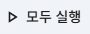


# **01-1 GitHub 연동 설정 (Colab 전용)**

In [1]:
# ============================
# 🔗 GitHub 연동 설정 (Colab 전용)
# ============================
try:
    from google.colab import userdata
    IN_COLAB = True
    print("✅ Google Colab 환경 감지됨")
except:
    IN_COLAB = False
    print("⚠️ 로컬/GitHub Actions 환경")

if IN_COLAB:
    import os

    # Colab Secrets에서 API 키 읽기
    os.environ["GITHUB_TOKEN"] = userdata.get('GITHUB_TOKEN')
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
    os.environ["NEWSAPI_KEY"] = userdata.get('NEWSAPI_KEY')
    os.environ["NEWSDATA_API_KEY"] = userdata.get('NEWSDATA_API_KEY')
    os.environ["GNEWS_API_KEY"] = userdata.get('GNEWS_API_KEY')
    os.environ["MEDIASTACK_API_KEY"] = userdata.get('MEDIASTACK_API_KEY')
    os.environ["SERPAPI_KEY"] = userdata.get('SERPAPI_KEY')
    os.environ["CURRENTS_API_KEY"] = userdata.get('CURRENTS_API_KEY')
    os.environ["NAVER_CLIENT_ID"] = userdata.get('NAVER_CLIENT_ID')
    os.environ["NAVER_CLIENT_SECRET"] = userdata.get('NAVER_CLIENT_SECRET')

    os.environ["GMAIL_USER"] = userdata.get('GMAIL_USER')
    os.environ["GMAIL_APP_PASSWORD"] = userdata.get('GMAIL_APP_PASSWORD')
    os.environ["TO_EMAIL"] = userdata.get('TO_EMAIL')
    os.environ["TO_EMAIL_TEST"] = userdata.get('TO_EMAIL_TEST')


    print("✅ Colab Secrets에서 API 키 로드 완료")

✅ Google Colab 환경 감지됨
✅ Colab Secrets에서 API 키 로드 완료


# **01-2 라이브러리 설치**

In [2]:
# ============================
# 1. 라이브러리 설치
# ============================
if IN_COLAB:
    get_ipython().system('pip install -q requests pandas python-dateutil openai beautifulsoup4 feedparser')

import os
import time
import json
import requests
import pandas as pd
import difflib
import re
from html import unescape

def clean_text(text: str) -> str:
    if not text:
        return ""

    # HTML 엔티티 복원
    text = unescape(text)

    # HTML 태그 제거
    text = re.sub(r"<[^>]+>", " ", text)

    # 공백 정리
    text = re.sub(r"\s+", " ", text).strip()

    return text

from datetime import datetime, timedelta, timezone

import feedparser
from dateutil import parser as dateparser  # 이미 있다면 생략

from openai import OpenAI
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from html import escape as h
# IPython은 Colab에서만 필요
try:
    from IPython.display import HTML, display
except ImportError:
    # GitHub Actions 환경용 더미 함수
    def display(obj):
        pass
    def HTML(text):
        return text
    pass
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from concurrent.futures import ThreadPoolExecutor, as_completed

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.1 MB/s eta 0:00:00


# **02-1 설정 (API 키)**

In [3]:
# ============================================================
# 2. API 키 & 기본 설정
# ============================================================

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
NEWSAPI_KEY = os.environ.get("NEWSAPI_KEY")
NEWSDATA_API_KEY = os.environ.get("NEWSDATA_API_KEY")
GNEWS_API_KEY = os.environ.get("GNEWS_API_KEY")
MEDIASTACK_API_KEY = os.environ.get("MEDIASTACK_API_KEY")
SERPAPI_KEY = os.environ.get("SERPAPI_KEY")
CURRENTS_API_KEY = os.environ.get("CURRENTS_API_KEY")
NAVER_CLIENT_ID = os.environ.get("NAVER_CLIENT_ID")
NAVER_CLIENT_SECRET = os.environ.get("NAVER_CLIENT_SECRET")



NEWSDATA_BASE_URL_LATEST = "https://newsdata.io/api/1/latest"



# **02-2 설정 (기본 설정, 날짜, 수집 기간, 이미지)**

In [4]:
# 사용할 GPT mini 모델 이름 (예: "gpt-4.1-mini", 나중에 "gpt-5.1-mini"로 교체 가능)
MODEL_NAME = "gpt-4.1-mini"

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
client = OpenAI()

# ============================================================
# GitHub Pages 설정
# ============================================================
# GitHub 계정 아이디와 레포 이름
GITHUB_OWNER = "dekim-inspace"              # 예: "junwoo0920"
GITHUB_REPO  = "Newsletter"    # GitHub에서 만든 레포 이름

# GitHub Pages 최종 URL (Settings → Pages에 표시되는 주소)
# 보통 형태: https://{owner}.github.io/{repo}
BASE_URL = f"https://{GITHUB_OWNER}.github.io/{GITHUB_REPO}"

# GitHub Personal Access Token (Colab 셀에서 os.environ["GITHUB_TOKEN"] 로 미리 넣어둔 값)
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")


# 헤더 이미지 / 로고 / 기본 썸네일
HEADER_BACKGROUND = "https://static.wixstatic.com/media/b749e1_60701dc82eb542149d95637ce7a34802~mv2_d_5568_3712_s_4_2.jpg/v1/fill/w_1553,h_1071,al_c,q_85,usm_0.66_1.00_0.01,enc_avif,quality_auto/b749e1_60701dc82eb542149d95637ce7a34802~mv2_d_5568_3712_s_4_2.jpg"
LOGO_URL = "https://static.wixstatic.com/media/0c4f16_c8132c52e3ef485286a1f0ec457a5cdb~mv2.png/v1/fill/w_111,h_44,al_c,q_85,usm_0.66_1.00_0.01,enc_avif,quality_auto/logotype_vert_rgb_v2__w__w500.png%201x,%20https://static.wixstatic.com/media/0c4f16_c8132c52e3ef485286a1f0ec457a5cdb~mv2.png/v1/fill/w_222,h_88,al_c,q_85,usm_0.66_1.00_0.01,enc_avif,quality_auto/logotype_vert_rgb_v2__w__w500.png%202x"
DEFAULT_THUMB = "https://e0.pxfuel.com/wallpapers/597/629/desktop-wallpaper-fun-funny-funny-funny-space.jpg"

CONTENT_WIDTH = 700

# ============================
# 2. 날짜 자동 설정 (UTC 기준 7일 전 ~ 오늘)
# ============================
# KST 시간대 정의
KST = timezone(timedelta(hours=9))
now_kst = datetime.now(KST)

# 기준일 (실행일)
anchor_date = now_kst.date()

# 수집 종료일: 전날
end_date_kst = anchor_date - timedelta(days=1)

# 수집 시작일: 종료일 기준 6일 전
start_date_kst = end_date_kst - timedelta(days=6)

# KST → UTC 변환
date_from_utc = datetime.combine(
    start_date_kst, datetime.min.time()
).replace(tzinfo=KST).astimezone(timezone.utc)

date_to_utc = datetime.combine(
    end_date_kst, datetime.max.time()
).replace(tzinfo=KST).astimezone(timezone.utc)

DATE_FROM = date_from_utc.strftime("%Y-%m-%d")
DATE_TO   = date_to_utc.strftime("%Y-%m-%d")


print("=" * 60)
print(f"🕐 현재 KST 시간: {now_kst.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📅 검색 범위 (KST): {start_date_kst} ~ {end_date_kst}")
print(f"📅 검색 범위 (UTC): {DATE_FROM} ~ {DATE_TO}")
print("=" * 60)


# 영어 + 한국어 기사 같이 사용
LANGUAGES = ["en", "ko"]

# ============================
# 2. 주제 정의 & 키워드
# ============================
TOPIC_DESC = {
    1: "GeoINT / 지리공간 정보, 위성·지도 기반 정보 분석",
    2: "항공 / 드론·무인기(UAV/UAS) 동향",
    3: "AI 데이터·분석 플랫폼 / MLOps·자동화",
    4: "위성 영상 / SAR·광학·하이퍼스펙트럴 이미지 분석"
}

TOPIC_ICON = {
    1: "🌐",   # GEOINT
    2: "✈️",   # 항공
    3: "🤖",   # AI 플랫폼
    4: "🛰️",   # 위성영상
}

# 영어 + 한글 키워드 혼합 (✅ 정리본 + 한글 보강)
TOPIC_KEYWORDS = {
    1: [
        # GeoINT / Geospatial / GIS / Location Intelligence
        "geospatial intelligence", "GeoINT",
        "geospatial analytics", "location intelligence",
        "geospatial data", "geospatial mapping",
        "GIS platform", "geospatial security",
        "OSINT geospatial", "satellite intelligence",
        "geospatial surveillance", "geospatial AI",
        "spatial analytics", "geospatial platform",
        "GIS software", "geospatial data platform",
        "digital twin GIS", "smart city GIS", "remote sensing",

        # KR 보강
        "지리공간 정보", "지리공간정보", "공간정보",
        "공간정보산업", "공간정보시스템", "지리정보시스템",
        "GIS", "GIS 플랫폼", "공간 분석", "공간분석",
        "지리공간 데이터", "공간 데이터", "공간데이터",
        "위치 기반 서비스", "위치기반 서비스", "위치정보",
        "지도 서비스", "지도 데이터", "국토정보",
        "국토지리정보", "국토지리정보원",
        "측량", "측량 기술", "지적", "디지털 트윈", "디지털트윈",
        "스마트시티", "공간 빅데이터", "공간빅데이터",
        "오픈소스 GIS", "원격탐사",
    ],

    2: [
        # Drone / UAV-UAS / UAM + regulation + operations
        "drone industry",
        "UAV technology", "UAS technology",
        "urban air mobility", "UAM",
        "drone regulation", "BVLOS drone",
        "autonomous drone",
        "drone delivery", "drone inspection",
        "drone surveillance",
        "drone traffic management", "UTM",
        "counter drone", "anti-drone",
        "eVTOL", "AAM",
        "drone swarm", "drone security", "drone in a box",
        "drone station", "dock", "VTOL",

        # KR 보강
        "드론", "드론 산업", "드론산업",
        "무인기", "무인항공기", "무인항공",
        "UAV", "UAS",
        "도심 항공 모빌리티", "도심항공모빌리티",
        "UAM 규제", "UAM", "AAM", "미래항공모빌리티",
        "드론 규제", "드론 안전", "드론 인증",
        "BVLOS", "비가시권 비행", "시계외비행",
        "드론 배송", "드론택배",
        "드론 점검", "드론 검사", "시설물 점검 드론",
        "드론 감시", "드론 정찰", "드론 방산", "드론 방어",
        "드론 관제", "드론교통관리", "UTM",
        "K-드론", "드론 실증", "드론특별자유화", "드론스테이션",
    ],

    3: [
        # Enterprise AI / Data+Analytics Platform / MLOps / GenAI Ops
        "AI data platform", "data analytics platform",
        "MLOps platform",
        "enterprise AI", "enterprise AI platform",
        "generative AI platform", "LLM platform",
        "RAG platform", "retrieval augmented generation",
        "LLMOps",
        "vector database", "feature store",
        "model deployment", "model serving",
        "AI infrastructure", "AI cloud platform",
        "data lakehouse", "data lake", "data warehouse",
        "data pipeline", "orchestration",
        "model monitoring", "model governance",

        # KR 보강
        "AI 데이터 플랫폼", "데이터 분석 플랫폼", "분석 플랫폼",
        "데이터 레이크", "데이터레이크", "레이크하우스", "데이터 웨어하우스", "데이터웨어하우스",
        "데이터 파이프라인", "데이터파이프라인", "ETL", "ELT", "워크플로 오케스트레이션",
        "MLOps", "LLMOps", "모델옵스",
        "엔터프라이즈 AI", "기업용 AI", "업무용 AI",
        "생성형 AI", "생성형AI", "생성형 AI 플랫폼", "LLM 플랫폼",
        "RAG", "RAG 플랫폼", "검색증강생성",
        "벡터 데이터베이스", "벡터DB", "임베딩", "피처 스토어", "특성 저장소",
        "모델 배포", "모델서빙", "모델 서빙",
        "모델 모니터링", "모델 거버넌스", "AI 거버넌스",
        "AI 인프라", "AI 클라우드 플랫폼", "GPU 인프라",
        "AI 업무 자동화", "디지털 전환", "DX",
    ],

    4: [
        # Satellite imagery / EO / SAR-Optical-Hyperspectral / Remote Sensing
        "satellite imagery analysis", "satellite imagery processing",
        "SAR satellite analytics",
        "optical satellite imagery analysis",
        "hyperspectral satellite data",
        "earth observation data", "EO data platform",
        "satellite data analytics",
        "commercial satellite imagery",
        "remote sensing analytics",
        "synthetic aperture radar", "SAR imagery",
        "multispectral imagery", "hyperspectral imagery",
        "change detection satellite", "satellite image segmentation",

        # KR 보강
        "위성 영상", "위성영상", "위성영상 분석", "위성 영상 분석",
        "위성영상 처리", "위성 이미지", "위성 이미지 분석",
        "지구관측", "지구 관측", "지구관측 데이터", "EO", "지구관측 위성",
        "원격탐사", "원격 탐사", "원격탐사 데이터",
        "SAR", "SAR 위성", "합성개구레이다", "합성개구 레이더", "레이더 위성",
        "광학 위성", "광학 위성 영상", "광학위성",
        "초분광", "하이퍼스펙트럴", "하이퍼스펙트럴 영상", "초분광 영상",
        "다중분광", "멀티스펙트럴", "다중분광 영상",
        "위성 데이터", "위성데이터", "위성 데이터 분석", "위성데이터 분석",
        "위성 데이터 플랫폼", "위성데이터 플랫폼",
        "위성 서비스", "지표 변화 탐지", "변화 탐지",
    ],
}

# ============================================================
# 🌐 인스페이스 뉴스 설정 (추가)
# ============================================================
INSPACE_NEWS_TOP_N = 3
INSPACE_NEWS_MORE_PAGE_SIZE = 5

# 1차 후보 개수 (토픽당 NewsAPI에서 넉넉히 가져오기)
ARTICLES_PER_TOPIC_RAW = 100

# 언어별 목표 개수 (한글 30% : 영어 70%)
ARTICLES_PER_LANG_KO = 40   # 한글: 40%
ARTICLES_PER_LANG_EN = 60   # 영어: 60%

# 최종 뉴스레터에 반드시 보여줄 개수
ARTICLES_PER_TOPIC_FINAL = 3

# [추가] 한 토픽에서 "메인 3 + 추가 최소 6"을 확보하기 위한 전체 최소 개수
MIN_TOTAL_PER_TOPIC = ARTICLES_PER_TOPIC_FINAL + 6  # 3 + 6 = 9


🕐 현재 KST 시간: 2026-07-13 09:25:16
📅 검색 범위 (KST): 2026-07-06 ~ 2026-07-12
📅 검색 범위 (UTC): 2026-07-05 ~ 2026-07-12


# **03 NewsAPI로 기사 수집**

In [5]:
# ============================
# 3. NewsAPI에서 기사 수집
# ============================
def search_news_newsapi(query, from_date, to_date, language=None, page_size=50):
    """
    NewsAPI (2순위 보조 소스 1)
    """
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": query,
        "from": from_date,
        "to": to_date,
        "sortBy": "publishedAt",
        "pageSize": page_size,
        "apiKey": NEWSAPI_KEY,
    }
    if language:
        params["language"] = language

    r = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    return r.json().get("articles", [])


def search_news_mediastack(query, from_date, to_date, language=None, page_size=30):
    """
    MediaStack (2순위 보조 소스 2)
    - 무료 플랜이면 HTTPS가 안될 수도 있어서 http로 써야 할 때도 있음. (문서 참고)
    """
    url = "http://api.mediastack.com/v1/news"
    limit = min(page_size, 50)

    params = {
        "access_key": MEDIASTACK_API_KEY,
        "keywords": query,
        "date_from": from_date,
        "date_to": to_date,
        "sort": "published_desc",
        "limit": limit,
    }
    if language:
        # mediastack는 언어 코드가 en, ko 등 (공식 문서 확인)
        params["languages"] = language

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
    except Exception as e:
        print(f"[WARN] MediaStack error (q={query}, lang={language}): {e}")
        return []

    data = r.json()
    articles = []
    for item in data.get("data", []):
        articles.append({
            "source": {"name": item.get("source")},
            "author": item.get("author"),
            "title": item.get("title"),
            "description": item.get("description"),
            "content": item.get("description"),
            "url": item.get("url"),
            "publishedAt": item.get("published_at"),  # 또는 published_at/created_at 확인 필요
        })
    return articles

def search_news_serpapi(query, from_date, to_date, language=None, page_size=30):
    """
    SerpAPI Google News (3순위 백업 소스)
    """
    url = "https://serpapi.com/search"
    num = min(page_size, 20)

    params = {
        "engine": "google_news",
        "q": query,
        "api_key": SERPAPI_KEY,
        "num": num,
    }
    if language:
        params["hl"] = language  # hl=ko, hl=en 등

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
    except Exception as e:
        print(f"[WARN] SerpAPI error (q={query}, lang={language}): {e}")
        return []

    data = r.json()
    results = data.get("news_results") or []
    articles = []
    for item in results:
        # published_date는 사람이 읽기 좋은 문자열일 수 있음 ("3 hours ago" 이런 식이면 나중에 필터에서 걸러질 수 있음)
        articles.append({
            "source": {"name": item.get("source")},
            "author": None,
            "title": item.get("title"),
            "description": item.get("snippet"),
            "content": item.get("snippet"),
            "url": item.get("link"),
            "publishedAt": item.get("date") or item.get("published_date"),
        })
    return articles


def search_news_currents(query, from_date, to_date, language=None, page_size=30):
    """
    Currents API (3순위 백업 소스)
    """
    url = "https://api.currentsapi.services/v1/search"
    limit = min(page_size, 50)

    params = {
        "apiKey": CURRENTS_API_KEY,
        "keywords": query,
        "limit": limit,
    }
    if language:
        params["language"] = language

    # 날짜 필터는 플랜에 따라 동작 방식이 달라서, 필요시 문서 보고 맞게 조정
    params["start_date"] = from_date
    params["end_date"] = to_date

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
    except Exception as e:
        print(f"[WARN] Currents error (q={query}, lang={language}): {e}")
        return []

    data = r.json()
    results = data.get("news") or []
    articles = []
    for item in results:
        articles.append({
            "source": {"name": item.get("author")},
            "author": item.get("author"),
            "title": item.get("title"),
            "description": item.get("description"),
            "content": item.get("description"),
            "url": item.get("url"),
            "publishedAt": item.get("published"),  # ISO8601인지 확인 필요
        })
    return articles

import xml.etree.ElementTree as ET
from html import unescape

def search_news_google_rss_kr(query, from_date, to_date, language=None, page_size=30):
    """
    Google News RSS Search (KR/KO fallback)
    - hl=ko, gl=KR, ceid=KR:ko 고정
    - RSS는 date 파라미터가 약하므로, 받아온 뒤 from/to로 로컬 필터
    """
    # Google News RSS search endpoint
    # q는 URL 파라미터로 들어가므로 requests params를 사용
    url = "https://news.google.com/rss/search"

    params = {
        "q": query,
        "hl": "ko",
        "gl": "KR",
        "ceid": "KR:ko",
    }

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
    except Exception as e:
        print(f"[WARN] GoogleRSS error (q={query}): {e}")
        return []

    # XML 파싱
    try:
        root = ET.fromstring(r.text)
    except Exception as e:
        print(f"[WARN] GoogleRSS XML parse error: {e}")
        return []

    # 날짜 필터 준비
    try:
        dt_from = dateparser.parse(from_date).date()
        dt_to = dateparser.parse(to_date).date()
    except Exception:
        dt_from = None
        dt_to = None

    items = root.findall(".//item")
    articles = []

    for it in items:
        title = it.findtext("title") or ""
        link = it.findtext("link") or ""
        pub_date = it.findtext("pubDate") or ""
        desc = it.findtext("description") or ""

        # description은 HTML이 섞이므로 unescape + 태그 대충 제거
        desc = unescape(desc)
        desc = re.sub(r"<[^>]+>", " ", desc)
        desc = re.sub(r"\s+", " ", desc).strip()

        # pubDate 파싱 & 범위 필터
        if pub_date:
            try:
                d = dateparser.parse(pub_date)
                if d is not None:
                    d_date = d.date()
                    if dt_from and d_date < dt_from:
                        continue
                    if dt_to and d_date > dt_to:
                        continue
            except Exception:
                pass

        if not link:
            continue

        articles.append({
            "source": {"name": "Google News RSS (KR)"},
            "author": None,
            "title": unescape(title).strip(),
            "description": desc,
            "content": "",
            "url": link.strip(),
            "publishedAt": pub_date,
        })

        if len(articles) >= page_size:
            break

    return articles


def _normalize_naver_query(q: str) -> str:
    """
    Naver Search API용 query 정리.
    - Naver는 Google처럼 boolean OR/AND/NOT을 안정적으로 지원하지 않을 수 있어 제거(공백 치환)
    - 괄호/따옴표/중복 공백 정리
    - 너무 긴 쿼리는 재현율/품질에 불리할 수 있어 보수적으로 길이 제한
    """
    q = (q or "").strip()
    if not q:
        return ""

    # boolean 토큰 제거(대/소문자 모두)
    q = re.sub(r"\b(OR|AND|NOT)\b", " ", q, flags=re.IGNORECASE)

    # 괄호 제거
    q = q.replace("(", " ").replace(")", " ")

    # 따옴표 제거(길이만 늘고 효과가 적은 경우가 많음)
    q = q.replace('"', " ")

    # 공백 정리
    q = re.sub(r"\s+", " ", q).strip()

    # 길이 제한
    if len(q) > 120:
        q = q[:120].rsplit(" ", 1)[0].strip() or q[:120].strip()

    return q


def search_news_naver(query, from_date, to_date, language=None, page_size=30):
    """
    Naver Search API - News (KR fallback)
    - query: UTF-8
    - sort=date (최신순)
    - display: 최대 100 (네이버 제한)
    """
    if not NAVER_CLIENT_ID or not NAVER_CLIENT_SECRET:
        # 키 없으면 조용히 스킵 (로그만)
        print("[WARN] Naver API keys missing: NAVER_CLIENT_ID / NAVER_CLIENT_SECRET")
        return []

    # Naver는 boolean OR이 안정적으로 동작하지 않을 수 있어 query를 정규화
    query = _normalize_naver_query(query)
    if not query:
        return []

    url = "https://openapi.naver.com/v1/search/news.json"

    display = max(1, min(int(page_size), 100))
    params = {
        "query": query,
        "display": display,
        "start": 1,
        "sort": "date",
    }

    headers = {
        "X-Naver-Client-Id": NAVER_CLIENT_ID,
        "X-Naver-Client-Secret": NAVER_CLIENT_SECRET,
    }

    try:
        r = requests.get(url, params=params, headers=headers, timeout=10)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"[WARN] Naver error (q={query}): {e}")
        return []

    # 날짜 필터 준비
    try:
        dt_from = dateparser.parse(from_date).date()
        dt_to = dateparser.parse(to_date).date()
    except Exception:
        dt_from = None
        dt_to = None

    items = data.get("items") or []
    articles = []

    for it in items:
        # title/description은 HTML 태그가 들어있음
        title = unescape(it.get("title") or "")
        title = re.sub(r"<[^>]+>", " ", title)
        title = re.sub(r"\s+", " ", title).strip()

        desc = unescape(it.get("description") or "")
        desc = re.sub(r"<[^>]+>", " ", desc)
        desc = re.sub(r"\s+", " ", desc).strip()

        link = (it.get("originallink") or it.get("link") or "").strip()
        pub_date = it.get("pubDate") or ""

        # pubDate 필터
        if pub_date:
            try:
                d = dateparser.parse(pub_date)
                if d is not None:
                    d_date = d.date()
                    if dt_from and d_date < dt_from:
                        continue
                    if dt_to and d_date > dt_to:
                        continue
            except Exception:
                pass

        if not link:
            continue

        articles.append({
            "source": {"name": "Naver News Search"},
            "author": None,
            "title": title,
            "description": desc,
            "content": "",
            "url": link,
            "publishedAt": pub_date,
        })


        if len(articles) >= page_size:
            break

    return articles

def search_news_gnews(query, from_date, to_date, language=None, page_size=30):
    """
    GNews API (1순위 메인 소스)
    - 공식 문서 보고 파라미터 이름/제한은 필요시 조정
    """
    url = "https://gnews.io/api/v4/search"
    max_size = min(page_size, 50)  # 무료 플랜은 보통 10~50 제한

    params = {
        "q": query,
        "token": GNEWS_API_KEY,
        "max": max_size,
        "from": from_date,
        "to": to_date,
        "sortby": "publishedAt",
    }
    if language:
        # GNews는 언어코드가 en, ko 등을 지원 (문서 확인해서 맞춰야 함)
        params["lang"] = language

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
    except Exception as e:
        print(f"[WARN] GNews error (q={query}, lang={language}): {e}")
        return []

    data = r.json()
    articles = []
    for item in data.get("articles", []):
        articles.append({
            "source": {"name": item.get("source", {}).get("name")},
            "author": item.get("author"),
            "title": item.get("title"),
            "description": item.get("description"),
            "content": item.get("content"),
            "url": item.get("url"),
            # GNews는 publishedAt이 ISO8601 형식
            "publishedAt": item.get("publishedAt"),
        })
    return articles


def search_news_newsdata(query, from_date, to_date, language=None, page_size=30):
    """
    NewsData.io 'latest' 엔드포인트를 사용하는 버전
    - 무료 플랜에서도 동작
    - latest는 과거 n일이 아니라, 최근 ~48시간 기준이지만,
      우리는 어차피 NewsAPI에서 일주일치 커버하고,
      NewsData는 "추가 소스" 느낌으로만 쓰면 됨.
    """
    url = NEWSDATA_BASE_URL_LATEST

    # free 플랜에서 한 번에 가져올 수 있는 최대 size는 10개
    # (그 이상 넣으면 에러) :contentReference[oaicite:1]{index=1}
    size = min(page_size, 10)

    params = {
        "apikey": NEWSDATA_API_KEY,
        "q": query,
        "size": size,
    }

    if language:
        params["language"] = language  # "en", "ko" 등

    try:
        r = requests.get(url, params=params, timeout=10)
        r.raise_for_status()
    except requests.exceptions.HTTPError as e:
        status = getattr(e.response, "status_code", None)
        print(f"[WARN] NewsData.io HTTP error (status={status}, q={query}, lang={language}): {e}")
        return []
    except Exception as e:
        print(f"[WARN] NewsData.io error (q={query}, lang={language}): {e}")
        return []

    data = r.json()
    results = data.get("results") or []

    articles = []

    for item in results:
        creator = item.get("creator")
        if isinstance(creator, list):
            author = creator[0] if creator else None
        else:
            author = creator

        articles.append({
            # 기존 NewsAPI article 구조에 맞춰 변환
            "source": {"name": item.get("source_id")},
            "author": author,
            "title": item.get("title"),
            "description": item.get("description"),
            "content": item.get("content"),
            "url": item.get("link"),
            "publishedAt": item.get("pubDate"),  # 예: "2025-12-08 10:30:00"
        })

    return articles


def search_news_topheadlines_kr(page_size=50):
    """
    NewsAPI 'top-headlines' 엔드포인트로
    한국(country=kr) 기사만 가져오는 함수
    """
    url = "https://newsapi.org/v2/top-headlines"
    params = {
        "country": "kr",          # 한국
        "pageSize": page_size,    # 한 번에 가져올 기사 수
        "apiKey": NEWSAPI_KEY,
    }

    r = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    return r.json().get("articles", [])


EXCLUDE_KEYWORDS = [
    "tutorial", "how to", "explained", "explainer", "what is", "history of",
    "advertisement", "sponsored", "review", "buy now", "product page"
]

def is_basic_newsworthy(article):
    """
    노골적인 튜토리얼/광고/상품 페이지 등 1차 필터
    """
    title = (article.get("title") or "").lower()
    description = (article.get("description") or "").lower()
    content = (article.get("content") or "").lower()
    text = " ".join([title, description, content])
    for bad in EXCLUDE_KEYWORDS:
        if bad in text:
            return False
    return True

# ============================
# ✅ Rate-limit + Backoff helpers (추가)
# ============================

# API별 최소 호출 간격(초) - 보수적으로 시작해서 안정화 후 줄이세요.
_API_MIN_INTERVAL_SEC = {
    "gnews": 0.35,
    "newsapi_everything": 0.35,
    "mediastack": 0.5,
    "serpapi": 0.7,
    "currents": 0.5,
    "newsdata": 0.7,
    "newsapi_top": 0.35,
    "google_rss_kr": 0.5,
    "naver_news": 0.8,
}

def _rate_limit(api_name: str):
    """프로세스 단위(=런타임)로 API별 최소 호출 간격을 강제."""
    state = getattr(_rate_limit, "_state", None)
    if state is None:
        state = {"last_call": {}}
        setattr(_rate_limit, "_state", state)

    now = time.monotonic()
    last = state["last_call"].get(api_name, 0.0)
    min_itv = _API_MIN_INTERVAL_SEC.get(api_name, 0.3)

    wait = (last + min_itv) - now
    if wait > 0:
        time.sleep(wait)

    state["last_call"][api_name] = time.monotonic()


def _call_with_backoff(api_name, fn, *args, **kwargs):
    """
    429/일시 오류(5xx/타임아웃/too many request 류) 시 지수 백오프.
    최종 실패 시 raise 해서 call_api_guarded가 403/429를 감지하고
    circuit breaker를 열 수 있게 함.
    """
    max_tries = 5
    delay = 0.8

    for attempt in range(1, max_tries + 1):
        _rate_limit(api_name)
        try:
            return fn(*args, **kwargs) or []

        except requests.exceptions.HTTPError as e:
            resp = getattr(e, "response", None)
            status = getattr(resp, "status_code", None)
            msg = str(e).lower()

            retriable = (status in (429, 500, 502, 503, 504)) or ("too many" in msg)
            if retriable and attempt < max_tries:
                time.sleep(delay)
                delay *= 2
                continue

            print(f"[WARN] {api_name} HTTP error (status={status}): {e}")
            raise

        except Exception as e:
            msg = str(e).lower()
            retriable = ("too many" in msg) or ("429" in msg) or ("timeout" in msg) or ("temporar" in msg)
            if retriable and attempt < max_tries:
                time.sleep(delay)
                delay *= 2
                continue

            print(f"[WARN] {api_name} error: {e}")
            raise


# ============================
# ✅ (NEW) Query OR bundler + Run budgets + Circuit breaker (+ Topic budgets)
# ============================

from typing import List
from collections import defaultdict

def build_or_query(keywords: List[str], max_terms: int = 18) -> str:
    """
    OR 쿼리 생성.
    - 너무 긴 쿼리/과도한 term을 피하기 위해 max_terms로 컷
    - 공백 포함 키워드는 따옴표로 감싸 정확도 유지
    """
    terms = []
    for kw in keywords:
        kw = str(kw).strip()
        if not kw:
            continue
        if " " in kw:
            terms.append(f'"{kw}"')
        else:
            terms.append(kw)

    terms = terms[:max_terms]
    if not terms:
        return ""
    return " OR ".join(terms)

def chunk_keywords_for_1to2_calls(keywords: List[str], max_terms_per_call: int = 18) -> List[List[str]]:
    """
    "언어당 1~2회 호출"을 강제하기 위한 키워드 청킹.
    - max_terms_per_call 기준으로 1~2개 청크만 반환
    """
    keywords = [k for k in (keywords or []) if str(k).strip()]
    if not keywords:
        return []
    first = keywords[:max_terms_per_call]
    rest = keywords[max_terms_per_call:(max_terms_per_call * 2)]
    chunks = [first]
    if rest:
        chunks.append(rest)
    return chunks  # 최대 2개


# ---- 실행(run) 단위 Budget / Circuit Breaker 상태 ----
_RUN_API_BUDGETS_DEFAULT = {
    # 요청 주신 실행당 호출 예산 예시
    "mediastack": 25,
    "serpapi": 60,
    "gnews": 30,
    "newsapi_everything": 60,
    "newsapi_top": 10,
    "currents": 25,
    "newsdata": 25,
    "google_rss_kr": 30,
    "naver_news": 20,
}

# ---- 토픽(topic) 단위 Budget (호출 수 상한을 “토픽별로도” 명확화) ----
_TOPIC_API_BUDGETS_DEFAULT = {
    # OR 1~2회/언어(ko/en) 기준: 대략 4회 + 버퍼
    "gnews": 6,
    "newsapi_everything": 6,

    # pass2 보조 소스는 낮게
    "mediastack": 3,
    "serpapi": 3,
    "currents": 3,
    "newsdata": 3,

    # 토픽당 1회만 의도
    "newsapi_top": 1,
}

_CB_DEFAULT = {
    # 연속 403/429가 이 횟수 이상이면 해당 실행 동안 오픈(open)
    "threshold": 2,
}

def _get_run_state():
    state = getattr(_get_run_state, "_state", None)
    if state is None:
        state = {
            "budget_left": dict(_RUN_API_BUDGETS_DEFAULT),
            "topic_budget_left": defaultdict(lambda: dict(_TOPIC_API_BUDGETS_DEFAULT)),
            "cb": {},  # api_name -> {"open": bool, "consec_403_429": int}
        }
        setattr(_get_run_state, "_state", state)
    return state

def reset_run_state():
    """실행(run) 시작 시 호출(선택)."""
    state = _get_run_state()
    state["budget_left"] = dict(_RUN_API_BUDGETS_DEFAULT)
    state["topic_budget_left"] = defaultdict(lambda: dict(_TOPIC_API_BUDGETS_DEFAULT))
    state["cb"] = {}

def _cb_get(api_name: str) -> dict:
    st = _get_run_state()
    cb = st["cb"].get(api_name)
    if cb is None:
        cb = {"open": False, "consec_403_429": 0}
        st["cb"][api_name] = cb
    return cb

def _cb_on_result(api_name: str, status_code, success: bool):
    cb = _cb_get(api_name)
    if success:
        cb["consec_403_429"] = 0
        return
    if status_code in (403, 429):
        cb["consec_403_429"] += 1
        if cb["consec_403_429"] >= _CB_DEFAULT["threshold"]:
            cb["open"] = True

def _budget_can_call(api_name: str) -> bool:
    st = _get_run_state()
    left = st["budget_left"].get(api_name)
    if left is None:
        return True
    return left > 0

def _budget_decrement(api_name: str, n: int = 1):
    st = _get_run_state()
    if api_name not in st["budget_left"]:
        return
    st["budget_left"][api_name] = max(0, st["budget_left"][api_name] - n)

def _topic_budget_can_call(topic_id: int, api_name: str) -> bool:
    st = _get_run_state()
    tb = st["topic_budget_left"][topic_id]
    left = tb.get(api_name)
    if left is None:
        return True
    return left > 0

def _topic_budget_decrement(topic_id: int, api_name: str, n: int = 1):
    st = _get_run_state()
    tb = st["topic_budget_left"][topic_id]
    if api_name not in tb:
        return
    tb[api_name] = max(0, tb[api_name] - n)

def call_api_guarded(api_name: str, fn, *args, topic_id=None, **kwargs):
    """
    - (1) circuit breaker open이면 스킵
    - (2) run budget 0이면 스킵
    - (3) topic budget 0이면 스킵 (topic_id 제공 시)
    - (4) 호출 시도하면 run/topic budget 차감
    - (5) 403/429 연속이면 cb open
    """
    cb = _cb_get(api_name)
    if cb.get("open"):
        return []

    if not _budget_can_call(api_name):
        return []

    if topic_id is not None and not _topic_budget_can_call(topic_id, api_name):
        return []

    # top-level call 기준으로 1 차감
    _budget_decrement(api_name, 1)
    if topic_id is not None:
        _topic_budget_decrement(topic_id, api_name, 1)

    try:
        out = _call_with_backoff(api_name, fn, *args, **kwargs) or []
        _cb_on_result(api_name, status_code=None, success=True)
        return out
    except requests.exceptions.HTTPError as e:
        status = getattr(getattr(e, "response", None), "status_code", None)
        _cb_on_result(api_name, status_code=status, success=False)
        return []
    except Exception:
        return []


# ============================
# ✅ collect_articles_for_topic (교체)
#   - 2-pass 유지
#   - NewsAPI OR: 언어당 1~2회
#   - GNews도 OR: 언어당 1~2회 (기존 키워드별 호출 제거)
#   - top-headlines: 토픽당 1회 + guarded + pass2에서만 보강
#   - run budget + topic budget + circuit breaker
# ============================

def _build_ko_query_for_local_sources(topic_keywords, fallback_query):
    """
    KO 전용 소스(Naver/Google RSS)용 쿼리 축소:
    - 한글 키워드만 최대 5개 OR로 묶어 길이/에러 리스크 줄임
    - 한글 키워드가 없으면 fallback_query 사용
    """
    ko_terms = []
    for k in topic_keywords:
        s = str(k)
        if any('\uac00' <= ch <= '\ud7a3' for ch in s):
            ko_terms.append(s)

    ko_terms = ko_terms[:5]
    if ko_terms:
        # 공백 포함 키워드는 따옴표 처리
        parts = [f"\"{t}\"" if " " in t else t for t in ko_terms]
        return " OR ".join(parts)

    # fallback도 너무 길면 첫 토큰만
    fb = str(fallback_query or "").strip()
    if len(fb) > 80:
        fb = fb.split(" OR ")[0].strip()
    return fb

def _split_keywords_by_lang(topic_keywords):
    """
    토픽 키워드를 en/ko로 분리 (Hangul 포함 여부 기준).

    중요:
    - 키워드가 '"A" OR "B" OR "한글"' 처럼 한 줄에 섞여 있는 경우가 많아서,
      문자열 내부 OR를 먼저 분해한 뒤 조각 단위로 언어 분리한다.
    - 이렇게 해야 en_sources(GNews 등)로 한글이 섞여 들어가 400이 나는 것을 막을 수 있다.
    """
    def _has_hangul(s: str) -> bool:
        return any('\uac00' <= ch <= '\ud7a3' for ch in (s or ""))

    def _split_or_expr(s: str):
        """
        매우 단순한 OR 분해:
        - 공백 포함 OR 토큰 기준으로 쪼갠다.
        - 괄호/공백 정리만 수행 (완전한 파서가 아니라 '최소 변경' 목적)
        """
        s = (s or "").strip()
        if not s:
            return []
        parts = re.split(r"\s+OR\s+", s, flags=re.IGNORECASE)
        out = []
        for p in parts:
            p = (p or "").strip()
            p = p.strip("()").strip()
            if p:
                out.append(p)
        return out if out else [s]

    en_terms, ko_terms = [], []

    for k in (topic_keywords or []):
        s = str(k or "").strip()
        if not s:
            continue

        # ✅ "A OR B OR 한글" 같은 혼합 문자열은 먼저 OR로 분해해서 조각 단위로 분류
        pieces = _split_or_expr(s)
        for piece in pieces:
            if not piece:
                continue
            if _has_hangul(piece):
                ko_terms.append(piece)
            else:
                en_terms.append(piece)

    # 순서 유지 dedup
    def _uniq(seq):
        out, seen = [], set()
        for x in seq:
            key = x.lower()
            if key in seen:
                continue
            seen.add(key)
            out.append(x)
        return out

    return _uniq(en_terms), _uniq(ko_terms)



def collect_articles_for_topic(topic_id, keywords):
    collected_ko = []
    collected_en = []
    seen_urls = set()

    def _need(lang):
        if lang == "ko":
            return max(0, ARTICLES_PER_LANG_KO - len(collected_ko))
        return max(0, ARTICLES_PER_LANG_EN - len(collected_en))

    def _target_list(lang):
        return collected_ko if lang == "ko" else collected_en

    # top-headlines 필터링용 토큰(너무 짧은 토큰은 제외)
    topic_tokens = set()
    for kw in keywords:
        for tok in str(kw).lower().split():
            if len(tok) >= 2:
                topic_tokens.add(tok)

    # -----------------------------
    # ✅ 토픽당 top-headlines 1회만 호출(한글 보강용)
    #    - 반드시 guarded로 호출해 run/topic 예산 + CB 적용
    # -----------------------------
    top_headlines_cache = []
    top_headlines_cache = call_api_guarded(
        "newsapi_top",
        search_news_topheadlines_kr,
        page_size=20,
        topic_id=topic_id,
    )

    # ✅ 키워드를 en/ko로 분리해서 언어별 소스에 섞이지 않게 함
    keywords_en, keywords_ko = _split_keywords_by_lang(keywords)

    # en이 비면(극단 케이스) 기존 keywords를 fallback
    if not keywords_en:
        keywords_en = list(keywords or [])


    PASS1_KW_N = 2

    # -------------------------------------------------
    # ✅ 언어별 소스 완전 분리 + 언어별 키워드 완전 분리
    #   - en: 기존 6개 뉴스 API만 사용 + en 키워드만 사용
    #   - ko: Google KR RSS + Naver + topheadlines_cache만 사용 + ko 키워드만 사용
    # -------------------------------------------------
    pass_plan = [
        {
            "name": "pass1",
            "kws_en": keywords_en[:PASS1_KW_N],
            "kws_ko": keywords_ko,
            "en_sources": ("gnews", "newsapi_everything"),
            "ko_sources": ("google_rss_kr", "naver_news", "topheadlines_cache"),
        },
        {
            "name": "pass2",
            "kws_en": keywords_en,
            "kws_ko": keywords_ko,
            "en_sources": (
                "gnews",
                "newsapi_everything",
                "mediastack",
                "serpapi",
                "currents",
                "newsdata",
            ),
            "ko_sources": ("google_rss_kr", "naver_news", "topheadlines_cache"),
        },
    ]

    # en이 비면(극단 케이스) "mixed keywords 전체"를 en으로 되돌려 넣지 말고,
    # 한글을 제거한 문자열만 en 후보로 만든다 (GNews 400 방지)
    if not keywords_en:
        tmp_en = []
        for k in (keywords or []):
            s = str(k or "").strip()
            if not s:
                continue
            # 한글만 제거 → 남은 영문/기호 기반으로 en 쿼리 후보 생성
            s2 = re.sub(r"[\uac00-\ud7a3]+", " ", s)
            s2 = re.sub(r"\s+", " ", s2).strip()
            if s2:
                tmp_en.append(s2)
        keywords_en = tmp_en

    # ko가 비면(극단 케이스) RSS/Naver는 영문도 어느 정도 검색되므로 기존 fallback 유지
    if not keywords_ko:
        keywords_ko = list(keywords or [])





    for plan in pass_plan:
        if _need("ko") <= 0 and _need("en") <= 0:
            break

        for lang in LANGUAGES:
            remaining = _need(lang)

            # ✅ 언어별 실행 소스 선택 (완전 분리)
            active_sources = plan["ko_sources"] if lang == "ko" else plan["en_sources"]

            if remaining <= 0:
                continue

            tier_articles = []

            # -------------------------------------------------
            # 1) ✅ GNews OR 묶음: 언어당 1~2회 호출
            # -------------------------------------------------
            if "gnews" in active_sources and len(tier_articles) < remaining:
                gnews_chunks = chunk_keywords_for_1to2_calls(plan["kws_en"], max_terms_per_call=18)
                for chunk in gnews_chunks:
                    if len(tier_articles) >= remaining:
                        break
                    q_or = build_or_query(chunk, max_terms=18)
                    if not q_or:
                        continue

                    rem_chunk = remaining - len(tier_articles)
                    tier_articles.extend(
                        call_api_guarded(
                            "gnews",
                            search_news_gnews,
                            q_or,
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem_chunk, 50),
                            topic_id=topic_id,
                        )
                    )

            # -------------------------------------------------
            # 2) ✅ NewsAPI everything OR 묶음: 언어당 1~2회 호출
            # -------------------------------------------------
            if "newsapi_everything" in active_sources and len(tier_articles) < remaining:
                newsapi_chunks = chunk_keywords_for_1to2_calls(plan["kws_en"], max_terms_per_call=18)

                for chunk in newsapi_chunks:
                    if len(tier_articles) >= remaining:
                        break

                    q_or = build_or_query(chunk, max_terms=18)
                    if not q_or:
                        continue

                    rem_chunk = remaining - len(tier_articles)
                    tier_articles.extend(
                        call_api_guarded(
                            "newsapi_everything",
                            search_news_newsapi,
                            q_or,
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem_chunk, 50),
                            topic_id=topic_id,
                        )
                    )

            # -------------------------------------------------
            # ✅ (이동됨) 한국 전용 백업: Google News RSS (KR) + Naver Search API
            #    - ko 수량 부족 시에만 호출
            #    - pass1에서도 실행되도록 pass2 블록 밖으로 이동
            # -------------------------------------------------
            if lang == "ko" and len(tier_articles) < remaining:
                # (a) Google News RSS (KR)
                rem_kr = remaining - len(tier_articles)
                if "google_rss_kr" in active_sources and rem_kr > 0:
                    ko_query = _build_ko_query_for_local_sources(
                        plan.get("kws_ko") or [],
                        fallback_query=((plan.get("kws_ko")[0] if plan.get("kws_ko") else "") or (plan.get("kws_en")[0] if plan.get("kws_en") else "")),

                    )

                    tier_articles.extend(
                        call_api_guarded(
                            "google_rss_kr",
                            search_news_google_rss_kr,
                            ko_query,
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem_kr, 30),
                            topic_id=topic_id,
                        )
                    )


                # (b) Naver News Search API
                rem_kr2 = remaining - len(tier_articles)
                if "naver_news" in active_sources and rem_kr2 > 0:
                    ko_query = _build_ko_query_for_local_sources(
                        plan.get("kws_ko") or [],
                        fallback_query=((plan.get("kws_ko")[0] if plan.get("kws_ko") else "") or (plan.get("kws_en")[0] if plan.get("kws_en") else "")),

                    )

                    tier_articles.extend(
                        call_api_guarded(
                            "naver_news",
                            search_news_naver,
                            ko_query,
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem_kr2, 30),
                            topic_id=topic_id,
                        )
                    )

            # -------------------------------------------------
            # 3) 보조 소스들(pass2에서만) — budget으로 상한이 강하게 걸림
            # -------------------------------------------------
            if plan["name"] == "pass2" and len(tier_articles) < remaining:
                # mediastack
                rem3 = remaining - len(tier_articles)
                if "mediastack" in active_sources and rem3 > 0:
                    tier_articles.extend(
                        call_api_guarded(
                            "mediastack",
                            search_news_mediastack,
                            plan.get("kws_en")[0] if plan.get("kws_en") else "",
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem3, 30),
                            topic_id=topic_id,
                        )
                    )

                # serpapi
                rem4 = remaining - len(tier_articles)
                if "serpapi" in active_sources and rem4 > 0:
                    tier_articles.extend(
                        call_api_guarded(
                            "serpapi",
                            search_news_serpapi,
                            plan.get("kws_en")[0] if plan.get("kws_en") else "",
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem4, 10),
                            topic_id=topic_id,
                        )
                    )

                # currents
                rem5 = remaining - len(tier_articles)
                if "currents" in active_sources and rem5 > 0:
                    tier_articles.extend(
                        call_api_guarded(
                            "currents",
                            search_news_currents,
                            plan.get("kws_en")[0] if plan.get("kws_en") else "",
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem5, 50),
                            topic_id=topic_id,
                        )
                    )

                # newsdata
                rem6 = remaining - len(tier_articles)
                if "newsdata" in active_sources and rem6 > 0:
                    tier_articles.extend(
                        call_api_guarded(
                            "newsdata",
                            search_news_newsdata,
                            plan.get("kws_en")[0] if plan.get("kws_en") else "",
                            DATE_FROM,
                            DATE_TO,
                            language=lang,
                            page_size=min(rem6, 10),
                            topic_id=topic_id,
                        )
                    )

            # -------------------------------------------------
            # 4) ✅ top-headlines 캐시 보강: pass2에서만
            # -------------------------------------------------
            if (
                plan["name"] == "pass2"
                and len(tier_articles) < remaining
                and lang == "ko"
                and "topheadlines_cache" in active_sources
                and top_headlines_cache
            ):
                for art in top_headlines_cache:
                    title_text = str(art.get("title", "")).lower()
                    if not title_text:
                        continue
                    if any(tok in title_text for tok in topic_tokens):
                        tier_articles.append(art)

            # -----------------------------
            # 공통 후처리: URL 중복 제거 + 날짜 필터 + 기본 필터
            # -----------------------------
            for a in tier_articles:
                if lang == "ko" and len(collected_ko) >= ARTICLES_PER_LANG_KO:
                    break
                if lang == "en" and len(collected_en) >= ARTICLES_PER_LANG_EN:
                    break

                url = a.get("url")
                if not url or url in seen_urls:
                    continue

                published_at_raw = a.get("publishedAt")

                if not published_at_raw:
                    published_dt = datetime.fromisoformat(DATE_TO).date()
                else:
                    try:
                        parsed = dateparser.parse(published_at_raw)
                        if parsed is None:
                            raise ValueError("parsed is None")
                        published_dt = parsed.date()
                    except Exception:
                        published_dt = datetime.fromisoformat(DATE_TO).date()

                from_dt = datetime.fromisoformat(DATE_FROM).date()
                to_dt = datetime.fromisoformat(DATE_TO).date()
                if not (from_dt <= published_dt <= to_dt):
                    continue

                if not is_basic_newsworthy(a):
                    continue

                seen_urls.add(url)
                article_data = {
                    "topic_seed": topic_id,
                    "source_name": a.get("source", {}).get("name"),
                    "author": a.get("author"),
                    "original_title": a.get("title"),
                    "description": a.get("description"),
                    "content": a.get("content"),
                    "url": url,
                    "published_at": str(published_dt),
                }
                _target_list(lang).append(article_data)

    collected = collected_ko + collected_en
    print(f"  └ 주제 {topic_id}: 한글 {len(collected_ko)}개, 영어 {len(collected_en)}개 수집됨")
    return collected





reset_run_state()
print("=== [1단계] NewsAPI에서 기사 수집 중 ===")

raw_articles = []

for t_id, kws in TOPIC_KEYWORDS.items():
    arts = collect_articles_for_topic(t_id, kws)
    print(f"주제 {t_id} ({TOPIC_DESC[t_id]}) : {len(arts)}개 기사 후보 수집")
    raw_articles.extend(arts)


df_raw = pd.DataFrame(raw_articles)
print("\n[1차 수집 결과 개수] :", len(df_raw))
if IN_COLAB:
    display(df_raw.head())

=== [1단계] NewsAPI에서 기사 수집 중 ===
[WARN] GNews error (q="geospatial intelligence" OR GeoINT OR "geospatial analytics" OR "location intelligence" OR "geospatial data" OR "geospatial mapping" OR "GIS platform" OR "geospatial security" OR "OSINT geospatial" OR "satellite intelligence" OR "geospatial surveillance" OR "geospatial AI" OR "spatial analytics" OR "geospatial platform" OR "GIS software" OR "geospatial data platform" OR "digital twin GIS" OR "smart city GIS", lang=en): 400 Client Error: Bad Request for url: https://gnews.io/api/v4/search?q=%22geospatial+intelligence%22+OR+GeoINT+OR+%22geospatial+analytics%22+OR+%22location+intelligence%22+OR+%22geospatial+data%22+OR+%22geospatial+mapping%22+OR+%22GIS+platform%22+OR+%22geospatial+security%22+OR+%22OSINT+geospatial%22+OR+%22satellite+intelligence%22+OR+%22geospatial+surveillance%22+OR+%22geospatial+AI%22+OR+%22spatial+analytics%22+OR+%22geospatial+platform%22+OR+%22GIS+software%22+OR+%22geospatial+data+platform%22+OR+%22digital+twin+

,topic_seed,source_name,author,original_title,description,content,url,published_at
0,1,Google News RSS (KR),None,"""드론과 AI로 공간정보 체험해요""…제13회 드림업 공간정보 캠프 신청 시작 | -...","""드론과 AI로 공간정보 체험해요""…제13회 드림업 공간정보 캠프 신청 시작 | e...",,https://news.google.com/rss/articles/CBMickFVX...,2026-07-12
1,1,Google News RSS (KR),None,"포항시, 드론·공간정보 기반으로 현장 행정 고도화…예산 3억 원 절감 - 한국시사경제","포항시, 드론·공간정보 기반으로 현장 행정 고도화…예산 3억 원 절감 한국시사경제",,https://news.google.com/rss/articles/CBMiakFVX...,2026-07-12
2,1,Google News RSS (KR),None,"10만 장 항공사진 디지털화, 이제야 시작…경남 공간정보 혁신, 속도와 완성도가 관...","10만 장 항공사진 디지털화, 이제야 시작…경남 공간정보 혁신, 속도와 완성도가 관...",,https://news.google.com/rss/articles/CBMidkFVX...,2026-07-11
3,1,Google News RSS (KR),None,"경북도, 지능형 공간정보 플랫폼 구축 - KBS 뉴스","경북도, 지능형 공간정보 플랫폼 구축 KBS 뉴스",,https://news.google.com/rss/articles/CBMiW0FVX...,2026-07-08
4,1,Google News RSS (KR),None,"경북도, 지능형 공간정보 플랫폼 구축 - v.daum.net","경북도, 지능형 공간정보 플랫폼 구축 v.daum.net",,https://news.google.com/rss/articles/CBMiVEFVX...,2026-07-08


# **03-1 언어별 비율 계산 함수**

In [6]:
# ============================
# 3-1. 언어별 비율 계산 함수 (새로 추가)
# ============================

def calculate_language_ratio(articles):
    """기사 리스트에서 한글/영문 비율 계산"""
    total = len(articles)
    if total == 0:
        return 0, 0, 0, 0

    korean_count = sum(1 for art in articles if is_korean_article(art))
    english_count = total - korean_count

    korean_pct = (korean_count / total) * 100
    english_pct = (english_count / total) * 100

    return korean_count, english_count, korean_pct, english_pct


def is_korean_article(article_dict):
    """기사가 한글인지 판단 (원문 기반)

    title_ko / summary_ko 는 GPT가 생성한 한글 요약이므로
    언어 판별에 사용하면 모든 기사가 한글로 오판정됨.
    반드시 '원문 텍스트'만 기준으로 판별한다.

    또한, 최종 dict 스키마(df_row_to_article)가 사용하는
    orig_title 키도 지원한다.
    """
    # ✅ (최소 안전장치) pandas Series 들어와도 dict로 변환
    if hasattr(article_dict, "to_dict") and not isinstance(article_dict, dict):
        article_dict = article_dict.to_dict()

    if not isinstance(article_dict, dict):
        return False

    # ✅ 원문 title 후보 키들 (우선순위 순)
    title = (
        article_dict.get("original_title")
        or article_dict.get("orig_title")
        or article_dict.get("title")
        or ""
    )

    # ✅ 원문 보조 텍스트 후보 키들
    description = article_dict.get("description") or ""
    content = article_dict.get("content") or ""

    text = " ".join([str(title), str(description), str(content)])
    return any('\uac00' <= ch <= '\ud7a3' for ch in text)

# **04 GPT (엄격 필터링/분류/요약)**

In [7]:
# ============================
# 4. GPT mini로 요약/분류/필터링
# ============================

SYSTEM_PROMPT_STRICT = """
당신은 B2B 테크 뉴스레터 편집자입니다.
아래 조건을 만족하며 기사를 선별하고 한국어로 정리하세요.

[주제 범위]
1) GeoINT / 지리공간 정보 / 위성정보 / 지도데이터 분석
2) 드론 / UAV / UAM / 드론스테이션 산업 및 기술
3) AI 데이터·분석 플랫폼 / MLOps / 자동화·엔터프라이즈 AI 인프라
   뿐만 아니라, 다음과 같은 내용도 모두 3번으로 포함합니다.
   - 엔터프라이즈/산업 분야의 AI 도입·전략·거버넌스
   - 생성형 AI(GenAI) 및 LLM 활용 사례, AI 기반 업무 자동화
   - AI 클라우드 인프라, GPU/가속기, 모델 허브/마켓플레이스
   - 데이터·분석 제품에 AI 기능이 크게 추가되는 경우
   - 기업용 협업툴·업무툴에서 AI 에이전트/코파일럿이 핵심인 업데이트

   단, 순수 소비자용 서비스(게임 추천, SNS 필터 등)만 다루는 기사는 되도록 제외합니다.

4) 위성 영상(SAR·광학·하이퍼스펙트럴) 분석
  - fas.org 에서 나오는 기사는 제외해주세요.
  - 원본 Source자료의 출간 일자를 반드시 확인해주세요. 수집시점에서 10일 이상 지난 자료는 제외해주세요.

[특별 규칙: 인스페이스 관련 기사]
- 기사 제목·본문·설명에 '인스페이스', 'InSpace' 등이 포함되면
  -> 반드시 keep = true 로 설정하세요.
- 주제 범위를 약간 벗어나도 괜찮습니다.
- topic_final은 1~4 중 가장 관련성이 높은 번호로 선택하세요.
- reason 필드에 반드시 "[인스페이스 관련]"을 포함하세요.

[불허 컨텐츠]
- 단순 블로그 글, 제품 광고, 기초 설명, SNS 글, 유료페이지, 튜토리얼은 keep=false

[출력 JSON 형식]
{
  "keep": true 또는 false,
  "topic_final": 1~4,
  "title_ko": "...",
  "summary_ko": "...",
  "reason": "..."
}
"""

SYSTEM_PROMPT_LOOSE = SYSTEM_PROMPT_STRICT + """
[추가 완화 규칙]
- keep 여부를 판단할 때, 주제와의 관련성이 약간 애매하더라도 가능한 한 keep=true 쪽으로 판단하세요.
- 특히 정부 정책, 공공기관, 대기업의 AI·위성·드론·데이터 관련 발표·MOU·사업계획 등은 폭넓게 포함합니다.
- '튜토리얼/순수 광고/완전 다른 분야(연예·스포츠 등)'가 아닌 이상, 엔터프라이즈/산업·공공과 조금이라도 접점이 보이면 keep=true로 두세요.
"""


def build_user_prompt(row):
    topic_hint = TOPIC_DESC.get(row["topic_seed"], "")
    text = f"""
[seed topic 정보]
- id: {row['topic_seed']}
- desc: {topic_hint}

[기사 메타]
- source: {row.get('source_name')}
- url: {row.get('url')}
- published_at: {row.get('published_at')}

[제목]
{row.get('original_title')}

[description]
{row.get('description')}

[본문 content]
{row.get('content')}
"""
    return text


# 전역 변수로 토큰 누적
if 'total_tokens_used' not in globals():
    total_tokens_used = {"input": 0, "output": 0}


def gpt_process_article(row, system_prompt=SYSTEM_PROMPT_STRICT, model=MODEL_NAME):
    user_prompt = build_user_prompt(row)
    response = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.3  # 🔥 0에서 0.3으로 변경
    )

        # 토큰 사용량 누적
    if hasattr(response, 'usage'):
        total_tokens_used["input"] += response.usage.input_tokens
        total_tokens_used["output"] += response.usage.output_tokens

    text_out = response.output[0].content[0].text
    return json.loads(text_out)



print("\n=== [4단계] GPT 엄격 필터링 + 인스페이스 강제 포함 로직 ===")


# ============================================================
# ✅ (NEW) GPT 기반 "같은 사건/같은 내용" 중복 판별
# - 제목이 달라도 요약/내용이 같으면 중복으로 간주
# - 비용/속도 때문에 1차(문자 유사도) → 2차(GPT) 2단계로 사용 권장
# ============================================================

SEMANTIC_DEDUP_ENABLE = True

# 제목 유사도가 이 값 이상이면 GPT 없이도 중복 처리(빠르고 저렴)
FAST_TITLE_DUP_THRESHOLD = 0.88

# 제목 유사도가 이 구간이면(애매) GPT에게 의미중복 여부를 물어봄
SEMANTIC_CHECK_MIN = 0.45
SEMANTIC_CHECK_MAX = 0.88

def gpt_is_same_story(a_title: str, a_summary: str, b_title: str, b_summary: str, model=MODEL_NAME) -> bool:
    """
    GPT가 두 기사가 같은 사건/내용인지(의미 중복) 판단.
    반환: True(중복) / False(중복 아님)
    """
    # 입력이 너무 비면 판단 불가 → 중복 아님 처리
    if not (a_title or a_summary) or not (b_title or b_summary):
        return False

    system = (
        "You are a strict news deduplication engine.\n"
        "Decide whether two news items refer to the same underlying event/story.\n"
        "Return ONLY valid JSON."
    )

    user = f"""
[Article A]
title: {a_title}
summary: {a_summary}

[Article B]
title: {b_title}
summary: {b_summary}

Rules:
- Consider them duplicates if they describe the same event/announcement/deal/report, even if wording differs.
- Consider them NOT duplicates if they are different events, different companies, different timeframes, or one is analysis/opinion while the other is a different news event.
Output JSON schema:
{{"duplicate": true/false, "confidence": 0-100}}
"""

    try:
        resp = client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            temperature=0.0,
        )
        out = resp.output[0].content[0].text
        data = json.loads(out)
        dup = bool(data.get("duplicate", False))
        conf = int(data.get("confidence", 0) or 0)

        # 보수적으로: confidence가 너무 낮으면 중복으로 안 봄
        if dup and conf >= 65:
            return True
        return False

    except Exception as e:
        print(f"[WARN] gpt_is_same_story 실패: {e}")
        return False


def is_korean_article_row(row) -> bool:
    """
    df_raw의 한 행이 한국어 기사인지 간단히 판별:
    제목/description/content 중 하나에 한글이 있으면 True
    """
    text = " ".join([
        str(row.get("original_title") or ""),
        str(row.get("description") or ""),
        str(row.get("content") or ""),
    ])
    return any('\uac00' <= ch <= '\ud7a3' for ch in text)


strict_rows = []
hancom_keywords = [
    "인스페이스", "인 스페이스", "inspace technology", "inspace"
]

# 병렬 처리용 함수 정의
def process_single_article(idx_row):
    """
    단일 기사를 GPT로 처리하는 함수
    """
    idx, row = idx_row
    url = row.get("url")
    if not url:
        return None

    # 1) GPT 처리
    try:
        result = gpt_process_article(row, system_prompt=SYSTEM_PROMPT_STRICT)
    except Exception as e:
        print(f"[ERROR] GPT 처리 실패 (url={url}): {e}")
        return None

    # 2) 인스페이스 키워드 체크
    title_lower = str(row.get("original_title") or "").lower()
    desc_lower = str(row.get("description") or "").lower()

    is_hancom = any(
        kw.lower() in title_lower or kw.lower() in desc_lower
        for kw in hancom_keywords
    )

    keep = result.get("keep", False)
    if is_hancom:
        keep = True
        result["keep"] = True
        result["reason"] = "[인스페이스 관련] " + result.get("reason", "")

    # 3) keep=False이면 None 반환
    if not keep:
        return None

    # GPT 결과에서 topic_final 우선 사용, 없으면 seed fallback
    topic_seed = row.get("topic_seed")

    topic_final = result.get("topic_final", topic_seed)
    try:
        topic_final = int(topic_final)
    except Exception:
        topic_final = topic_seed

    return {
        "topic_seed": topic_seed,
        "topic_final": topic_final,   # ✅ GPT 분류 반영
        "korean_summary": result.get("summary_ko", ""),
        "english_summary": "",
        "title_ko": result.get("title_ko", ""),
        "summary_ko": result.get("summary_ko", ""),
        "title_en": "",
        "summary_en": "",
        "original_title": row.get("original_title"),
        "description": row.get("description"),
        "url": url,
        "published_at": row.get("published_at"),
        "source_name": row.get("source_name"),
        "reason": result.get("reason"),
    }


# 병렬 처리 실행
print(f"\n총 {len(df_raw)}개 기사를 병렬 처리합니다 (동시 처리: 20개)...")
with ThreadPoolExecutor(max_workers=20) as executor:
    # 모든 기사를 병렬로 처리하도록 제출
    futures = {executor.submit(process_single_article, (idx, row)): idx
               for idx, row in df_raw.iterrows()}

    # 완료되는 대로 결과 수집
    completed = 0
    for future in as_completed(futures):
        result = future.result()
        if result:
            strict_rows.append(result)

        completed += 1
        # 진행 상황 출력 (20개마다)
        if completed % 20 == 0:  # ← 여기! for 루프 안에 있어요
            print(f"  진행: {completed}/{len(df_raw)} ({completed*100//len(df_raw)}%) - 선별된 기사: {len(strict_rows)}개")

print(f"\n병렬 처리 완료! 총 {len(strict_rows)}개 기사 선별됨")


df_strict = pd.DataFrame(strict_rows)
print("\n[GTP 필터링 후 strict_rows 개수]:", len(df_strict))
if IN_COLAB:
    display(df_strict.head())

# ---------- URL 기준 중복 정리 ----------
dedup_rows = []

if not df_strict.empty:
    for url, group in df_strict.groupby("url"):
        # topic_final 빈도수 기반 선택
        topic_counts = group["topic_final"].value_counts()
        best_topic = int(topic_counts.index[0])

        # 최신 기사 선택
        best_row = group[group["topic_final"] == best_topic] \
            .sort_values("published_at", ascending=False) \
            .iloc[0]

        dedup_rows.append(best_row.to_dict())

df_final = pd.DataFrame(dedup_rows).reset_index(drop=True)

print("\n[URL 중복 제거 후 df_final 개수]:", len(df_final))
if IN_COLAB:
    display(df_final)



=== [4단계] GPT 엄격 필터링 + 인스페이스 강제 포함 로직 ===

총 363개 기사를 병렬 처리합니다 (동시 처리: 20개)...
  진행: 20/363 (5%) - 선별된 기사: 18개
  진행: 40/363 (11%) - 선별된 기사: 30개
  진행: 60/363 (16%) - 선별된 기사: 40개
  진행: 80/363 (22%) - 선별된 기사: 50개
  진행: 100/363 (27%) - 선별된 기사: 60개
  진행: 120/363 (33%) - 선별된 기사: 76개
  진행: 140/363 (38%) - 선별된 기사: 85개
  진행: 160/363 (44%) - 선별된 기사: 88개
  진행: 180/363 (49%) - 선별된 기사: 99개
  진행: 200/363 (55%) - 선별된 기사: 117개
  진행: 220/363 (60%) - 선별된 기사: 128개
  진행: 240/363 (66%) - 선별된 기사: 140개
  진행: 260/363 (71%) - 선별된 기사: 154개
  진행: 280/363 (77%) - 선별된 기사: 168개
  진행: 300/363 (82%) - 선별된 기사: 182개
  진행: 320/363 (88%) - 선별된 기사: 188개
  진행: 340/363 (93%) - 선별된 기사: 193개
  진행: 360/363 (99%) - 선별된 기사: 203개

병렬 처리 완료! 총 205개 기사 선별됨

[GTP 필터링 후 strict_rows 개수]: 205


,topic_seed,topic_final,korean_summary,english_summary,title_ko,summary_ko,title_en,summary_en,original_title,description,url,published_at,source_name,reason
0,1,1,전주비전대와 전북대가 AI와 공간정보 기술을 활용해 도시재생 분야에서 협력하기로 했...,,"전주비전대·전북대, AI·공간정보 기반 도시재생 협력",전주비전대와 전북대가 AI와 공간정보 기술을 활용해 도시재생 분야에서 협력하기로 했...,,,"전주비전대·전북대, AI·공간정보 기반 도시재생 협력 - 투데이안","전주비전대·전북대, AI·공간정보 기반 도시재생 협력 투데이안",https://news.google.com/rss/articles/CBMiakFVX...,2026-07-07,Google News RSS (KR),GeoINT 및 지리공간 정보 기반 도시재생 협력 사례로 주제 범위 1에 부합
1,1,1,경상남도가 개발제한구역 내 항공사진 10만 장을 디지털 전환하여 국가 공간정보 구축...,,"경상남도, 개발제한구역 항공사진 10만 장 디지털 전환…국가 공간정보 구축 본격화",경상남도가 개발제한구역 내 항공사진 10만 장을 디지털 전환하여 국가 공간정보 구축...,,,"경상남도, 개발제한구역 항공사진 10만 장 디지털 전환…국가 공간정보 구축 본격화 ...","경상남도, 개발제한구역 항공사진 10만 장 디지털 전환…국가 공간정보 구축 본격화 ...",https://news.google.com/rss/articles/CBMic0FVX...,2026-07-10,Google News RSS (KR),"GeoINT / 지리공간 정보 분야에 해당하며, 개발제한구역 항공사진의 디지털 전환..."
2,1,1,"경북도가 지능형 공간정보 플랫폼을 구축하여 지역의 공간정보 활용을 혁신하고, 데이터...",,"경북도, 지능형 공간정보 플랫폼 구축","경북도가 지능형 공간정보 플랫폼을 구축하여 지역의 공간정보 활용을 혁신하고, 데이터...",,,"경북도, 지능형 공간정보 플랫폼 구축 - KBS 뉴스","경북도, 지능형 공간정보 플랫폼 구축 KBS 뉴스",https://news.google.com/rss/articles/CBMiW0FVX...,2026-07-08,Google News RSS (KR),"GeoINT 및 지리공간 정보 플랫폼 구축 관련 기사로, 주제 범위 1에 부합합니다."
3,1,2,예천군이 최신 드론 기술을 활용하여 공간정보 기반의 행정 업무를 고도화하고 있다. ...,,"예천군, 최신 드론 활용한 공간정보 기반 행정 고도화",예천군이 최신 드론 기술을 활용하여 공간정보 기반의 행정 업무를 고도화하고 있다. ...,,,"예천군, 최신 드론 활용한 공간정보 기반 행정 고도화 - 데일리대구경북뉴스","예천군, 최신 드론 활용한 공간정보 기반 행정 고도화 데일리대구경북뉴스",https://news.google.com/rss/articles/CBMiZkFVX...,2026-07-06,Google News RSS (KR),"드론을 활용한 공간정보 기반 행정 고도화 사례로, 주제 범위 2번(드론/UAV 산업..."
4,1,1,경북도가 지능형 공간정보 플랫폼을 구축한다는 소식입니다. 이 플랫폼은 지리공간 정보...,,"경북도, 지능형 공간정보 플랫폼 구축",경북도가 지능형 공간정보 플랫폼을 구축한다는 소식입니다. 이 플랫폼은 지리공간 정보...,,,"경북도, 지능형 공간정보 플랫폼 구축 - v.daum.net","경북도, 지능형 공간정보 플랫폼 구축 v.daum.net",https://news.google.com/rss/articles/CBMiVEFVX...,2026-07-08,Google News RSS (KR),경북도의 지능형 공간정보 플랫폼 구축은 GeoINT 및 지리공간 정보 분야에 해당하...



[URL 중복 제거 후 df_final 개수]: 199


,topic_seed,topic_final,korean_summary,english_summary,title_ko,summary_ko,title_en,summary_en,original_title,description,url,published_at,source_name,reason
0,3,3,이번 해커톤에서는 의대생들이 사회적 건강결정요인(SDOH) 관점에서 지역 보건의료 ...,,[병원계 소식] 7월 7일,이번 해커톤에서는 의대생들이 사회적 건강결정요인(SDOH) 관점에서 지역 보건의료 ...,,,[병원계 소식] 7월 7일,이번 해커톤은 의대생들이 각 지역의 보건의료 문제를 사회적 건강결정요인(SDOH) ...,http://www.doctorstimes.com/news/articleView.h...,2026-07-08,Naver News Search,"AI 데이터·분석 플랫폼과 AI 기반 의료 데이터 통합 및 분석 사례로, 주제 범위..."
1,4,4,"해양누리호는 선박에서 발생하는 다양한 데이터를 AI 시스템 상황판을 통해 저장, 분...",,"[르포] 지율운항선박, 바다 누빈다··· '해양누리호' AI 시스템 상황판","해양누리호는 선박에서 발생하는 다양한 데이터를 AI 시스템 상황판을 통해 저장, 분...",,,"[르포] 지율운항선박, 바다 누빈다··· '해양누리호' AI 시스템 상황판...","해양누리호에서 발생하는 선박 데이터, 온보드 CCTV·레이더 영상 , 교통관제 데이...",http://www.hellodd.com/news/articleView.html?i...,2026-07-09,Naver News Search,"위성 영상 및 해양 데이터 분석과 AI 기반 자율운항 기술이 결합된 사례로, 4번 ..."
2,1,1,국토교통부 산하 국토교통과학기술진흥원(KAIA)과 스페인 산업기술개발센터(CDTI)...,,"선도소프트-ODINS, '한-스페인 SKIT 국제공동연구' 추진",국토교통부 산하 국토교통과학기술진흥원(KAIA)과 스페인 산업기술개발센터(CDTI)...,,,"선도소프트-ODINS, '한-스페인 SKIT 국제공동연구' 추진",이번 연구는 국토교통부 주관 국토교통과학기술진흥원(KAIA)과 스페인 산업 기술개발...,http://www.itdaily.kr/news/articleView.html?id...,2026-07-06,Naver News Search,"GeoINT 및 지리공간 정보 분석 관련 국제 공동 연구 추진 기사로, 주제 범위 ..."
3,4,4,"위성은 우주에서 임무를 수행하지만, 그 부가가치는 지상에 위치한 생산기반에 집중된다...",,"[로드픽] AI는 전기가 필요하고, 세금 혜택은 공장을 늘린다… 한국 산...","위성은 우주에서 임무를 수행하지만, 그 부가가치는 지상에 위치한 생산기반에 집중된다...",,,"[로드픽] AI는 전기가 필요하고, 세금 혜택은 공장을 늘린다… 한국 산...","위성 은 우주에서 임무를 수행하지만 부가가치는 지상 생산기반에 남는다. 부품, 전장...",http://www.newsroad.co.kr/news/articleView.htm...,2026-07-08,Naver News Search,위성 영상 분석과 AI 데이터 분석 플랫폼이 결합된 산업 생태계에 대한 최신 기사로...
4,3,3,한림대의료원이 구축한 데이터 레이크 클라우드 플랫폼 '히어로(HERO)'를 활용해 ...,,"한림대의료원, 네이처 인덱스 연구경쟁력 국내 8위…3년 연속 '톱10' 쾌거",한림대의료원이 구축한 데이터 레이크 클라우드 플랫폼 '히어로(HERO)'를 활용해 ...,,,"한림대의료원, 네이처 인덱스 연구경쟁력 국내 8위…3년 연속 '톱10' 쾌거",구축한 데이터 레이크 클라우드 플랫폼 '히어로(HERO)'를 통해 산하 5개 병원의...,http://www.thefirstmedia.net/news/articleView....,2026-07-07,Naver News Search,"AI 데이터·분석 플랫폼 구축 및 활용 사례로, AI 기반 의료 데이터 플랫폼과 연..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,3,3,"인공지능은 소프트웨어와 알고리즘, 클라우드 인프라로 무형의 기술로 여겨지지만, 이를...",,"인도, AI 경제를 위해 자원을 고갈시키고 있는가?","인공지능은 소프트웨어와 알고리즘, 클라우드 인프라로 무형의 기술로 여겨지지만, 이를...",,,Is India drinking itself dry for AI economy?,India’s challenge is not whether to build for ...,https://www.thehindubusinessline.com/opinion/i...,2026-07-12,BusinessLine,"AI 데이터·분석 플랫폼 및 인프라 관련 심층 분석 기사로, AI 경제 구축과 관련..."
195,3,3,AI 데이터센터 사업의 급성장으로 SK하이닉스와 마이크론의 매출이 지난 1년간 3배...,,"메모리 제조업체들은 호황과 불황의 롤러코스터에 얽매여 있으며, AI 호황은 그중 가...",AI 데이터센터 사업의 급성장으로 SK하이닉스와 마이크론의 매출이 지난 1년간 3배...,,,Memory makers are slaves to the boom-bust roll...,The RAMpocalypse may be the precursor to the A...,https://www.theregister.com/ai-and-ml/2026/07/...,2026-07-12,Theregister.com,AI 데이터센터 및 AI 인프라 확장에 따른 메모리 수요 급증과 시장 변동성에 관한...
196,4,4,땡스카본은 위성 영상과 AI를 융합한 데이터 처리 역량을 인정받아 중소벤처기업부의 ...,,"땡스카본, 중기부 '초격차 스타트업 1000+'·AWS '정글' 연속 선정",땡스카본은 위성 영상과 AI를 융합한 데이터 처리 역량을 인정받아 중소벤처기업부의 ...,,,"땡스카본, 중기부 '초격차 스타트업 1000+'·AWS '정글' 연속 선정",선정 배경으로 심사위원단은 위성 영상 과 AI를 융합한 데이터 처리 역량과 디지털 ...,https://www.todayenergy.kr/news/articleView.ht...,2026-07-08,Naver News Search,"위성 영상과 AI 융합 데이터 분석 솔루션을 다루고 있어 주제 범위 4에 부합하며,..."
197,3,3,"기업들이 AI 수요 증가로 인해 자체 고객 데이터만으로는 한계에 부딪히면서, 클라우...",,"[유미's 픽] ""고객 데이터 만으론 한계""…기업 AI 주도권, 데이터 플랫폼으로 이동","기업들이 AI 수요 증가로 인해 자체 고객 데이터만으로는 한계에 부딪히면서, 클라우...",,,"[유미's 픽] ""고객 데이터 만으론 한계""…기업 AI 주도권, 데이터 플랫폼 ...","기업 AI 수요를 감당하기 어려워졌기 때문이다. 10일 업계에 따르면 클라우데라, ...",https://zdnet.co.kr/view/?no=20260709153146,2026-07-10,Naver News Search,"기업 AI 도입과 데이터 플랫폼 확장에 관한 내용으로, AI 데이터·분석 플랫폼 및..."


# **05 부족한 토픽은 백업 프롬프트로 채우기 + 토픽당 3개 맞추기**

In [8]:
# ============================
# 5. 주제별 최소 3개 강제: 부족분은 백업 프롬프트로 채우기
#    + 인스페이스 관련 기사 우선순위 부여
# ============================

def detect_hancom_priority(row):
    """
    인스페이스 관련 기사이면 priority=1, 아니면 0
    - 제목 / 한글제목 / 한글요약 / 소스명에 '인스페이스', 'InSpace' 등이 포함되면 우선순위 부여
    """
    text = " ".join([
        str(row.get("original_title", "") or ""),
        str(row.get("title_ko", "") or ""),
        str(row.get("summary_ko", "") or ""),
        str(row.get("source_name", "") or "")
    ]).lower()

    keywords = [
        "인스페이스",
        "인스페이스 테크놀로지",
        "inspace",
        "inspace technology",
        "inspace co., Ltd.",
    ]

    return 1 if any(k in text for k in keywords) else 0


def fill_topic_with_backup(topic_id, needed, df_final, df_raw):
    """
    topic_id에 대해 df_final에 부족한 개수(needed)만큼
    df_raw에서 아직 안 쓴 URL을 골라
    '느슨한' 프롬프트로 요약해서 df_final에 추가.
    """
    used_urls = set(df_final["url"].tolist())
    cand = df_raw[(df_raw["topic_seed"] == topic_id) & (~df_raw["url"].isin(used_urls))]
    cand = cand.sort_values("published_at", ascending=False)

    added_rows = []
    for _, row in cand.iterrows():
        if needed <= 0:
            break
        try:
            result = gpt_process_article(row, system_prompt=SYSTEM_PROMPT_LOOSE)
        except Exception as e:
            print(f"[백업 에러] topic {topic_id}, url={row.get('url')}: {e}")
            continue

        # 어차피 seed topic용이므로 강제로 topic_final/keep 보정
        result_topic = topic_id
        title_ko = result.get("title_ko")
        summary_ko = result.get("summary_ko")
        reason = result.get("reason", "")

        if not title_ko or not summary_ko:
            # 너무 부실하면 스킵
            continue

        added_rows.append({
            "topic_final": result_topic,
            "keep": True,
            "title_ko": title_ko,
            "summary_ko": summary_ko,
            "original_title": row.get("original_title"),
            "url": row.get("url"),
            "published_at": row.get("published_at"),
            "source_name": row.get("source_name"),
            "reason": f"[백업기사] {reason}",
        })
        needed -= 1
        time.sleep(0.05)

    if added_rows:
        df_add = pd.DataFrame(added_rows)
        df_final = pd.concat([df_final, df_add], ignore_index=True)

    return df_final


# 현재 토픽별 개수 확인 후 부족하면 채우기
for t in [1, 2, 3, 4]:
    cur = df_final[df_final["topic_final"] == t]
    cnt = len(cur)

    # [수정] 예전에는 "3개 이상이면 통과"였는데,
    # 이제는 "최소 9개(MIN_TOTAL_PER_TOPIC) 이상"이어야 통과
    if cnt >= MIN_TOTAL_PER_TOPIC:
        continue

    needed = MIN_TOTAL_PER_TOPIC - cnt
    print(
        f"토픽 {t} 보강 필요: {cnt}개 → {MIN_TOTAL_PER_TOPIC}개로, "
        f"{needed}개 백업 수집 시도"
    )
    df_final = fill_topic_with_backup(t, needed, df_final, df_raw)

# 그래도 혹시 부족하면(NewsAPI에 기사 자체가 없는 경우) 경고만 찍고 넘어감
for t in [1, 2, 3, 4]:
    cnt = len(df_final[df_final["topic_final"] == t])
    if cnt < ARTICLES_PER_TOPIC_FINAL:
        print(f"[경고] 토픽 {t}는 NewsAPI에 기사가 부족해서 {cnt}개만 표시됩니다.")

# ---------- 인스페이스 여부 플래그 ----------
df_final["hancom_priority"] = df_final.apply(detect_hancom_priority, axis=1)
print("인스페이스 관련 기사 수:", int(df_final["hancom_priority"].sum()))

# 여기서는 정렬하지 않고, 뒤에서 '사회적 관심 기반 priority'를 계산한 다음에 정렬합니다.


print("\n[백업 포함 최종 기사 개수] :", len(df_final))
if IN_COLAB:
    display(df_final)

df_final.to_csv("newsletter_articles.csv", index=False)
print("CSV 저장 완료: newsletter_articles.csv")


인스페이스 관련 기사 수: 0

[백업 포함 최종 기사 개수] : 199


,topic_seed,topic_final,korean_summary,english_summary,title_ko,summary_ko,title_en,summary_en,original_title,description,url,published_at,source_name,reason,hancom_priority
0,3,3,이번 해커톤에서는 의대생들이 사회적 건강결정요인(SDOH) 관점에서 지역 보건의료 ...,,[병원계 소식] 7월 7일,이번 해커톤에서는 의대생들이 사회적 건강결정요인(SDOH) 관점에서 지역 보건의료 ...,,,[병원계 소식] 7월 7일,이번 해커톤은 의대생들이 각 지역의 보건의료 문제를 사회적 건강결정요인(SDOH) ...,http://www.doctorstimes.com/news/articleView.h...,2026-07-08,Naver News Search,"AI 데이터·분석 플랫폼과 AI 기반 의료 데이터 통합 및 분석 사례로, 주제 범위...",0
1,4,4,"해양누리호는 선박에서 발생하는 다양한 데이터를 AI 시스템 상황판을 통해 저장, 분...",,"[르포] 지율운항선박, 바다 누빈다··· '해양누리호' AI 시스템 상황판","해양누리호는 선박에서 발생하는 다양한 데이터를 AI 시스템 상황판을 통해 저장, 분...",,,"[르포] 지율운항선박, 바다 누빈다··· '해양누리호' AI 시스템 상황판...","해양누리호에서 발생하는 선박 데이터, 온보드 CCTV·레이더 영상 , 교통관제 데이...",http://www.hellodd.com/news/articleView.html?i...,2026-07-09,Naver News Search,"위성 영상 및 해양 데이터 분석과 AI 기반 자율운항 기술이 결합된 사례로, 4번 ...",0
2,1,1,국토교통부 산하 국토교통과학기술진흥원(KAIA)과 스페인 산업기술개발센터(CDTI)...,,"선도소프트-ODINS, '한-스페인 SKIT 국제공동연구' 추진",국토교통부 산하 국토교통과학기술진흥원(KAIA)과 스페인 산업기술개발센터(CDTI)...,,,"선도소프트-ODINS, '한-스페인 SKIT 국제공동연구' 추진",이번 연구는 국토교통부 주관 국토교통과학기술진흥원(KAIA)과 스페인 산업 기술개발...,http://www.itdaily.kr/news/articleView.html?id...,2026-07-06,Naver News Search,"GeoINT 및 지리공간 정보 분석 관련 국제 공동 연구 추진 기사로, 주제 범위 ...",0
3,4,4,"위성은 우주에서 임무를 수행하지만, 그 부가가치는 지상에 위치한 생산기반에 집중된다...",,"[로드픽] AI는 전기가 필요하고, 세금 혜택은 공장을 늘린다… 한국 산...","위성은 우주에서 임무를 수행하지만, 그 부가가치는 지상에 위치한 생산기반에 집중된다...",,,"[로드픽] AI는 전기가 필요하고, 세금 혜택은 공장을 늘린다… 한국 산...","위성 은 우주에서 임무를 수행하지만 부가가치는 지상 생산기반에 남는다. 부품, 전장...",http://www.newsroad.co.kr/news/articleView.htm...,2026-07-08,Naver News Search,위성 영상 분석과 AI 데이터 분석 플랫폼이 결합된 산업 생태계에 대한 최신 기사로...,0
4,3,3,한림대의료원이 구축한 데이터 레이크 클라우드 플랫폼 '히어로(HERO)'를 활용해 ...,,"한림대의료원, 네이처 인덱스 연구경쟁력 국내 8위…3년 연속 '톱10' 쾌거",한림대의료원이 구축한 데이터 레이크 클라우드 플랫폼 '히어로(HERO)'를 활용해 ...,,,"한림대의료원, 네이처 인덱스 연구경쟁력 국내 8위…3년 연속 '톱10' 쾌거",구축한 데이터 레이크 클라우드 플랫폼 '히어로(HERO)'를 통해 산하 5개 병원의...,http://www.thefirstmedia.net/news/articleView....,2026-07-07,Naver News Search,"AI 데이터·분석 플랫폼 구축 및 활용 사례로, AI 기반 의료 데이터 플랫폼과 연...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,3,3,"인공지능은 소프트웨어와 알고리즘, 클라우드 인프라로 무형의 기술로 여겨지지만, 이를...",,"인도, AI 경제를 위해 자원을 고갈시키고 있는가?","인공지능은 소프트웨어와 알고리즘, 클라우드 인프라로 무형의 기술로 여겨지지만, 이를...",,,Is India drinking itself dry for AI economy?,India’s challenge is not whether to build for ...,https://www.thehindubusinessline.com/opinion/i...,2026-07-12,BusinessLine,"AI 데이터·분석 플랫폼 및 인프라 관련 심층 분석 기사로, AI 경제 구축과 관련...",0
195,3,3,AI 데이터센터 사업의 급성장으로 SK하이닉스와 마이크론의 매출이 지난 1년간 3배...,,"메모리 제조업체들은 호황과 불황의 롤러코스터에 얽매여 있으며, AI 호황은 그중 가...",AI 데이터센터 사업의 급성장으로 SK하이닉스와 마이크론의 매출이 지난 1년간 3배...,,,Memory makers are slaves to the boom-bust roll...,The RAMpocalypse may be the precursor to the A...,https://www.theregister.com/ai-and-ml/2026/07/...,2026-07-12,Theregister.com,AI 데이터센터 및 AI 인프라 확장에 따른 메모리 수요 급증과 시장 변동성에 관한...,0
196,4,4,땡스카본은 위성 영상과 AI를 융합한 데이터 처리 역량을 인정받아 중소벤처기업부의 ...,,"땡스카본, 중기부 '초격차 스타트업 1000+'·AWS '정글' 연속 선정",땡스카본은 위성 영상과 AI를 융합한 데이터 처리 역량을 인정받아 중소벤처기업부의 ...,,,"땡스카본, 중기부 '초격차 스타트업 1000+'·AWS '정글' 연속 선정",선정 배경으로 심사위원단은 위성 영상 과 AI를 융합한 데이터 처리 역량과 디지털 ...,https://www.todayenergy.kr/news/articleView.ht...,2026-07-08,Naver News Search,"위성 영상과 AI 융합 데이터 분석 솔루션을 다루고 있어 주제 범위 4에 부합하며,...",0
197,3,3,"기업들이 AI 수요 증가로 인해 자체 고객 데이터만으로는 한계에 부딪히면서, 클라우...",,"[유미's 픽] ""고객 데이터 만으론 한계""…기업 AI 주도권, 데이터 플랫폼으로 이동","기업들이 AI 수요 증가로 인해 자체 고객 데이터만으로는 한계에 부딪히면서, 클라우...",,,"[유미's 픽] ""고객 데이터 만으론 한계""…기업 AI 주도권, 데이터 플랫폼 ...","기업 AI 수요를 감당하기 어려워졌기 때문이다. 10일 업계에 따르면 클라우데라, ...",https://zdnet.co.kr/view/?no=20260709153146,2026-07-10,Naver News Search,"기업 AI 도입과 데이터 플랫폼 확장에 관한 내용으로, AI 데이터·분석 플랫폼 및...",0


CSV 저장 완료: newsletter_articles.csv


# **06 메인(3개) + 더보기 기사 분리**

In [9]:

# ============================
# 6. 메인(3개) + 더보기(최대 10개) 기사 분리
# ============================

from collections import defaultdict
import difflib
import re

# ---------- 사회적 관심 기반 중요도(priority) 계산 ----------

# 1) 매체 가중치: 기본값 1.0, 주요 매체는 더 높게
SOURCE_WEIGHTS = {
    "연합뉴스": 2.0,
    "조선비즈": 2.0,
    "한국경제": 2.0,
    "매일경제": 2.0,
    "전자신문": 2.0,
    "서울경제": 1.5,
    # 필요하면 여기 계속 추가
}

def _get_source_weight(source_name):
    name = str(source_name or "").strip()
    return SOURCE_WEIGHTS.get(name, 1.0)  # 기본값 1.0

# 2) 후속/분석 기사 여부 (followup_score)
FOLLOWUP_KEYWORDS = [
    "분석", "전망", "영향", "의미",
    "파급", "해설", "왜", "이유"
]

def _get_followup_score(title_ko, original_title):
    text = f"{title_ko or ''} {original_title or ''}"
    return 1 if any(k in text for k in FOLLOWUP_KEYWORDS) else 0

# 3) 클러스터(비슷한 기사 수) + 확산 속도(velocity) 계산
#    - 전체 df_final 기준으로 계산
import pandas as pd  # 이미 위에 있을 가능성이 크지만, 한 번 더 써도 문제 없음

# published_at을 datetime으로 변환 (속도 계산용)
df_final["published_at_dt"] = pd.to_datetime(df_final["published_at"], errors="coerce")

# 비교에 사용할 텍스트 (제목 + 한글제목 + 요약)
texts = (
    df_final["original_title"].fillna("") + " || " +
    df_final["title_ko"].fillna("") + " || " +
    df_final["summary_ko"].fillna("")
).tolist()

times = df_final["published_at_dt"].tolist()
n = len(df_final)

# i번째 기사와 비슷한 기사 인덱스 모음
similar_indices = [set() for _ in range(n)]

for i in range(n):
    for j in range(i + 1, n):
        a = texts[i].lower().strip()
        b = texts[j].lower().strip()
        if not a or not b:
            continue
        sim = difflib.SequenceMatcher(None, a, b).ratio()
        # 유사도 threshold는 0.75 정도로 설정
        if sim >= 0.75:
            similar_indices[i].add(j)
            similar_indices[j].add(i)

cluster_scores = []
velocity_scores = []

for i in range(n):
    cnt = len(similar_indices[i]) + 1

    # (1) cluster_score: 비슷한 기사 개수에 따라 점수 부여
    if cnt <= 1:
        cluster = 0
    elif cnt <= 3:
        cluster = 1
    elif cnt <= 6:
        cluster = 2
    else:
        cluster = 3
    cluster_scores.append(cluster)

    # (2) velocity_score: 짧은 시간 동안 얼마나 많이 나왔는지
    if cnt <= 1:
        velocity = 0
    else:
        idxs = [i] + list(similar_indices[i])
        ts = [times[k] for k in idxs if pd.notnull(times[k])]
        if len(ts) >= 2:
            span_hours = (max(ts) - min(ts)).total_seconds() / 3600.0
            if span_hours <= 48:
                velocity = 2
            elif span_hours <= 168:
                velocity = 1
            else:
                velocity = 0
        else:
            velocity = 0
    velocity_scores.append(velocity)

# 4) df_final에 컬럼으로 붙이기
df_final["cluster_score"]   = cluster_scores
df_final["velocity_score"]  = velocity_scores
df_final["source_weight"]   = df_final["source_name"].apply(_get_source_weight)
df_final["followup_score"]  = df_final.apply(
    lambda r: _get_followup_score(r.get("title_ko"), r.get("original_title")),
    axis=1
)

# 5) priority 계산
df_final["priority"] = (
    df_final["hancom_priority"] * 100 +
    df_final["cluster_score"] * 10 +
    df_final["velocity_score"] * 5 +
    df_final["source_weight"] * 3 +
    df_final["followup_score"] * 2
)

# ✅ 새로 추가: 언어 균형 보너스
print("\n" + "="*60)
print("🎯 언어 균형 조정 중...")
print("="*60)

TARGET_ENGLISH_RATIO = 60  # 목표 영문 비율
BALANCE_BONUS = 8          # 균형 보너스 점수 (너무 크지 않게)

for topic_num in [1, 2, 3, 4]:
    topic_mask = df_final["topic_final"] == topic_num
    topic_articles = df_final[topic_mask].to_dict('records')

    if len(topic_articles) == 0:
        continue

    ko_count, en_count, ko_pct, en_pct = calculate_language_ratio(topic_articles)

    # 영문이 부족하면 영문 기사에 보너스
    if en_pct < TARGET_ENGLISH_RATIO - 10:  # 60% 미만이면
        english_bonus = BALANCE_BONUS
        korean_bonus = 0
        print(f"[토픽 {topic_num}] 영문 부족({en_pct:.1f}%) → 영문 기사 보너스 +{english_bonus}")

    # 한글이 부족하면 한글 기사에 보너스
    elif ko_pct < (100 - TARGET_ENGLISH_RATIO) - 10:  # 20% 미만이면
        english_bonus = 0
        korean_bonus = BALANCE_BONUS
        print(f"[토픽 {topic_num}] 한글 부족({ko_pct:.1f}%) → 한글 기사 보너스 +{korean_bonus}")

    # 균형이 적당하면 보너스 없음
    else:
        english_bonus = 0
        korean_bonus = 0
        print(f"[토픽 {topic_num}] 현재 비율: 영문 {en_pct:.1f}%, 한글 {ko_pct:.1f}% (보너스 없음)")

    # 보너스 적용
    if english_bonus > 0 or korean_bonus > 0:
        topic_indices = df_final[topic_mask].index

        for idx in topic_indices:
            row = df_final.loc[idx]
            is_korean = is_korean_article(row.to_dict())

            bonus = korean_bonus if is_korean else english_bonus
            df_final.at[idx, "priority"] += bonus

# 보너스 적용 후 재정렬
df_final = df_final.sort_values(
    ["priority", "published_at_dt"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n✅ 언어 균형 조정 완료\n")

print("\n[중요도(priority) 계산 후 상위 5개]:")
if IN_COLAB:
    display(df_final.head())


topic_main_articles = {}
topic_extra_articles = {}

def _normalize_text(s):
    if s is None:
        return ""
    s = s.lower()
    # 한글(가-힣), 영문, 숫자만 남기고 나머지는 공백 처리
    s = re.sub(r"[^0-9a-zA-Z\uAC00-\uD7A3]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

def is_near_duplicate(text_a, text_b, threshold=0.8):
    """
    두 텍스트가 거의 같은지 판단.
    threshold는 0.8~0.9 사이에서 조절하면 됨.
    """
    a = _normalize_text(text_a)
    b = _normalize_text(text_b)
    if not a or not b:
        return False
    return difflib.SequenceMatcher(None, a, b).ratio() >= threshold

def df_row_to_article(row, topic_num):
    topic_title = f"{topic_num}) {TOPIC_DESC[topic_num]}"
    return {
        "topic_title": topic_title,
        "ko_title": row["title_ko"],
        "orig_title": row["original_title"],
        "topic_num": str(topic_num),
        "url": row["url"],
        "date": row["published_at"],
        "summary": row["summary_ko"],
        "priority": row.get("priority", 0),
    }


# ============================
# 토픽별 언어 쿼터 강제 선택 설정
# ============================
TARGET_ENGLISH_RATIO_QUOTA = 60     # EN 60% / KO 30%
MAX_ARTICLES_PER_TOPIC_LANG_QUOTA = 40  # 토픽당 최대 기사 수

def apply_language_quota_per_topic(
    topic_df: pd.DataFrame,
    target_english_ratio: int = TARGET_ENGLISH_RATIO_QUOTA,
    max_total: int = MAX_ARTICLES_PER_TOPIC_LANG_QUOTA
) -> pd.DataFrame:
    """
    priority 기준으로 토픽 내 기사들을 EN/KO 쿼터로 강제 선택한다.
    """

    if topic_df is None or len(topic_df) == 0:
        return topic_df

    # 1) priority 기준 정렬
    topic_df = topic_df.sort_values(
        ["priority", "published_at_dt"],
        ascending=[False, False]
    ).copy()

    # 2) 최대 개수 제한
    if max_total is not None and len(topic_df) > max_total:
        topic_df = topic_df.head(max_total).copy()

    # 3) 언어 판별 (원문 기반)
    topic_df["_is_ko"] = topic_df.apply(
        lambda r: is_korean_article(r.to_dict()), axis=1
    )

    ko_df = topic_df[topic_df["_is_ko"]].copy()
    en_df = topic_df[~topic_df["_is_ko"]].copy()

    total = len(topic_df)
    en_target = int(round(total * (target_english_ratio / 100.0)))
    ko_target = total - en_target

    # 4) 목표 수만큼 우선 선택
    en_sel = en_df.head(en_target)
    ko_sel = ko_df.head(ko_target)

    # 5) 부족한 쪽 보충
    if len(en_sel) < en_target:
        ko_sel = pd.concat([
            ko_sel,
            ko_df.iloc[len(ko_sel):len(ko_sel) + (en_target - len(en_sel))]
        ])

    if len(ko_sel) < ko_target:
        en_sel = pd.concat([
            en_sel,
            en_df.iloc[len(en_sel):len(en_sel) + (ko_target - len(ko_sel))]
        ])

    selected = pd.concat([en_sel, ko_sel], ignore_index=True)

    # 6) 최종 정렬
    selected = selected.sort_values(
        ["priority", "published_at_dt"],
        ascending=[False, False]
    )

    # 7) 임시 컬럼 제거
    selected.drop(columns=["_is_ko"], inplace=True, errors="ignore")

    return selected


for topic_num in [1, 2, 3, 4]:
    topic_df = df_final[df_final["topic_final"] == topic_num].copy()

    # 1) priority 순으로만 정렬 (날짜 정렬 제거)
    topic_df = topic_df.sort_values(
        "priority",
        ascending=False
    )

    # 2) 거의 동일한 내용 기사 제거 (✅ GPT 의미 기반 dedup)
    dedup_rows = []
    for _, row in topic_df.iterrows():
        cur_title_raw = row.get("title_ko") or row.get("original_title") or ""
        cur_title = _normalize_text(cur_title_raw)
        cur_summary = (row.get("summary_ko") or "").strip()

        is_dup = False

        for kept in dedup_rows:
            kept_title_raw = kept.get("title_ko") or kept.get("original_title") or ""
            kept_title = _normalize_text(kept_title_raw)
            kept_summary = (kept.get("summary_ko") or "").strip()

            # ① 완전 동일 제목이면 즉시 중복
            if cur_title and kept_title and cur_title == kept_title:
                is_dup = True
                break

            # ② 제목 유사도(빠른 1차)
            title_sim_dup = is_near_duplicate(cur_title, kept_title, threshold=FAST_TITLE_DUP_THRESHOLD)
            if title_sim_dup:
                is_dup = True
                break

            # ③ 애매한 구간이면 GPT로 "의미 중복" 판별
            if SEMANTIC_DEDUP_ENABLE:
                # 제목 유사도 수치가 필요하므로 SequenceMatcher 직접 계산
                a = _normalize_text(cur_title)
                b = _normalize_text(kept_title)
                sim = difflib.SequenceMatcher(None, a, b).ratio() if a and b else 0.0

                if SEMANTIC_CHECK_MIN <= sim < SEMANTIC_CHECK_MAX:
                    if gpt_is_same_story(
                        a_title=cur_title_raw, a_summary=cur_summary,
                        b_title=kept_title_raw, b_summary=kept_summary,
                    ):
                        is_dup = True
                        break

        if not is_dup:
            dedup_rows.append(row)

    topic_df = pd.DataFrame(dedup_rows)

    # 토픽별 EN/KO 비율 쿼터 강제 적용
    topic_df = apply_language_quota_per_topic(topic_df)

    if len(topic_df) == 0:
        print(f"[경고] 토픽 {topic_num}에 기사가 없습니다.")
        topic_main_articles[topic_num] = []
        topic_extra_articles[topic_num] = []
        continue



    if len(topic_df) == 0:
        print(f"[경고] 토픽 {topic_num}에 기사가 없습니다.")
        topic_main_articles[topic_num] = []
        topic_extra_articles[topic_num] = []
        continue

    # 3) 메인 3개
    main_df = topic_df.head(ARTICLES_PER_TOPIC_FINAL)

    # 4) 추가 기사
    extra_df = topic_df.iloc[ARTICLES_PER_TOPIC_FINAL :]

    main_list = [df_row_to_article(row, topic_num) for _, row in main_df.iterrows()]
    extra_list = [df_row_to_article(row, topic_num) for _, row in extra_df.iterrows()]

    topic_main_articles[topic_num] = main_list
    topic_extra_articles[topic_num] = extra_list

# 디버그 출력
total_main = sum(len(v) for v in topic_main_articles.values())
total_extra = sum(len(v) for v in topic_extra_articles.values())
print("메인 기사 총 개수:", total_main)
print("추가 기사 총 개수:", total_extra)
for t in [1, 2, 3, 4]:
    print(f"토픽 {t}: 메인 {len(topic_main_articles[t])}개, 추가 {len(topic_extra_articles[t])}개")

# ✅ 최종 언어 비율 모니터링
print("\n" + "="*60)
print("📊 토픽별 최종 기사 언어 비율")
print("="*60)

for topic_num in [1, 2, 3, 4]:
    main_list = topic_main_articles.get(topic_num, [])
    extra_list = topic_extra_articles.get(topic_num, [])

    all_articles = main_list + extra_list
    ko_count, en_count, ko_pct, en_pct = calculate_language_ratio(all_articles)

    print(f"\n토픽 {topic_num} ({TOPIC_DESC[topic_num]}):")
    print(f"  영문: {en_count}개 ({en_pct:.1f}%)")
    print(f"  한글: {ko_count}개 ({ko_pct:.1f}%)")
    print(f"  총: {len(all_articles)}개")

    # 경고 표시
    if en_pct < 50:
        print(f"  ⚠️ 영문 기사 부족 ({en_pct:.1f}%)")
    elif ko_pct < 20:
        print(f"  ⚠️ 한글 기사 부족 ({ko_pct:.1f}%)")
    else:
        print(f"  ✅ 균형 양호")

print("\n" + "="*60 + "\n")


🎯 언어 균형 조정 중...
[토픽 1] 현재 비율: 영문 61.1%, 한글 38.9% (보너스 없음)
[토픽 2] 영문 부족(35.2%) → 영문 기사 보너스 +8
[토픽 3] 현재 비율: 영문 53.6%, 한글 46.4% (보너스 없음)
[토픽 4] 영문 부족(35.0%) → 영문 기사 보너스 +8

✅ 언어 균형 조정 완료


[중요도(priority) 계산 후 상위 5개]:


,topic_seed,topic_final,korean_summary,english_summary,title_ko,summary_ko,title_en,summary_en,original_title,description,...,published_at,source_name,reason,hancom_priority,published_at_dt,cluster_score,velocity_score,source_weight,followup_score,priority
0,1,4,"CNN이 보도한 독점 위성 정보에 따르면, 이란의 여러 핵 및 미사일 인프라 위치에...",,위성 영상으로 드러난 미국 합의에도 불구하고 이란의 핵 및 미사일 시설 재건,"CNN이 보도한 독점 위성 정보에 따르면, 이란의 여러 핵 및 미사일 인프라 위치에...",,,Satellite images show Iran rebuilding nuclear ...,Exclusive satellite intelligence reported by C...,...,2026-07-10,Israelnationalnews.com,"최신 위성 영상 분석을 통한 핵 및 미사일 시설 동향 보도로, 4번 주제인 위성 영...",0,2026-07-10,1,2,1.0,0,31.0
1,1,4,"CNN이 입수한 독점 위성 정보에 따르면, 이란 테헤란이 핵 및 미사일 인프라를 재...",,위성 영상으로 드러난 미국 합의에도 불구하고 이란의 핵 및 미사일 시설 재건,"CNN이 입수한 독점 위성 정보에 따르면, 이란 테헤란이 핵 및 미사일 인프라를 재...",,,Satellite images show Iran rebuilding nuclear ...,Exclusive satellite intelligence reported by C...,...,2026-07-10,Israelnationalnews.com,최신 위성 영상 분석을 통한 핵 및 미사일 시설 관련 정보 제공으로 GeoINT 및...,0,2026-07-10,1,2,1.0,0,31.0
2,3,3,Celestica Inc.(NYSE:CLS)는 지난 3년간 연평균 성장률 185%를...,,"Celestica(CLS), 클라우드 네트워킹 리더십과 실행력으로 AI 인프라 성장...",Celestica Inc.(NYSE:CLS)는 지난 3년간 연평균 성장률 185%를...,,,Why Celestica (CLS) Is Positioned to Sustain A...,Celestica Inc. (NYSE:CLS) is one of the best p...,...,2026-07-12,Yahoo Entertainment,"AI 데이터·분석 플랫폼 및 AI 인프라 성장과 관련된 내용으로, 클라우드 네트워킹...",0,2026-07-12,1,2,1.0,1,25.0
3,3,3,MasTec이 데이터 센터 및 미션 크리티컬 시장에 집중하는 전기 인프라 계약업체 ...,,"MasTec, 16억 5천만 달러 규모 Superior Group 인수로 AI 인프...",MasTec이 데이터 센터 및 미션 크리티컬 시장에 집중하는 전기 인프라 계약업체 ...,,,MasTec Bets Big on AI Infrastructure With $1.6...,3 Stocks Cashing In on AI While Everyone Watch...,...,2026-07-12,Biztoc.com,AI 인프라 투자 및 데이터센터 관련 기업 인수로 AI 데이터·분석 플랫폼 및 인프...,0,2026-07-12,1,2,1.0,0,23.0
4,3,3,Celestica Inc.(NYSE:CLS)는 지난 3년간 연평균 성장률 185%를...,,클라우드 네트워킹 리더십과 실행을 통한 AI 인프라 성장 지속 가능성,Celestica Inc.(NYSE:CLS)는 지난 3년간 연평균 성장률 185%를...,,,Is Positioned to Sustain AI Infrastructure Gro...,Is Positioned to Sustain AI Infrastructure Gro...,...,2026-07-12,Biztoc.com,"AI 클라우드 인프라 및 실행 관련 내용으로, AI 데이터·분석 플랫폼 및 자동화 ...",0,2026-07-12,1,2,1.0,0,23.0


메인 기사 총 개수: 12
추가 기사 총 개수: 127
토픽 1: 메인 3개, 추가 25개
토픽 2: 메인 3개, 추가 37개
토픽 3: 메인 3개, 추가 37개
토픽 4: 메인 3개, 추가 28개

📊 토픽별 최종 기사 언어 비율

토픽 1 (GeoINT / 지리공간 정보, 위성·지도 기반 정보 분석):
  영문: 19개 (67.9%)
  한글: 9개 (32.1%)
  총: 28개
  ✅ 균형 양호

토픽 2 (항공 / 드론·무인기(UAV/UAS) 동향):
  영문: 19개 (47.5%)
  한글: 21개 (52.5%)
  총: 40개
  ⚠️ 영문 기사 부족 (47.5%)

토픽 3 (AI 데이터·분석 플랫폼 / MLOps·자동화):
  영문: 31개 (77.5%)
  한글: 9개 (22.5%)
  총: 40개
  ✅ 균형 양호

토픽 4 (위성 영상 / SAR·광학·하이퍼스펙트럴 이미지 분석):
  영문: 13개 (41.9%)
  한글: 18개 (58.1%)
  총: 31개
  ⚠️ 영문 기사 부족 (41.9%)




# **06-1 인스페이스 기사 추가**

In [10]:
# ============================================================
# 🌐 인스페이스 관련 뉴스 수집
# ============================================================
print("▶ 인스페이스 관련 뉴스 수집 시작")

INSPACE_QUERY_TERMS = ["인스페이스", "인스페이스 테크놀로지", "InSpace", "인스페이스 최명진", "InSpace Technology"]


# ============================
# 인스페이스 전용 유틸 함수
# (06-1 섹션에서 search_naver_inspace / collect_inspace_news보다 위에 있어야 함)
# ============================
import re
from html import unescape
import hashlib

# def clean_text(text: str) -> str:
#    """네이버 뉴스 API title/description에 섞여있는 HTML 태그/엔티티 제거"""
#    if not text:
#        return ""
#    text = unescape(text)
#    text = re.sub(r"<[^>]+>", " ", text)      # <b>, <br> 등 제거
#    text = re.sub(r"\s+", " ", text).strip()  # 공백 정리
#    return text

def clean_text(text: str) -> str:
    """네이버 뉴스 API title/description에 섞여있는 HTML 태그/엔티티 제거"""
    if not text:
        return ""
    text = unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)      # <b>, <br> 등 제거
    text = re.sub(r"\s+", " ", text).strip()  # 공백 정리
    return text

# ============================================================
# 🔥 진짜 인스페이스(InSpace) 기사 판별용 키워드
# ============================================================
INSPACE_EXACT_MATCH = [
    "인스페이스 테크놀로지", "인스페이스 최명진", "최명진 대표", "세종위성", "세종 위성",
    "InSpace", "InSpace Technology"
]

INSPACE_DOMAIN_KEYWORDS = [
    "위성", "드론", "우주", "항공", "지상국", "방산", "국방", "관제",
    "지구관측", "위성영상", "우주항공청", "한컴", "무인기", "자율비행",
    "최명진", "세종위성", "대드론"
]

INSPACE_NOISE_KEYWORDS = [
    "인디스페이스", "인디 스페이스", "메타버스", "게임", "데드 스페이스",
    "인테리어", "건축", "전시", "영화", "팝업", "카페", "빌딩", "부동산",
    "디자인", "mmorpg", "게이머", "독립영화"
]

def is_genuine_inspace_article(title: str, subtitle: str) -> bool:
    """제목과 내용(description)을 바탕으로 진짜 우리 회사 기사인지 판별"""
    text = (title + " " + subtitle).lower()
    text_no_space = text.replace(" ", "")

    # ============================================================
    # 🚨 [추가된 핵심 로직] 네이버가 던져준 가짜 뉴스 1차 차단
    # ============================================================
    # 기사 안에 "인스페이스", "inspace", "세종1호", "최명진" 중 하나라도 없으면
    # 아무리 우주/항공 기사라도 우리 회사 기사가 아니므로 가차없이 버림!
    has_core_keyword = False
    for core in ["인스페이스", "inspace", "최명진",
                 "인스페이스 테크놀로지", "인스페이스 최명진", "최명진 대표",
                 "세종위성", "InSpace Technology"
                 ]:
        if core in text_no_space:
            has_core_keyword = True
            break

    if not has_core_keyword:
        return False

    # 1. 영화, 게임, 인테리어 등 노이즈 단어가 있으면 즉시 탈락 (False)
    for noise in INSPACE_NOISE_KEYWORDS:
        if noise in text_no_space or noise in text:
            return False

    # 2. 아주 확실한 고유명사("인스페이스 테크놀로지" 등)가 있으면 프리패스 (True)
    for exact in INSPACE_EXACT_MATCH:
        if exact.replace(" ", "").lower() in text_no_space:
            return True

    # 3. '인스페이스'라는 단어는 있는데, 우주/위성/드론 등 도메인 키워드까지
    # 같이 있어야만 동음이의어가 아닌 진짜 우리 회사 뉴스로 인정!
    for domain_kw in INSPACE_DOMAIN_KEYWORDS:
        if domain_kw in text:
            return True

    return False


# ============================================================
# 🔥 인스페이스 전용 중복 제거 유틸 (오판 방지 강화)
# ============================================================

# 브랜드/노이즈 제거
INSPACE_STOPWORDS = {
    "기자", "단독", "속보", "영상", "사진", "인터뷰", "칼럼", "사설", "분석", "전문",
    "오늘", "이번", "관련", "발표", "공개", "확인", "논란", "총정리",
    "news", "report", "exclusive", "breaking"
}
INSPACE_BRAND_TOKENS = {
    "인스페이스", "인스페이스 테크놀로지", "인스페이스 최명진",
    "inspace", "inspace technology"
}
_INSPACE_BRAND_COMPACT = {b.replace(" ", "") for b in INSPACE_BRAND_TOKENS}

def _inspace_basic_norm(s: str) -> str:
    """기본 정규화"""
    s = clean_text(s).lower()
    s = re.sub(r"[\[\]\(\)\{\}""\"''']", " ", s)
    s = re.sub(r"[^0-9a-z가-힣\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_text_for_fingerprint(s: str) -> str:
    """fingerprint 정규화 (브랜드/불용어 제거)"""
    s = _inspace_basic_norm(s)
    toks = []
    for x in s.split():
        if len(x) < 2:
            continue
        if x in INSPACE_STOPWORDS:
            continue
        xc = x.replace(" ", "")
        if x in INSPACE_BRAND_TOKENS or xc in _INSPACE_BRAND_COMPACT:
            continue
        toks.append(x)
    return " ".join(toks)

def normalize_title_for_inspace_dedup(title: str) -> str:
    """제목 정규화 (중복 제거용) - 과도한 축약으로 인한 오판을 줄이되, 노이즈는 제거"""
    s = _inspace_basic_norm(title)

    # NOTE: 너무 많은 단어를 제거하면 서로 다른 기사도 동일해질 수 있어,
    #       기존보다 약간 덜 공격적으로 유지하되, 형식어/노이즈는 제거합니다.
    title_stopwords = INSPACE_STOPWORDS | {
        "등", "및", "위한", "통해", "대한", "으로", "에서",
        "이라", "라며", "했다", "밝혔다", "전했다",
        "것으로", "알려졌다", "보도", "뉴스", "기사", "종합"
    }

    toks = []
    for x in s.split():
        if len(x) < 2:
            continue
        if x in title_stopwords:
            continue
        xc = x.replace(" ", "")
        if x in INSPACE_BRAND_TOKENS or xc in _INSPACE_BRAND_COMPACT:
            continue
        toks.append(x)
    return " ".join(toks)


# 🔥 이벤트 시그니처 기반 중복 제거 (오판 방지: 단독 판정 금지)
EVENT_SIGNATURES = {
    frozenset({"장관상", "수상"}): "장관상수상",
    frozenset({"부총리상", "수상"}): "장관상수상",
    frozenset({"총리상", "수상"}): "장관상수상",
    frozenset({"과기부", "장관상"}): "장관상수상",
    frozenset({"과기정통부", "장관상"}): "장관상수상",
    frozenset({"ai대상", "석권"}): "AI대상수상",
    frozenset({"아시아", "ai", "대상"}): "AI대상수상",
    frozenset({"ai대상", "수상"}): "AI대상수상",
}

def extract_event_signature(title: str) -> str:
    """제목에서 핵심 이벤트 시그니처 추출"""
    norm = _inspace_basic_norm(title)
    words = set(norm.split())

    for key_set, event_name in EVENT_SIGNATURES.items():
        if key_set.issubset(words):
            return event_name

    # 동적 패턴
    if any(w in norm for w in ["장관상", "부총리상", "총리상"]) and "수상" in norm:
        return "장관상수상"
    if "ai" in norm and "대상" in norm:
        return "AI대상수상"

    return ""


# 🔥 제목 유사도 계산
def title_similarity(t1: str, t2: str) -> float:
    """두 제목의 유사도 계산"""
    # 정규화된 버전
    n1 = normalize_title_for_inspace_dedup(t1)
    n2 = normalize_title_for_inspace_dedup(t2)

    # 기본 정규화
    b1 = _inspace_basic_norm(t1)
    b2 = _inspace_basic_norm(t2)

    scores = []
    if n1 and n2:
        scores.append(difflib.SequenceMatcher(None, n1, n2).ratio())
    if b1 and b2:
        scores.append(difflib.SequenceMatcher(None, b1, b2).ratio())

    return max(scores) if scores else 0.0


# 🔥 키워드 추출 및 겹침 비율
def extract_title_keywords(title: str) -> set:
    """제목에서 키워드 추출"""
    norm = normalize_title_for_inspace_dedup(title)
    basic = _inspace_basic_norm(title)

    kw_norm = set(norm.split()) if norm else set()

    kw_basic = set()
    for x in basic.split():
        if len(x) < 2:
            continue
        xc = x.replace(" ", "")
        if x in INSPACE_BRAND_TOKENS or xc in _INSPACE_BRAND_COMPACT:
            continue
        if x in INSPACE_STOPWORDS:
            continue
        kw_basic.add(x)

    return kw_norm | kw_basic

def keyword_overlap_ratio(t1: str, t2: str) -> float:
    """두 제목의 키워드 겹침 비율 (Jaccard)"""
    kw1 = extract_title_keywords(t1)
    kw2 = extract_title_keywords(t2)

    if not kw1 or not kw2:
        return 0.0

    inter = kw1 & kw2
    uni = kw1 | kw2
    return len(inter) / len(uni) if uni else 0.0


# 🔥 SimHash 구현 (64-bit)
SIMHASH_BITS = 64
HAMMING_THRESHOLD = 10  # 너무 작으면 중복을 놓치고, 너무 크면 오판이 늘어납니다.

def _tokenize_for_simhash(text: str) -> list:
    text = normalize_text_for_fingerprint(text)
    return [t for t in text.split() if len(t) >= 2]

def _hash64(token: str) -> int:
    h = hashlib.md5(token.encode("utf-8")).digest()
    return int.from_bytes(h[:8], byteorder="big", signed=False)

def simhash64(text: str) -> int:
    toks = _tokenize_for_simhash(text)
    if not toks:
        return 0

    v = [0] * SIMHASH_BITS
    for t in toks:
        hv = _hash64(t)
        for i in range(SIMHASH_BITS):
            bit = (hv >> i) & 1
            v[i] += 1 if bit else -1

    out = 0
    for i in range(SIMHASH_BITS):
        if v[i] > 0:
            out |= (1 << i)
    return out

def hamming_distance64(a: int, b: int) -> int:
    return (a ^ b).bit_count()

def is_simhash_duplicate(hash_a: int, hash_b: int, threshold: int = HAMMING_THRESHOLD) -> bool:
    if hash_a == 0 or hash_b == 0:
        return False
    return hamming_distance64(hash_a, hash_b) <= threshold


# 🔥 리드(본문 1~2문단) 추출
LEAD_CHARS = 1200
LEAD_MIN_CHARS = 180
LEAD_MAX_PARAS = 2

def extract_article_lead(url: str) -> str:
    try:
        r = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        soup = BeautifulSoup(r.text, "html.parser")

        for tag in soup(["script", "style", "noscript", "header", "footer", "nav", "aside"]):
            tag.decompose()

        paras = []
        for p in soup.find_all("p"):
            t = p.get_text(" ", strip=True)
            if len(t) < 40:
                continue
            paras.append(t)
            if len(paras) >= LEAD_MAX_PARAS:
                break

        lead = " ".join(paras)
        lead = clean_text(lead)
        if len(lead) > LEAD_CHARS:
            lead = lead[:LEAD_CHARS]
        return lead
    except:
        return ""


# ============================================================
# ✅ 중복 판단 규칙(오판 방지 버전)
# - keyword_overlap만으로는 중복 판정하지 않음
# - event_signature만으로도 중복 판정하지 않음(보조 근거 필요)
# - simhash도 단독 판정하지 않음(제목/키워드 근거 필요)
# ============================================================
TITLE_SIM_STRONG = 0.78
TITLE_SIM_MEDIUM = 0.62
KW_OVERLAP_STRONG = 0.82
KW_OVERLAP_MEDIUM = 0.60

def _is_inspace_duplicate(a: dict, b: dict) -> str:
    """a가 b의 중복인지 판단. 중복이면 reason 문자열, 아니면 빈 문자열."""
    title_a = a.get("title", "") or ""
    title_b = b.get("title", "") or ""

    t_sim = title_similarity(title_a, title_b)
    kw_overlap = keyword_overlap_ratio(title_a, title_b)

    sim_dup = is_simhash_duplicate(a.get("_simhash", 0), b.get("_simhash", 0), threshold=HAMMING_THRESHOLD)

    event_a = a.get("_event_sig", "") or ""
    event_b = b.get("_event_sig", "") or ""

    # 0) 이벤트 시그니처: 단독 판정 금지 → 최소한의 보조 근거 필요
    if event_a and event_b and event_a == event_b:
        if (t_sim >= 0.35) or (kw_overlap >= 0.35) or sim_dup:
            return "same_event"

    # 1) 제목이 매우 유사하면 바로 중복
    if t_sim >= TITLE_SIM_STRONG:
        return "title_sim_strong"

    # 2) SimHash가 가깝더라도 단독 판정하지 않고,
    #    제목/키워드 중 하나가 일정 수준 이상일 때만 중복
    if sim_dup and (t_sim >= 0.40 or kw_overlap >= KW_OVERLAP_MEDIUM):
        return "simhash"

    # 3) 키워드 겹침은 “강한 겹침 + 제목 중간 이상” 조합에서만 중복
    #    (키워드만 겹치는 서로 다른 기사 오판 방지)
    if kw_overlap >= KW_OVERLAP_STRONG and t_sim >= 0.50:
        return "keyword_overlap_strong"

    # 4) 제목이 중간 이상 유사 + 키워드도 중간 이상이면 중복
    if t_sim >= TITLE_SIM_MEDIUM and kw_overlap >= KW_OVERLAP_MEDIUM:
        return "title_and_keyword"

    return ""


def search_naver_inspace(query: str, min_needed=20, max_calls=3):
    """인스페이스 전용 네이버 뉴스 검색"""
    if not NAVER_CLIENT_ID or not NAVER_CLIENT_SECRET:
        print("[WARN] 네이버 API 키 없음")
        return []

    headers = {
        "X-Naver-Client-Id": NAVER_CLIENT_ID,
        "X-Naver-Client-Secret": NAVER_CLIENT_SECRET
    }

    # 쿼리 정규화
    q = re.sub(r"\s+", " ", query).strip()
    if len(q) > 120:
        q = q[:120]

    url = "https://openapi.naver.com/v1/search/news.json"
    results = []
    start = 1
    calls = 0

    while calls < max_calls:
        params = {"query": q, "display": 100, "start": start, "sort": "date"}
        try:
            r = requests.get(url, headers=headers, params=params, timeout=12)
            r.raise_for_status()
            data = r.json() or {}
            items = data.get("items", []) or []
        except Exception as e:
            print(f"[WARN] 네이버 검색 실패: {e}")
            break

        calls += 1

        for it in items:
            try:
                d = dateparser.parse(it.get("pubDate"))
            except:
                continue
            if not d:
                continue
            if d.date() < start_date_kst or d.date() > end_date_kst:
                continue

        for it in items:
            try:
                d = dateparser.parse(it.get("pubDate"))
            except:
                continue
            if not d:
                continue
            if d.date() < start_date_kst or d.date() > end_date_kst:
                continue

           # (추가할 코드 시작) -----------------------------------------
            raw_title = clean_text(it.get("title", ""))
            raw_subtitle = clean_text(it.get("description", ""))

            # 🔥 진짜 우리 회사 기사가 아니면 다음 기사로 패스!
            if not is_genuine_inspace_article(raw_title, raw_subtitle):
                continue
            # (추가할 코드 끝) -----------------------------------------


            raw_url = (it.get("originallink") or it.get("link") or "").strip()
            if not raw_url:
                continue

            # URL 정규화
            try:
                from urllib.parse import urlparse, urlunparse, parse_qsl, urlencode
                p = urlparse(raw_url)
                scheme = (p.scheme or "https").lower()
                netloc = (p.netloc or "").lower()
                drop_prefix = ("utm_",)
                drop_keys = {"gclid", "fbclid", "mc_cid", "mc_eid", "igshid"}
                qs = []
                for k, v in parse_qsl(p.query, keep_blank_values=True):
                    kl = k.lower()
                    if any(kl.startswith(px) for px in drop_prefix):
                        continue
                    if kl in drop_keys:
                        continue
                    qs.append((k, v))
                query_str = urlencode(qs, doseq=True)
                norm_url = urlunparse((scheme, netloc, p.path or "", "", query_str, ""))
            except:
                norm_url = raw_url.strip()

            # 출처 추출
            try:
                from urllib.parse import urlparse
                host = urlparse(norm_url).netloc.lower()
                host = re.sub(r"^www\.", "", host)
                host = re.sub(r"^m\.", "", host)
                source = host or "source"
            except:
                source = "source"

            results.append({
                "title": clean_text(it.get("title", "")),
                "subtitle": clean_text(it.get("description", "")),
                "url": norm_url,
                "published": d.strftime("%Y-%m-%d"),
                "source": source
            })

        if len(results) >= min_needed:
            break
        if len(items) < 100:
            break
        start += 100
        if start > 901:
            break

    return results


def collect_inspace_news():
    """인스페이스 뉴스 수집 및 중복 제거 (오판 방지 강화 버전)"""
    primary = "인스페이스"
    results = search_naver_inspace(primary, min_needed=50, max_calls=5)

    if len(results) < 20:
        fb_query = " ".join(INSPACE_QUERY_TERMS[1:])
        fb = search_naver_inspace(fb_query, min_needed=20, max_calls=2)
        results.extend(fb)

    print(f"  - 총 수집: {len(results)}건")

    if len(results) == 0:
        print("⚠️ 수집된 기사가 없습니다.")
        return []

    # 1) URL 중복 제거
    seen_url = set()
    unique = []
    for a in results:
        nu = a.get("url", "")
        if not nu or nu in seen_url:
            continue
        seen_url.add(nu)
        unique.append(a)

    print(f"  - URL 중복 제거 후: {len(unique)}건")

    # 2) 제목 완전 동일 제거 (정규화 후 동일) - 최신 기사로 교체
    seen_norm_title = {}
    title_unique = []
    exact_title_dup = 0
    for a in unique:
        norm_t = normalize_title_for_inspace_dedup(a.get("title", ""))
        if not norm_t:
            # 제목이 비정상적으로 비었으면 그대로 보존
            title_unique.append(a)
            continue

        if norm_t in seen_norm_title:
            existing = seen_norm_title[norm_t]
            existing_date = existing.get("published", "")
            new_date = a.get("published", "")
            if new_date > existing_date:
                # 최신으로 교체
                try:
                    title_unique.remove(existing)
                except ValueError:
                    pass
                title_unique.append(a)
                seen_norm_title[norm_t] = a
            exact_title_dup += 1
        else:
            seen_norm_title[norm_t] = a
            title_unique.append(a)

    print(f"  - 제목 완전 동일 제거 후: {len(title_unique)}건 (제거: {exact_title_dup})")
    unique = title_unique

    # 3) 리드(원문 1~2문단) 병렬 추출
    print(f"  - 리드 추출 시작: 대상 {len(unique)}건")

    def _fetch_lead(a):
        lead = extract_article_lead(a["url"])
        a["_lead"] = lead
        a["_lead_ok"] = True if (lead and len(lead) >= LEAD_MIN_CHARS) else False
        return a

    from concurrent.futures import ThreadPoolExecutor, as_completed
    LEAD_WORKERS = 8

    with ThreadPoolExecutor(max_workers=min(LEAD_WORKERS, max(1, len(unique)))) as ex:
        futs = [ex.submit(_fetch_lead, a) for a in unique]
        done = 0
        for _ in as_completed(futs):
            done += 1
            if done % 10 == 0 or done == len(unique):
                print(f"    · 리드 추출 진행: {done}/{len(unique)}")

    ok_leads = sum(1 for a in unique if a.get("_lead_ok"))
    print(f"  - 리드 유효(>= {LEAD_MIN_CHARS}자): {ok_leads}/{len(unique)}")

    # 4) SimHash 계산 + 이벤트 시그니처 계산
    for a in unique:
        lead = a.get("_lead", "") or ""
        # 리드가 충분하지 않으면 title+subtitle로 보강하되,
        # 이때 simhash의 신뢰도가 낮아지므로 이후 중복판정에서 단독 사용하지 않도록 설계됨.
        if len(lead) < LEAD_MIN_CHARS:
            lead = f"{a.get('title','')} {a.get('subtitle','')}"
        a["_simhash"] = simhash64(lead)
        a["_event_sig"] = extract_event_signature(a.get("title", ""))

    # 5) 최신 날짜 순 정렬
    unique.sort(key=lambda x: x.get("published", ""), reverse=True)

    # 6) 통합 중복 제거 (오판 방지 규칙 적용)
    deduped = []
    dup_stats = {
        "same_event": 0,
        "title_sim_strong": 0,
        "simhash": 0,
        "keyword_overlap_strong": 0,
        "title_and_keyword": 0,
    }

    for a in unique:
        reason = ""
        for b in deduped:
            reason = _is_inspace_duplicate(a, b)
            if reason:
                break

        if reason:
            dup_stats[reason] = dup_stats.get(reason, 0) + 1
        else:
            deduped.append(a)

    # cleanup
    for a in deduped:
        a.pop("_lead", None)
        a.pop("_lead_ok", None)
        a.pop("_simhash", None)
        a.pop("_event_sig", None)

    total_dup = sum(dup_stats.values())
    print(f"  - 통합 중복 제거 수: {total_dup}")
    for k, v in dup_stats.items():
        print(f"    · {k}: {v}")
    print(f"  - 최종 기사 수: {len(deduped)}")

    # 최신순 정렬
    deduped.sort(key=lambda x: x.get("published", ""), reverse=True)
    return deduped


# 수집 실행
inspace_all_articles = collect_inspace_news()

# TOP / MORE 분리
inspace_top_articles = inspace_all_articles[:INSPACE_NEWS_TOP_N]
inspace_more_articles = inspace_all_articles[INSPACE_NEWS_TOP_N:]

print(f"  - 메인 TOP: {len(inspace_top_articles)}건")
print(f"  - 추가 기사: {len(inspace_more_articles)}건")
print("✓ 인스페이스 뉴스 수집 완료")

▶ 인스페이스 관련 뉴스 수집 시작
  - 총 수집: 5건
  - URL 중복 제거 후: 5건
  - 제목 완전 동일 제거 후: 5건 (제거: 0)
  - 리드 추출 시작: 대상 5건
    · 리드 추출 진행: 5/5
  - 리드 유효(>= 180자): 2/5
  - 통합 중복 제거 수: 0
    · same_event: 0
    · title_sim_strong: 0
    · simhash: 0
    · keyword_overlap_strong: 0
    · title_and_keyword: 0
  - 최종 기사 수: 5
  - 메인 TOP: 3건
  - 추가 기사: 2건
✓ 인스페이스 뉴스 수집 완료


# **07 최신 연구동향 (학술지 섹션) 설정**

In [11]:
# ============================================
# 7. 최신 연구동향 (학술지 섹션) 설정
# ============================================

RESEARCH_SECTION_TITLE = "💡 최신 연구동향"

# 저널별 최대 가져올 논문 수 (저널 2개 × 250편 = 최대 500편)
RESEARCH_MAX_PER_JOURNAL = 50

# 연구동향 전용 고정 썸네일
RESEARCH_THUMB = "https://img.freepik.com/premium-vector/laboratory-research-flat-style-design-vector-illustration-stock-illustration_357500-507.jpg"

# CrossRef에서 사용할 저널 목록 (ISSN 기반)
CROSSREF_JOURNALS = [
    {
        "journal_name": "Remote Sensing (MDPI)",
        "issn": "2072-4292",
        "logo_url": "https://www.mdpi.com/img/journals/rs-logo.png",
        "rss_url": "https://www.mdpi.com/rss/journal/remotesensing",
    },
    {
        "journal_name": "Journal of Applied Remote Sensing (SPIE)",
        "issn": "1931-3195",
        "logo_url": "https://www.spiedigitallibrary.org/by-type/journals/journal-of-applied-remote-sensing/~/media/Images/Journals/JARS/JARS_Cover.ashx",
        # SPIE RSS는 확실한 공식 링크가 없어서 일단 비워두고 CrossRef에 맡김
        "rss_url": None,
    },
]

# ============================================
# OpenAlex 기반 학술 논문 수집 (1순위)
# ============================================

def _openalex_rebuild_abstract(inv_idx: dict) -> str:
    """
    OpenAlex의 abstract_inverted_index를 평문 문자열로 복원하는 유틸 함수.
    inv_idx 예시:
      {
        "remote": [0, 10],
        "sensing": [1],
        ...
      }
    → 위치 인덱스를 기준으로 단어 배열을 만들어 합친다.
    """
    if not inv_idx:
        return ""
    # pos → token 매핑
    pos_map = {}
    for token, positions in inv_idx.items():
        for p in positions:
            pos_map[p] = token
    if not pos_map:
        return ""
    max_pos = max(pos_map.keys())
    tokens = []
    for i in range(max_pos + 1):
        tokens.append(pos_map.get(i, ""))
    return " ".join(t for t in tokens if t).strip()


def collect_research_articles_from_openalex(
    max_per_journal: int = RESEARCH_MAX_PER_JOURNAL,
):
    """
    OpenAlex API를 사용하여 저널별 최신 논문 메타데이터를 수집한다.
    - MDPI, SPIE 둘 다 OpenAlex를 1순위로 사용
    - 반환 형식은 collect_research_articles_from_crossref와 동일하게 맞춘다.
    """
    base_url = "https://api.openalex.org/works"
    headers = {
        "User-Agent": "InspaceNewsletterBot/1.0 (mailto:newsletter@example.com)"
    }

    collected = []

    for j in CROSSREF_JOURNALS:
        journal_name = j["journal_name"]
        issn = j["issn"]
        logo_url = j.get("logo_url", RESEARCH_THUMB)

        # OpenAlex filter:
        #  - primary_location.source.issn : 저널 ISSN
        #  - from_publication_date / to_publication_date : 이번 주 날짜 범위
        oa_filter = ",".join([
            f"primary_location.source.issn:{issn}",
            f"from_publication_date:{DATE_FROM}",
            f"to_publication_date:{DATE_TO}",
        ])

        params = {
            "filter": oa_filter,
            "sort": "publication_date:desc",
            "per_page": max_per_journal,
        }

        print(f"[연구동향-OpenAlex] {journal_name} 논문 목록 수집 (ISSN={issn})")

        try:
            resp = requests.get(base_url, params=params, headers=headers, timeout=10)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f"[연구동향-OpenAlex] {journal_name} 요청 실패: {e}")
            continue

        items = data.get("results") or []
        print(f"[연구동향-OpenAlex] {journal_name} 응답 논문 수:", len(items))

        used = 0
        for it in items[:max_per_journal]:
            # 1) 제목
            original_title = (it.get("title") or it.get("display_name") or "").strip()
            if not original_title:
                continue

            # 2) 초록 (abstract_inverted_index 우선 사용)
            inv = it.get("abstract_inverted_index") or {}
            if inv:
                abstract_clean = _openalex_rebuild_abstract(inv)
            else:
                # 그래도 없으면 OpenAlex가 제공하는 간단 description 또는 빈 문자열
                abstract_clean = (it.get("abstract") or "").strip()

            # 3) 링크 (landing_page_url → pdf_url → doi_url 순서)
            primary_loc = it.get("primary_location") or {}
            landing_url = primary_loc.get("landing_page_url")
            pdf_url = primary_loc.get("pdf_url")

            doi = it.get("doi")  # 보통 'https://doi.org/...' 형태일 수도 있음
            if doi and not doi.startswith("http"):
                doi_url = f"https://doi.org/{doi}"
            else:
                doi_url = doi

            click_url = landing_url or pdf_url or doi_url
            if not click_url:
                # 마지막으로 OpenAlex 자체 링크라도 사용
                click_url = it.get("id")

            # 4) 발행일
            published_at = (it.get("publication_date") or "")[:10]
            if not published_at:
                # 그래도 없으면 이번 주 끝 날짜로 대체
                published_at = DATE_TO

            collected.append({
                "journal_name": journal_name,
                "logo_url": logo_url,
                "original_title": original_title,
                "summary_en": abstract_clean,
                "url": click_url,          # ✅ 뉴스레터에서 클릭되는 링크
                "published_at": published_at,
                # CrossRef와 포맷 맞추기 위해 보너스 필드
                "doi_url": doi_url or click_url,
                "publisher_url": landing_url or pdf_url or doi_url,
            })
            used += 1

        print(f"[연구동향-OpenAlex] {journal_name}: 실제 수집 {used}편")

    # 날짜 기준 내림차순 정렬 (CrossRef 함수와 동일한 정렬 방식 유지)
    def _parse_date_safe(s):
        try:
            return datetime.strptime(s, "%Y-%m-%d")
        except Exception:
            return datetime.now()

    collected = sorted(
        collected,
        key=lambda x: _parse_date_safe(x["published_at"]),
        reverse=True,
    )

    return collected


def collect_research_articles_from_rss(max_per_journal=RESEARCH_MAX_PER_JOURNAL):
    """
    CrossRef가 터졌을 때를 위한 백업 소스:
    MDPI / SPIE RSS에서 논문 메타데이터를 수집해서
    7-2 단계에서 사용하는 것과 동일한 형태의 리스트를 반환한다.
    """
    all_articles = []

    for j in CROSSREF_JOURNALS:
        rss_url = j.get("rss_url")
        if not rss_url:
            # 이 저널은 RSS 주소를 아직 안 넣었으면 스킵
            continue

        print(f"[연구동향-RSS] {j['journal_name']} RSS 수집 시도: {rss_url}")
        try:
            feed = feedparser.parse(rss_url)
        except Exception as e:
            print(f"[연구동향-RSS] {j['journal_name']} RSS 파싱 실패: {e}")
            continue

        if not feed.entries:
            print(f"[연구동향-RSS] {j['journal_name']} RSS 엔트리 없음")
            continue

        # 최신 순으로 되어 있다고 가정하고 앞에서 max_per_journal개만 사용
        for entry in feed.entries[:max_per_journal]:
            title = getattr(entry, "title", "").strip()
            link = getattr(entry, "link", "").strip()

            # pubDate → YYYY-MM-DD 로 변환 시도
            pub_date_str = ""
            if hasattr(entry, "published"):
                try:
                    dt = dateparser.parse(entry.published)
                    if dt:
                        pub_date_str = dt.date().isoformat()
                except Exception:
                    pass

            # 요약 (summary / description)
            summary = getattr(entry, "summary", "") or getattr(entry, "description", "") or ""
            summary = " ".join(str(summary).split())

            # 7-2 단계에서 사용하는 필드 이름에 맞춰서 리턴
            all_articles.append({
                "journal_name": j["journal_name"],
                "logo_url": j["logo_url"],
                "original_title": title,
                "summary_en": summary,
                "url": link,                # ✅ 여기서 바로 저널 원문 링크
                "published_at": pub_date_str or DATE_TO,  # 날짜 못 파싱하면 일단 이번 주 끝 날짜로
            })

        print(f"[연구동향-RSS] {j['journal_name']} RSS에서 {min(len(feed.entries), max_per_journal)}편 수집")

    return all_articles


SYSTEM_PROMPT_RESEARCH = """
당신은 원격탐사(Remote Sensing) / 위성 영상 분석 분야의 연구동향을 정리하는 에디터입니다.

입력으로 학술 논문의 메타데이터(저널명, 영문 제목, 영문 초록/요약, 발행일, 링크)가 주어집니다.
이 정보를 기반으로, 아래 형식의 JSON만 반환하세요.

요구사항:
- 논문 내용을 한국어로 3~4문장 정도로 요약하세요.
- 한국어 제목은 사내 뉴스레터용으로, 너무 길지 않게 30자 내외로 작성하세요.
- 가능한 한, 비전문가도 이해할 수 있도록 부드러운 한국어를 사용하세요.

출력 JSON 형식:
{
  "title_ko": "한국어 제목",
  "summary_ko": "한국어 요약 (3~4문장)"
}
"""

def summarize_research_article_to_ko(meta: dict, model: str = MODEL_NAME):
    global total_tokens_used

    """
    CrossRef에서 가져온 논문 메타 정보를 한국어 제목/요약으로 변환
    meta 예시:
      {
        "journal_name": "...",
        "original_title": "...",
        "summary_en": "...",
        "published_at": "YYYY-MM-DD",
        "url": "...",
      }
    """
    user_prompt = f"""
[저널명]
{meta.get('journal_name')}

[논문 제목]
{meta.get('original_title')}

[논문 요약(영문)]
{meta.get('summary_en')}

[발행일]
{meta.get('published_at')}

[링크]
{meta.get('url')}
"""

    resp = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": SYSTEM_PROMPT_RESEARCH},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.3,
    )

    # 토큰 사용량 누적
    if hasattr(resp, 'usage'):
        total_tokens_used["input"] += resp.usage.input_tokens
        total_tokens_used["output"] += resp.usage.output_tokens

    text_out = resp.output[0].content[0].text
    try:
        data = json.loads(text_out)
    except Exception:
        # JSON 파싱 실패 시 간단히 fallback
        data = {
            "title_ko": (meta.get("original_title") or "")[:30],
            "summary_ko": (meta.get("summary_en") or "")[:400],
        }
    return data

def collect_research_articles_from_crossref(
    max_per_journal: int = RESEARCH_MAX_PER_JOURNAL
):
    """
    CrossRef API를 사용하여 저널별 최신 논문 메타데이터를 수집한다.
    반환: 리스트[dict]
      dict = {
        "journal_name": str,
        "logo_url": str,
        "original_title": str,
        "summary_en": str,
        "url": str,
        "published_at": "YYYY-MM-DD",
      }
    """
    collected = []

    headers = {
        "User-Agent": "InspaceNewsletterBot/1.0 (mailto:newsletter@example.com)"
    }
    base_url = "https://api.crossref.org/journals"

    for j in CROSSREF_JOURNALS:
        journal_name = j["journal_name"]
        issn = j["issn"]
        logo_url = j.get("logo_url", RESEARCH_THUMB)

        api_url = f"{base_url}/{issn}/works?sort=published&order=desc&rows={max_per_journal}"
        print(f"[연구동향] {journal_name} 논문 목록 수집 (CrossRef, ISSN={issn})")

        try:
            resp = requests.get(api_url, headers=headers, timeout=15)
            resp.raise_for_status()
        except Exception as e:
            print(f"[연구동향] {journal_name} CrossRef 요청 실패: {e}")
            continue

        try:
            data = resp.json()
        except Exception as e:
            print(f"[연구동향] {journal_name} CrossRef JSON 파싱 실패: {e}")
            continue

        items = (data.get("message") or {}).get("items") or []
        print(f"[연구동향] {journal_name} CrossRef 응답 논문 수:", len(items))

        used = 0
        for it in items[:max_per_journal]:
            title_list = it.get("title") or []
            original_title = title_list[0] if title_list else ""
            if not original_title:
                continue

            abstract_raw = it.get("abstract") or ""
            if abstract_raw:
                try:
                    abstract_clean = BeautifulSoup(abstract_raw, "html.parser").get_text(" ", strip=True)
                except Exception:
                    abstract_clean = abstract_raw
            else:
                abstract_clean = ""

            # --- (1) DOI URL (클릭용) ---
            doi = it.get("DOI")
            doi_url = f"https://doi.org/{doi}" if doi else (it.get("URL") or "")

            # --- (2) publisher URL (크롤링용, 있으면 사용) ---
            publisher_url = None
            for link in it.get("link") or []:
                u = link.get("URL")
                if not u:
                    continue
                # 우선순위: 실제 저널 도메인
                if "spiedigitallibrary.org" in u or "mdpi.com" in u:
                    publisher_url = u
                    break
                if not publisher_url:
                    publisher_url = u

            # --- (3) 발행일 ---
            pub = it.get("published-print") or it.get("published-online") or {}
            date_parts = (pub.get("date-parts") or [[]])[0]
            if date_parts:
                year = date_parts[0]
                month = date_parts[1] if len(date_parts) > 1 else 1
                day = date_parts[2] if len(date_parts) > 2 else 1
                published_at = f"{year:04d}-{month:02d}-{day:02d}"
            else:
                published_at = datetime.now(timezone.utc).date().isoformat()

            collected.append({
                "journal_name": journal_name,
                "logo_url": logo_url,
                "original_title": original_title,
                "summary_en": abstract_clean,

                # ✅ 뉴스레터에서 사용자가 클릭할 링크는 DOI 주소(또는 CrossRef URL)로
                "url": doi_url,

                "published_at": published_at,

                # ✅ 나중에 fallback 크롤링할 때 쓰려고 따로 보관
                "doi_url": doi_url,
                "publisher_url": publisher_url,
            })
            used += 1

        print(f"[연구동향] {journal_name}: 실제 수집 {used}편")

    def _parse_date_safe(s):
        try:
            return datetime.strptime(s, "%Y-%m-%d")
        except Exception:
            return datetime.now()

    collected = sorted(
        collected,
        key=lambda x: _parse_date_safe(x["published_at"]),
        reverse=True,
    )
    return collected


# **07-1 최신 연구동향 추가**

In [12]:
# ============================================
# 7-2. 최신 연구동향(학술지) 수집 & 요약
# ============================================
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlsplit  # urlsplit 추가

def clean_and_shorten_summary(text, max_chars=220):
    """
    CrossRef에서 가져온 영어 초록을 정리하고,
    너무 길면 max_chars 기준으로 잘라서 '... '을 붙여준다.
    """
    if not text:
        return ""

    # 줄바꿈/공백 정리
    text = " ".join(str(text).split())

    # 이미 충분히 짧으면 그대로 사용
    if len(text) <= max_chars:
        return text

    # 글자 수 기준으로 자르되, 단어 중간에서 끊기지 않게 마지막 공백 기준으로 자르기
    cut = text[:max_chars]
    last_space = cut.rfind(" ")
    if last_space > 0:
        cut = cut[:last_space]

    return cut + "..."

def fetch_publisher_abstract(url, timeout=8):
    """
    CrossRef 요약이 너무 짧을 때, 원문 페이지에서 abstract를 한 번 더 뽑아보는 함수.
    - 실패하면 ""을 반환 (절대 예외를 위로 올리지 않음)
    """
    if not url:
        return ""

    # SPIE 같은 데서 403 막는 걸 피하려고 브라우저 User-Agent 세팅
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/123.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
    }

    try:
        resp = requests.get(url, timeout=timeout, headers=headers)
        resp.raise_for_status()
    except Exception as e:
        print(f"[연구동향] fallback 요약 수집 실패({url}): {e}")
        return ""

    html = resp.text
    soup = BeautifulSoup(html, "html.parser")

    # 사이트마다 구조가 다르지만, 가장 흔한 abstract 영역 몇 군데를 순서대로 시도
    selectors = [
        "section.abstract",
        "section#abstract",
        "div.abstract",
        "div#abstract",
        "div.article__body",
    ]

    abstract_el = None
    for sel in selectors:
        abstract_el = soup.select_one(sel)
        if abstract_el:
            break

    if not abstract_el:
        return ""

    text = " ".join(abstract_el.get_text(" ", strip=True).split())
    return text


def fetch_article_abstract_fallback(url, timeout=15):
    """
    CrossRef 요약이 없거나 너무 짧을 때,
    실제 저널 페이지(SPIE, MDPI 등)에 들어가서 abstract/description을 최대한 뽑아오는 함수.
    """
    if not url:
        return ""

    try:
        headers = {
            "User-Agent": "InspaceNewsletterBot/1.0 (mailto:newsletter@example.com)"
        }
        resp = requests.get(url, headers=headers, timeout=timeout)
        resp.raise_for_status()
    except Exception as e:
        print(f"[연구동향] fallback 요약 수집 실패({url}): {e}")
        return ""

    soup = BeautifulSoup(resp.text, "html.parser")

    # 1) meta 태그 쪽에서 abstract/description 우선 시도
    for meta in soup.find_all("meta"):
        name = (meta.get("name") or "").lower()
        prop = (meta.get("property") or "").lower()
        content = (meta.get("content") or "").strip()

        if not content:
            continue

        # SPIE/저널 사이트들이 자주 쓰는 패턴들
        if name in ["description", "dc.description", "citation_abstract"] or prop in ["og:description"]:
            content = " ".join(content.split())
            if len(content) > 40:
                return content

    # 2) 'abstract' 관련 블록을 직접 찾아보기
    candidates = []
    selectors = [
        "div.abstract",
        "section.abstract",
        "div#abstract",
        "section#abstract",
        "div.article__abstract",
    ]
    for sel in selectors:
        for node in soup.select(sel):
            text = " ".join(node.get_text(" ", strip=True).split())
            if len(text) > 40:
                candidates.append(text)

    if candidates:
        # 길이가 제일 긴 걸 하나 고름
        return max(candidates, key=len)

    # 3) 그래도 못 찾으면, 본문 <p> 중 앞의 몇 개를 이어붙여서 pseudo-abstract로 사용
    paras = []
    for p in soup.find_all("p"):
        t = " ".join(p.get_text(" ", strip=True).split())
        if len(t) < 40:
            continue
        paras.append(t)
        if len(paras) >= 3:
            break

    return " ".join(paras)

print("\n=== [7-2 단계] 최신 연구동향(학술지) 수집 & 요약 ===")

# 1순위: OpenAlex 기반 논문 메타 수집
research_raw_articles = collect_research_articles_from_openalex(
    max_per_journal=RESEARCH_MAX_PER_JOURNAL
)
print("OpenAlex 기반 학술 논문 개수:", len(research_raw_articles))

# OpenAlex에서 아무것도 못 가져왔을 때만 CrossRef로 폴백
if not research_raw_articles:
    print("[연구동향] OpenAlex 결과 없음 → CrossRef로 폴백 시도")
    research_raw_articles = collect_research_articles_from_crossref(
        max_per_journal=RESEARCH_MAX_PER_JOURNAL
    )
    print("CrossRef 기반 학술 논문 개수:", len(research_raw_articles))

# (선택) 그래도 0개면, 마지막으로 RSS까지 써보고 싶다면:
if not research_raw_articles:
    print("[연구동향] OpenAlex + CrossRef 모두 실패 → RSS로 폴백 시도")
    research_raw_articles = collect_research_articles_from_rss(
        max_per_journal=RESEARCH_MAX_PER_JOURNAL
    )
    print("RSS 기반 학술 논문 개수:", len(research_raw_articles))


# 2) CrossRef 결과가 0편이면 → RSS 백업 소스 사용
if not research_raw_articles:
    print("[연구동향] CrossRef 결과 0편 → RSS 백업 소스 시도")
    research_raw_articles = collect_research_articles_from_rss(
        max_per_journal=RESEARCH_MAX_PER_JOURNAL
    )
    print("RSS 기반 학술 논문 개수:", len(research_raw_articles))


research_processed_articles = []

# 연구 논문 병렬 처리 함수
def process_single_research_article(meta):
    """
    단일 연구 논문을 처리하는 함수
    """
    try:
        # 1) CrossRef에서 가져온 영어 요약 먼저 꺼내기
        raw_summary_en = (meta.get("summary_en") or "").strip()

        # 요약이 완전히 비었는지 여부
        has_any_crossref_text = bool(raw_summary_en)

        # 너무 짧거나(= 거의 없음) 아예 없어도 한 번은 원문 페이지에서 보충 시도
        MIN_LEN_FOR_FALLBACK = 80

        fallback_summary = ""
        if len(raw_summary_en) < MIN_LEN_FOR_FALLBACK:
            target_url = meta.get("publisher_url") or meta.get("url")
            print(
                f"  - [fallback 시도] CrossRef 요약 부족 → 원문 페이지 파싱 시도: "
                f"{meta.get('original_title')} | {target_url}"
            )
            fallback_summary = fetch_publisher_abstract(target_url)

        # 2단계: fallback 요약이 있으면 그걸 우선 사용, 없으면 CrossRef 요약 사용
        final_summary_en = (fallback_summary or raw_summary_en).strip()

        # 3단계: 그래도 둘 다 비어 있으면, 스킵하지 말고 최소 설명으로 살려두기
        if not final_summary_en:
            title = (meta.get("original_title") or "").strip()
            journal = (meta.get("journal_name") or "").strip()
            final_summary_en = (
                f"No abstract available. This paper ({title}) was published in {journal}."
            )

        # 여기까지 오면 final_summary_en에는 뭔가 텍스트가 들어있음
        raw_summary_en = final_summary_en

        # 3) 요약 길이 정리
        short_summary_en = clean_and_shorten_summary(raw_summary_en, max_chars=200)

        # 4) 한글 요약 (GPT)
        try:
            ko_data = summarize_research_article_to_ko({
                **meta,
                "summary_en": short_summary_en,
            })
        except Exception as e:
            print(f"[연구동향 요약 오류] {meta.get('url')}: {e}")
            ko_data = {}

        thumb_url = RESEARCH_THUMB

        return {
            "journal_name": meta["journal_name"],
            "logo_url": meta["logo_url"],
            "original_title": meta["original_title"],
            "summary_en": short_summary_en,
            "url": meta["url"],
            "published_at": meta["published_at"],
            "title_ko": ko_data.get("title_ko", meta["original_title"][:30]),
            "summary_ko": ko_data.get("summary_ko", short_summary_en),
            "thumbnail_url": thumb_url,
        }
    except Exception as e:
        print(f"[연구동향 처리 오류] {meta.get('url')}: {e}")
        return None


# 병렬 처리 실행
print(f"\n총 {len(research_raw_articles)}개 연구 논문을 병렬 처리합니다 (동시 처리: 20개)...")
research_processed_articles = []

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(process_single_research_article, meta): idx
               for idx, meta in enumerate(research_raw_articles)}

    completed = 0
    for future in as_completed(futures):
        result = future.result()
        if result:
            research_processed_articles.append(result)

        completed += 1
        if completed % 5 == 0:
            print(f"  진행: {completed}/{len(research_raw_articles)} ({completed*100//len(research_raw_articles)}%) - 성공: {len(research_processed_articles)}개")

print(f"\n연구 논문 병렬 처리 완료! 총 {len(research_processed_articles)}개 논문 처리됨")

# ─────────────────────────────────────
# ✅ 여기부터 새로 추가: 연구동향 날짜 필터
#    (뉴스 섹션에 쓰는 DATE_FROM ~ DATE_TO와 맞추기)
# ─────────────────────────────────────
try:
    from_dt = datetime.fromisoformat(DATE_FROM).date()
    to_dt = datetime.fromisoformat(DATE_TO).date()
except Exception as e:
    print("[연구동향] DATE_FROM/DATE_TO 파싱 오류, 필터를 건너뜁니다:", e)
else:
    def _parse_pubdate_safe(s: str):
        try:
            # CrossRef에서 만든 published_at은 'YYYY-MM-DD' 형식
            return datetime.strptime(s, "%Y-%m-%d").date()
        except Exception:
            return None

    filtered = []
    for art in research_processed_articles:
        d = _parse_pubdate_safe(art.get("published_at", ""))
        if d is None:
            continue  # 날짜 이상한 건 버림
        if from_dt <= d <= to_dt:
            filtered.append(art)

    print(f"[연구동향] 날짜 필터 적용 전: {len(research_processed_articles)}편")
    print(f"[연구동향] {DATE_FROM} ~ {DATE_TO} 범위 내: {len(filtered)}편")

    research_processed_articles = filtered

    # (옵션) 다시 날짜 기준 내림차순 정렬
    research_processed_articles = sorted(
        research_processed_articles,
        key=lambda x: datetime.strptime(x["published_at"], "%Y-%m-%d"),
        reverse=True,
    )

# 메인 3개 + 추가 학술지 + (추가 페이지용) 리스트 분리
research_main_articles = []
research_extra_articles = []
research_more_articles = []

if research_processed_articles:
    # 1) 메인 섹션에 보여줄 3개
    research_main_articles = research_processed_articles[:3]

    # 2) 메인 3개 이후를 '추가 학술지'로 사용
    if len(research_processed_articles) > 3:
        research_extra_articles = research_processed_articles[3:]
        # 3) 추가 연구동향 페이지에는
        #    "메인 3개를 제외한 나머지 전부"만 넣기
        research_more_articles = research_extra_articles[:]   # ✅ 여기만 변경
    else:
        research_extra_articles = []
        research_more_articles = []

    print("연구동향 메인 학술지 개수:", len(research_main_articles))
    print("연구동향 추가 학술지 개수:", len(research_extra_articles))
else:
    print("[알림] 연구동향 (CrossRef)에서 가져온 논문이 없습니다.")



=== [7-2 단계] 최신 연구동향(학술지) 수집 & 요약 ===
[연구동향-OpenAlex] Remote Sensing (MDPI) 논문 목록 수집 (ISSN=2072-4292)
[연구동향-OpenAlex] Remote Sensing (MDPI) 응답 논문 수: 50
[연구동향-OpenAlex] Remote Sensing (MDPI): 실제 수집 50편
[연구동향-OpenAlex] Journal of Applied Remote Sensing (SPIE) 논문 목록 수집 (ISSN=1931-3195)
[연구동향-OpenAlex] Journal of Applied Remote Sensing (SPIE) 응답 논문 수: 3
[연구동향-OpenAlex] Journal of Applied Remote Sensing (SPIE): 실제 수집 3편
OpenAlex 기반 학술 논문 개수: 53

총 53개 연구 논문을 병렬 처리합니다 (동시 처리: 20개)...
  진행: 5/53 (9%) - 성공: 5개
  진행: 10/53 (18%) - 성공: 10개
  진행: 15/53 (28%) - 성공: 15개
  진행: 20/53 (37%) - 성공: 20개
  진행: 25/53 (47%) - 성공: 25개
  진행: 30/53 (56%) - 성공: 30개
  진행: 35/53 (66%) - 성공: 35개
  진행: 40/53 (75%) - 성공: 40개
  진행: 45/53 (84%) - 성공: 45개
  진행: 50/53 (94%) - 성공: 50개

연구 논문 병렬 처리 완료! 총 53개 논문 처리됨
[연구동향] 날짜 필터 적용 전: 53편
[연구동향] 2026-07-05 ~ 2026-07-12 범위 내: 53편
연구동향 메인 학술지 개수: 3
연구동향 추가 학술지 개수: 50


# **07-2 썸네일 추출 (기본 썸네일 포함)**

In [13]:
import re
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse, parse_qs, unquote

from urllib.parse import urljoin

def extract_thumbnail_inspace(url: str) -> str:
    """
    인스페이스 전용: 참고 파일 방식 그대로(og:image만)
    """
    try:
        r = requests.get(url, timeout=8, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        soup = BeautifulSoup(r.text, "html.parser")

        og = soup.find("meta", property="og:image")
        if og and og.get("content"):
            # og:image가 상대경로로 오는 케이스 방어
            return urljoin(url, og["content"].strip())
    except Exception:
        pass
    return DEFAULT_THUMB


def _is_google_host(host: str) -> bool:
    host = (host or "").lower()
    return ("google." in host) or host.endswith("google.com") or host.endswith("gstatic.com")

def _extract_publisher_url_from_google_html(base_url: str, html: str) -> str:
    """
    news.google.com/rss/articles/... 또는 news.google.com/articles/... (HTTP 200) HTML에서
    실제 퍼블리셔 원문 링크를 최대한 찾아 반환.
    """
    if not html:
        return ""

    def _clean_and_validate(candidate: str) -> str:
        if not candidate:
            return ""
        candidate = candidate.strip().strip("'\"")
        candidate = urljoin(base_url, candidate)
        parsed = urlparse(candidate)
        if not parsed.scheme.startswith("http"):
            return ""
        if not parsed.netloc or _is_google_host(parsed.netloc):
            return ""
        return candidate

    try:
        soup = BeautifulSoup(html, "html.parser")

        # 1) meta refresh (있으면 최우선)
        meta = soup.find("meta", attrs={"http-equiv": lambda v: v and v.lower() == "refresh"})
        if meta and meta.get("content"):
            content = meta["content"]
            if "url=" in content.lower():
                target = content.split("url=", 1)[-1]
                target = _clean_and_validate(target)
                if target:
                    return target

        # 2) rel=canonical (퍼블리셔로 박혀있는 케이스)
        link = soup.find("link", rel=lambda v: v and "canonical" in str(v).lower())
        if link and link.get("href"):
            target = _clean_and_validate(link["href"])
            if target:
                return target

        # 3) a[href]를 훑으며:
        #    (a) 바로 외부 절대 URL이면 반환
        #    (b) google.com/url?... 에 숨겨진 url/q 파라미터를 파싱해서 반환
        for a in soup.find_all("a", href=True):
            href = (a["href"] or "").strip()
            if not href:
                continue

            full = urljoin(base_url, href)
            p = urlparse(full)

            # (a) 외부 절대 URL
            direct = _clean_and_validate(full)
            if direct:
                return direct

            # (b) google redirect URL 패턴: https://www.google.com/url?url=...
            if _is_google_host(p.netloc) and p.path.startswith("/url"):
                qs = parse_qs(p.query)
                for key in ("url", "q"):
                    if key in qs and qs[key]:
                        cand = unquote(qs[key][0])
                        cand = _clean_and_validate(cand)
                        if cand:
                            return cand

        # 4) HTML 본문에서 url= 로 박혀있는 퍼블리셔 URL을 정규식으로라도 찾기 (마지막 보루)
        #    너무 공격적으로 잡지 않게 http(s)만 대상으로.
        for m in re.finditer(r"https?%3A%2F%2F[^\"'<>\\s]+", html):
            cand = unquote(m.group(0))
            cand = _clean_and_validate(cand)
            if cand:
                return cand

        for m in re.finditer(r"https?://[^\"'<>\\s]+", html):
            cand = m.group(0)
            cand = _clean_and_validate(cand)
            if cand:
                return cand

    except Exception:
        return ""

    return ""



from urllib.parse import urlparse, parse_qs, unquote

# --- (A) URL resolve 캐시 (동일 URL 반복 호출 방지) ---
_URL_RESOLVE_CACHE = {}

def resolve_final_url(url: str, headers: dict, timeout: int = 6) -> str:
    if not url:
        return url
    if url in _URL_RESOLVE_CACHE:
        return _URL_RESOLVE_CACHE[url]

    final = url
    html = ""

    try:
        resp = requests.get(
            url,
            headers=headers or {},
            timeout=timeout,
            allow_redirects=True,
        )
        if resp is not None and getattr(resp, "url", None):
            final = resp.url
        try:
            html = resp.text if resp is not None else ""
        except Exception:
            html = ""
    except Exception:
        _URL_RESOLVE_CACHE[url] = url
        return url

    # 1) 최종 URL 자체가 google.com/url?url=... 형태면 즉시 해제
    try:
        p = urlparse(final)
        if _is_google_host(p.netloc) and p.path.startswith("/url"):
            qs = parse_qs(p.query)
            for key in ("url", "q"):
                if key in qs and qs[key]:
                    cand = unquote(qs[key][0]).strip()
                    if cand and not _is_google_host(urlparse(cand).netloc):
                        final = cand
                        _URL_RESOLVE_CACHE[url] = final
                        return final
    except Exception:
        pass

    # 2) 여전히 google/news.google면 HTML에서 퍼블리셔 링크 추출
    try:
        host = (urlparse(final).netloc or "").lower()
        if ("news.google.com" in host) or host.endswith("google.com"):
            pub = _extract_publisher_url_from_google_html(final, html)
            if pub:
                final = pub
    except Exception:
        pass

    _URL_RESOLVE_CACHE[url] = final
    return final




# 광고/트래킹 전용 "영구 블랙리스트" (이건 썸네일이 될 일이 없음)
ALWAYS_BAD_HOST_SNIPPETS = [
    "doubleclick.net",
    "googlesyndication.com",
    "scorecardresearch.com",
    "pixel.wp.com",
    "adservice",
    "adsystem",
    "biztoc.com",  # ✨ 애그리게이터 썸네일은 항상 기본 이미지로 대체
]

# 실행 중에 자동으로 쌓이는 "문제 호스트" 카운트
HOST_FAIL_COUNTS = {}        # host -> fail count
HOST_FAIL_THRESHOLD = 3      # 이 횟수 이상 실패하면 그 호스트는 문제 호스트로 간주

# "사이드바/추천 영역"으로 간주할 만한 키워드
SIDEBAR_KEYWORDS = [
    "sidebar", "aside", "related", "recommend", "recom", "widget",
    "trending", "popular", "most-read", "mostread", "sponsor",
    "sponsored", "ads", "advert", "outbrain", "taboola",
]

# "본문 영역"으로 인식할 만한 키워드
MAIN_CONTENT_KEYWORDS = [
    "article", "post", "content", "entry", "story", "main", "body",
]


def _get_host(url: str) -> str:
    try:
        host = urlsplit(url).hostname or ""
        return host.lower()
    except Exception:
        return ""


def _mark_host_fail(host: str):
    if not host:
        return
    HOST_FAIL_COUNTS[host] = HOST_FAIL_COUNTS.get(host, 0) + 1


def is_bad_image_url(url, timeout=3):
    """
    '이건 썸네일로 쓰기엔 수상하다' 싶은 이미지만 골라서 거른다.
    - 광고/트래킹 도메인: 무조건 제외
    - 같은 호스트에서 여러 번 실패하면: 자동으로 "문제 호스트"로 간주
    - 그 외에는 HEAD 기준으로 너무 작은 이미지 / 이미지 아님 / 에러 등만 제외
    """
    if not url:
        return True

    url = url.strip()
    lower = url.lower()
    host = _get_host(url)

    # data: URI, 1x1 pixel 등은 제외
    if lower.startswith("data:"):
        return True

    if "1x1" in lower and (".gif" in lower or ".png" in lower or ".jpg" in lower):
        return True

    # 1) 광고/트래킹 도메인은 영구적으로 제외
    if any(sn in host for sn in ALWAYS_BAD_HOST_SNIPPETS):
        return True

    # 2) 이미 여러 번 실패한 "문제 호스트"는 빠르게 제외
    if HOST_FAIL_COUNTS.get(host, 0) >= HOST_FAIL_THRESHOLD:
        return True

    # 3) 경로 기준으로 이미지 파일처럼 보이는지 판단
    path = urlsplit(url).path.lower()
    looks_like_image = path.endswith((".jpg", ".jpeg", ".png", ".webp", ".gif"))

    try:
        resp = requests.head(url, timeout=timeout, allow_redirects=True)
        status = resp.status_code

        # HEAD가 아예 실패거나 4xx/5xx면 일단 이 URL은 나쁨
        # (이 경우는 호스트 실패 카운트에 반영)
        if status < 200 or status >= 400:
            _mark_host_fail(host)
            # 혹시 403/405/406인데 이미지처럼 보이는 경우는
            # "이 환경에서만 막힌 것"일 수 있어서, 한 번은 봐준다.
            if looks_like_image and status in (403, 405, 406):
                return False
            return True

        ctype = resp.headers.get("content-type", "").lower()

        # content-type에 image 가 없고, 확실히 이미지 확장자도 아니면 제외
        if "image" not in ctype and not looks_like_image:
            _mark_host_fail(host)
            return True

        # content-type이 비어 있는데 확실히 이미지 확장자인 경우는 허용
        if not ctype and looks_like_image:
            return False

        # 너무 작은 content-length (픽셀/아이콘 등)는 제외
        clen_header = resp.headers.get("content-length")
        try:
            clen = int(clen_header) if clen_header else 0
        except ValueError:
            clen = 0

        if 0 < clen < 4000:  # 4KB 미만
            return True

        if lower.endswith(".gif") and 0 < clen < 8000:
            return True

    except Exception:
        # 네트워크 에러 등은 host fail로 간주
        _mark_host_fail(host)
        # 이미지처럼 생긴 URL이면 한 번은 봐주고, 이후 카운트 누적되면 자동 차단
        return not looks_like_image

    return False


def is_sidebar_like(tag):
    """
    주어진 태그(또는 상위 트리)가 sidebar/related/recommend 영역인지 판단
    """
    cur = tag
    depth = 0
    while cur is not None and depth < 6:  # 너무 깊이 안 올라가도 됨
        cid = (cur.get("id") or "").lower()
        cls = " ".join(cur.get("class", [])).lower()

        text = cid + " " + cls
        if any(key in text for key in SIDEBAR_KEYWORDS):
            return True

        cur = cur.parent
        depth += 1
    return False


def is_main_content_like(tag):
    """
    주어진 태그(또는 상위 트리)가 본문(article/main/content) 영역인지 대략 판단
    """
    cur = tag
    depth = 0
    while cur is not None and depth < 6:
        cid = (cur.get("id") or "").lower()
        cls = " ".join(cur.get("class", [])).lower()
        text = cid + " " + cls

        if any(key in text for key in MAIN_CONTENT_KEYWORDS):
            return True

        cur = cur.parent
        depth += 1
    return False


def extract_image_candidates(page_url, html):
    """
    페이지에서 썸네일 후보를 모으되,
    - 1순위: og:image / twitter:image / 기타 meta
    - 2순위: "본문 영역(article/main/content 등)" 내부의 <img> (sidebar/related 제외)
    - 3순위: (본문 영역을 못 찾은 경우에만) 페이지 전체 <img>에서 sidebar/related 제외 후 사용
    """
    soup = BeautifulSoup(html, "html.parser")
    candidates = []

    def add_candidate(src, score):
        if not src:
            return
        src = src.strip()
        if not src or src.startswith("data:"):
            return
        full = urljoin(page_url, src)
        candidates.append((score, full))

    # 1) og:image, twitter:image 등 메타 태그 우선
    for meta in soup.find_all("meta"):
        prop = (meta.get("property") or "").lower()
        name = (meta.get("name") or "").lower()
        content = meta.get("content") or ""

        if prop in ("og:image", "og:image:url", "og:image:secure_url"):
            add_candidate(content, 100)
        elif name in ("twitter:image", "twitter:image:src"):
            add_candidate(content, 95)
        elif name == "image" or prop == "image":
            add_candidate(content, 90)

    # 2) "본문 영역" 후보 찾기 (article/main/내용 div 등)
    content_areas = []

    # 대표적인 본문 태그들
    for tag in soup.find_all(["article", "main", "section", "div"]):
        cid = (tag.get("id") or "").lower()
        cls = " ".join(tag.get("class", [])).lower()
        text = cid + " " + cls

        # MAIN_CONTENT_KEYWORDS 기준으로 본문처럼 보이는 영역만 선택
        if any(k in text for k in MAIN_CONTENT_KEYWORDS):
            content_areas.append(tag)

    # 본문 영역을 하나도 못 찾으면, fallback으로 body(or 전체)를 사용
    if not content_areas:
        if soup.body:
            content_areas = [soup.body]
        else:
            content_areas = [soup]

    # 3) 본문 영역 내부의 <img>만 후보로 사용 (sidebar-like 제외)
    for area in content_areas:
        for img in area.find_all("img"):
            src = img.get("src") or ""
            if not src or src.startswith("data:"):
                continue

            # sidebar/related/recommend 영역이면 제외
            if is_sidebar_like(img):
                continue

            score = 40  # 기본 점수

            # 본문(article/main/content) 쪽이면 점수 가산
            if is_main_content_like(img):
                score += 20

            # width/height로 대충 큰 이미지에 보너스
            w = img.get("width")
            h = img.get("height")
            try:
                w = int(w)
                h = int(h)
                if w >= 200 and h >= 150:
                    score += 10
            except Exception:
                pass

            # class에 hero/featured/main 등이 있으면 추가 가산
            cls = " ".join(img.get("class", [])).lower()
            if any(x in cls for x in ["hero", "featured", "main", "headline"]):
                score += 10

            add_candidate(src, score)

    # (옵션) 그래도 후보가 전혀 없으면, 마지막 수단으로 페이지 전체 <img>에서 sidebar 제외 후 사용
    if not candidates:
        for img in soup.find_all("img"):
            src = img.get("src") or ""
            if not src or src.startswith("data:"):
                continue
            if is_sidebar_like(img):
                continue
            add_candidate(src, 20)

    # 점수 높은 순으로 정렬 + 중복 제거
    seen = set()
    unique = []
    for score, url in sorted(candidates, key=lambda x: x[0], reverse=True):
        if url in seen:
            continue
        seen.add(url)
        unique.append((score, url))

    return unique


def _maybe_follow_canonical(page_url, html, timeout=6, headers=None):
    """
    애그리게이터(biztoc 등) 특이 케이스 잡기:
    - 페이지 안에 <link rel="canonical" href="..."> 가 있고
    - 그 host가 기존 page_url 과 다르면
      → 원본 기사로 간주하고 그 쪽 HTML을 다시 가져와서 사용
    """
    try:
        soup = BeautifulSoup(html, "html.parser")
        link = soup.find("link", rel=lambda v: v and "canonical" in v.lower())
        if not link:
            return page_url, html

        href = (link.get("href") or "").strip()
        if not href:
            return page_url, html

        canonical_url = urljoin(page_url, href)
        orig_host = _get_host(page_url)
        canon_host = _get_host(canonical_url)

        # host가 다르고, canonical 이 존재하면 원본 기사일 가능성이 높음
        if canon_host and orig_host and canon_host != orig_host:
            try:
                resp2 = requests.get(
                    canonical_url,
                    timeout=timeout,
                    headers=headers or {}
                )
                if resp2.status_code == 200 and resp2.text:
                    # 원본 기사 HTML로 교체
                    return canonical_url, resp2.text
            except Exception:
                # canonical 따라가다 실패하면 원래 것 유지
                return page_url, html
    except Exception:
        return page_url, html

    return page_url, html


def fetch_thumbnail(url, timeout=6):
    if not url:
        return DEFAULT_THUMB

    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/123.0 Safari/537.36"
        )
    }

    # ✅ (1) Google RSS/News 중계 URL이면 최종 원문 URL로 먼저 resolve
    resolved_url = resolve_final_url(url, headers=headers, timeout=timeout)

    try:
        resp = requests.get(resolved_url, timeout=timeout, headers=headers)
        if resp.status_code != 200:
            return DEFAULT_THUMB
    except Exception:
        return DEFAULT_THUMB

    html = resp.text

    # (2) 기존 로직 유지: canonical 한 번 더 추적(애그리게이터 케이스)
    page_for_image, html_for_image = _maybe_follow_canonical(
        resolved_url, html, timeout=timeout, headers=headers
    )

    candidates = extract_image_candidates(page_for_image, html_for_image)

    for score, img_url in candidates:
        try:
            if not is_bad_image_url(img_url):
                return img_url
        except Exception:
            continue

    return DEFAULT_THUMB



# 메인 + 추가 기사 모두에 대해 썸네일 채우기 (병렬 처리)
print("\n썸네일 추출 시작 (병렬 처리)...")

def fetch_thumbnail_for_article(article_data):
    topic_num, art = article_data
    news_url = art.get("url", "")
    try:
        # ✅ 인스페이스는 참고 파일 방식(og:image만)으로 고정
        if topic_num in ("inspace_top", "inspace_more"):
            thumb = extract_thumbnail_inspace(news_url)
        else:
            thumb = fetch_thumbnail(news_url)

        art["thumbnail_url"] = thumb or DEFAULT_THUMB
        return True
    except Exception:
        art["thumbnail_url"] = DEFAULT_THUMB
        return False


# 모든 기사 리스트 수집
all_articles = []
for topic_num in topic_main_articles:
    for art in topic_main_articles[topic_num]:
        all_articles.append((topic_num, art))

for topic_num in topic_extra_articles:
    for art in topic_extra_articles[topic_num]:
        all_articles.append((topic_num, art))

# 🔥 추가: 인스페이스 기사도 썸네일 추출 대상에 포함
for art in inspace_top_articles:
    all_articles.append(("inspace_top", art))

for art in inspace_more_articles:
    all_articles.append(("inspace_more", art))



# 병렬 처리 실행
total_articles = len(all_articles)
print(f"총 {total_articles}개 기사의 썸네일을 추출합니다 (동시 처리: 15개)...")

with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(fetch_thumbnail_for_article, art_data): idx
               for idx, art_data in enumerate(all_articles)}

    completed = 0
    success = 0
    for future in as_completed(futures):
        if future.result():
            success += 1
        completed += 1

        # 진행 상황 출력 (10개마다)
        if completed % 10 == 0:
            print(f"  진행: {completed}/{total_articles} ({completed*100//total_articles}%) - 성공: {success}개")

print(f"\n썸네일 추출 완료! 성공: {success}/{total_articles}개")
print("(본문 영역 위주 + sidebar/related 제외 + 스마트 필터 + canonical 추적)")



썸네일 추출 시작 (병렬 처리)...
총 144개 기사의 썸네일을 추출합니다 (동시 처리: 15개)...
  진행: 10/144 (6%) - 성공: 10개
  진행: 20/144 (13%) - 성공: 20개
  진행: 30/144 (20%) - 성공: 30개
  진행: 40/144 (27%) - 성공: 40개
  진행: 50/144 (34%) - 성공: 50개
  진행: 60/144 (41%) - 성공: 60개
  진행: 70/144 (48%) - 성공: 70개
  진행: 80/144 (55%) - 성공: 80개
  진행: 90/144 (62%) - 성공: 90개
  진행: 100/144 (69%) - 성공: 100개
  진행: 110/144 (76%) - 성공: 110개
  진행: 120/144 (83%) - 성공: 120개
  진행: 130/144 (90%) - 성공: 130개
  진행: 140/144 (97%) - 성공: 140개

썸네일 추출 완료! 성공: 144/144개
(본문 영역 위주 + sidebar/related 제외 + 스마트 필터 + canonical 추적)


# **07-3 인스페이스 TOP 기사 요약 생성**

In [14]:
# ============================================================
# 🌐 인스페이스 TOP 기사 요약 생성
# ============================================================
print("▶ 인스페이스 TOP 기사 요약 생성")

def extract_article_body_for_summary(url):
    """요약용 본문 추출"""
    try:
        r = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
        soup = BeautifulSoup(r.text, "html.parser")
        for tag in soup(["script", "style", "noscript", "header", "footer", "nav", "aside"]):
            tag.decompose()
        paragraphs = [
            p.get_text(" ", strip=True)
            for p in soup.find_all("p")
            if len(p.get_text(strip=True)) > 50
        ]
        text = " ".join(paragraphs)
        return text[:6000]
    except:
        return ""

# TOP 기사 본문 추출
for a in inspace_top_articles:
    a["_body"] = extract_article_body_for_summary(a["url"])

# GPT 요약 (기존 summarize_batch 함수 재사용)
if client and inspace_top_articles:
    batch = []
    for i, a in enumerate(inspace_top_articles):
        batch.append({
            "id": f"inspace_{i}",
            "title": a.get("title", ""),
            "body": a.get("_body", "")[:5500]
        })

    # summarize_batch가 없으면 간단한 요약 생성
    try:
        system = "You are a precise business news analyst. Return ONLY valid JSON."
        user = {
            "task": "Summarize each article in Korean.",
            "rules": ["각 기사별 3~4문장 핵심 요약", "객관적 정보 중심", "출력은 JSON만"],
            "output_format": [{"id": "string", "summary": "string"}],
            "articles": [{"id": it["id"], "title": it["title"], "body": it["body"]} for it in batch]
        }
        res = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": json.dumps(user, ensure_ascii=False)}
            ],
            temperature=0.2,
        )
        raw = (res.choices[0].message.content or "").strip()
        # JSON 파싱
        start = raw.find("[")
        end = raw.rfind("]") + 1
        if start >= 0 and end > start:
            data = json.loads(raw[start:end])
            for row in data:
                idx = int(row["id"].replace("inspace_", ""))
                if 0 <= idx < len(inspace_top_articles):
                    inspace_top_articles[idx]["summary"] = row.get("summary", "")
        print("  - 인스페이스 TOP 요약 완료")
    except Exception as e:
        print(f"  - 요약 실패: {e}")
        for a in inspace_top_articles:
            a["summary"] = ""

# cleanup
for a in inspace_top_articles:
    a.pop("_body", None)

▶ 인스페이스 TOP 기사 요약 생성
  - 인스페이스 TOP 요약 완료


# **08-1 인사이트 생성**

In [22]:
# ============================================================
# 08-1 Weekly Focus Insight (주간 포커스 인사이트)
# - 입력: 주제별 뉴스(우선순위 상위 10개) + 연구동향(상위 10개)
# - 출력: 5~8줄 한국어 조언(문장형)
# ============================================================

WEEKLY_FOCUS_TITLE = "🔍 Weekly Focus Insight"
MAX_INSIGHT_ITEMS_PER_TOPIC = 10
MAX_INSIGHT_ITEMS_RESEARCH = 10

def _take_top_n(items, n):
    return (items or [])[:n]


def generate_weekly_focus_insight(
    topic_main_articles,
    topic_extra_articles,
    research_main_articles,
    research_extra_articles,
    top_k_per_topic=10
):
    """
    Weekly Focus Insight:
    - 토픽(1~4) 뉴스 + 최신 연구동향 요약(상위 항목들)을 읽고
      인스페이스에게 3~5줄 한국어 조언을 생성.
    """

    def _pick_top_k(article_list, k):
        items = list(article_list or [])
        # priority가 높은 것이 먼저 오도록 (None은 0 취급)
        items.sort(key=lambda x: (x.get("priority") or 0), reverse=True)
        return items[:k]


    def _news_payload(a: dict):
        # ✅ (중요) 기존 파이프라인 키(ko_title/summary) + 과거 키(title_ko/summary_ko) 모두 호환
        return {
            "title_ko": (a.get("ko_title") or a.get("title_ko") or "").strip(),
       #    "original_title": str(a.get("orig_title") or a.get("original_title") or "").strip(),
            "original_title": "" if isinstance(a.get("orig_title") or a.get("original_title"), float) else str(a.get("orig_title") or a.get("original_title") or "").strip(),
            "summary_ko": (a.get("summary") or a.get("summary_ko") or "").strip(),
            "source": (a.get("source") or "").strip(),
            "date": (a.get("date") or "").strip(),
            "url": (a.get("url") or "").strip(),
            "priority": a.get("priority", None),
        }

    def _research_payload(a: dict):
        return {
            "title_ko": (a.get("title_ko") or a.get("ko_title") or "").strip(),
            "original_title": (a.get("original_title") or a.get("orig_title") or "").strip(),
            "summary_ko": (a.get("summary_ko") or a.get("summary") or "").strip(),
            "journal": (a.get("journal_name") or a.get("journal") or "").strip(),
            "published_at": (a.get("published_at") or a.get("date") or "").strip(),
            "url": (a.get("url") or "").strip(),
            "priority": a.get("priority", None),
        }

    ctx = {
        "topics": {},
        "research": {
            "main": [],
            "extra": []
        }
    }

    for topic_num in [1, 2, 3, 4]:
        main_top = _pick_top_k(topic_main_articles.get(topic_num, []), top_k_per_topic)
        extra_top = _pick_top_k(topic_extra_articles.get(topic_num, []), top_k_per_topic)

        ctx["topics"][str(topic_num)] = {
            "main": [_news_payload(a) for a in main_top],
            "extra": [_news_payload(a) for a in extra_top],
        }

    research_main_top = _pick_top_k(research_main_articles or [], top_k_per_topic)
    research_extra_top = _pick_top_k(research_extra_articles or [], top_k_per_topic)

    ctx["research"]["main"] = [_research_payload(a) for a in research_main_top]
    ctx["research"]["extra"] = [_research_payload(a) for a in research_extra_top]

    system = (
        "너는 글로벌 산업·기술 변화를 구조적으로 해석하는 시니어 리서치 애널리스트입니다. "
        "입력으로 해당 주의 뉴스와 연구동향 요약이 주어집니다. "
        "출력은 메인 뉴스레터에 들어갈 'Weekly Focus Insight'입니다. "

        "이 인사이트는 단순 요약이나 현상 나열이 아니라, "
        "여러 사건과 기술 변화를 하나의 관점으로 묶어 해석하는 분석 문단이어야 합니다. "

        "다음 기준을 반드시 지키세요: "
        "1) 글 전체는 하나의 중심 논지(throughline)를 가져야 합니다. "
        "   (예: '지리공간 정보가 기술을 넘어 전략 자산으로 전환되고 있다') "
        "2) 각 문장은 앞 문장의 원인·결과·의미 확장 관계로 연결되어야 하며, "
        "   독립적인 요약 문장을 나열하지 않습니다. "
        "3) 'A도 일어나고 B도 일어나고 C도 일어난다' 식의 병렬 나열은 금지합니다. "
        "4) 최소 한 번 이상 '이로 인해 / 그 결과 / 이에 따라 / 이러한 흐름은'과 같은 "
        "   인과 또는 구조적 연결 표현을 사용합니다. "
        "5) 변화의 의미가 드러나도록 "
        "   '기술 → 전략', '도구 → 인프라', '운영 → 거버넌스'와 같은 전환 관점을 포함합니다. "
        "6) 특정 기업이나 조직(인스페이스 등)을 직접 지칭하지 않습니다. "
        "7) 존댓말 서술형으로 3~5문장으로 작성합니다. 각 문장은 줄바꿈으로 분리해 한 줄에 한 문장만 씁니다. "
        "   (불릿/번호/라벨/콜론 사용 금지, 빈 줄 금지) "
        "8) 문장 역할(순서)을 다음 흐름으로 구성합니다: "
        "   (1) 이번 주 핵심 변화(현상/결론) "
        "→ (2) 구조적 원인 또는 메커니즘(왜 지금 이런 변화가 나타나는지) "
        "→ (3) 근거 앵커 1(입력의 서로 다른 항목 중 1개를 활용해 메커니즘을 뒷받침) "
        "→ (4) 근거 앵커 2(다른 항목 1개를 추가로 연결해 관점을 강화) "
        "→ (5) 전환의 의미(예: 기술→전략, 도구→인프라 등) "
        "→ (6) 실무적 조언/행동(이번 주 독자가 무엇을 점검·준비·실험해야 하는지) "
        "→ (선택) (7) 리스크/한계 "
        "→ (선택) (8) 다음 주 관측 포인트. "
        "9) 입력에 포함된 서로 다른 항목(기사/연구) 최소 2개를 근거 앵커로 삼되, "
        "   '요약'이 아니라 '메커니즘'이 드러나도록 문장 속에 녹여 씁니다. "
        "10) 입력에 없는 사건·기술을 새로 단정해 추가하지 않습니다. "

        "과장되거나 단정적인 예측은 사용하지 않습니다."
    )





    def _trim(s, n=220):
        s = (s or "").replace("\n", " ").strip()
        return s if len(s) <= n else s[:n-1].rstrip() + "…"

    lines = []
    for topic_num in [1, 2, 3, 4]:
        lines.append(f"[Topic {topic_num}]")
        items = ctx["topics"][str(topic_num)]["main"] + ctx["topics"][str(topic_num)]["extra"]
        # 안전하게 한 번 더 priority 정렬(있으면)
        items = sorted(items, key=lambda x: (x.get("priority") or 0), reverse=True)
        for a in items[:top_k_per_topic]:
            title = a.get("title_ko") or a.get("original_title")
            summ = a.get("summary_ko")
            if title and summ:
                lines.append(f"- { _trim(title, 120) } :: { _trim(summ, 240) }")

    lines.append("[Research]")
    r_items = ctx["research"]["main"] + ctx["research"]["extra"]
    r_items = sorted(r_items, key=lambda x: (x.get("priority") or 0), reverse=True)
    for r in r_items[:top_k_per_topic]:
        title = r.get("title_ko") or r.get("original_title")
        summ = r.get("summary_ko")
        if title and summ:
            lines.append(f"- { _trim(title, 120) } :: { _trim(summ, 240) }")

    user = "\n".join(lines)


    try:
        resp = client.responses.create(
            model=MODEL_NAME,
            input=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            temperature=0.3,
        )
        text = (resp.output[0].content[0].text or "").strip()
        lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
        return "\n".join(lines[:8]) if len(lines) > 8 else "\n".join(lines)
    except Exception as e:
        print(f"[WARN] Weekly Focus Insight 생성 실패: {e}")
        return ""

def to_paragraph_html_auto(text: str, target_paragraphs: int = 3) -> str:
    text = (text or "").strip()
    if not text:
        return "<p style='margin:0;'>이번 주 포커스 인사이트를 생성하지 못했습니다.</p>"

    # 1) 이미 빈 줄(문단 구분)이 있으면 그걸 우선 사용
    if "\n\n" in text:
        parts = [p.strip() for p in text.split("\n\n") if p.strip()]
    else:
        # 2) 빈 줄이 없으면 문장 단위로 대충 쪼개서 2~3문단으로 묶기
        # - 마침표/물음표/느낌표 뒤 공백 기준
        sents = [s.strip() for s in re.split(r"(?<=[\.!?])\s+", text) if s.strip()]

        # 문장이 너무 적으면 그냥 1문단
        if len(sents) <= 2:
            parts = [text]
        else:
            # 목표 문단 수에 맞춰 균등 분배
            chunk = max(2, (len(sents) + target_paragraphs - 1) // target_paragraphs)
            parts = [" ".join(sents[i:i+chunk]) for i in range(0, len(sents), chunk)]

    # 3) 각 문단을 <p>로 감싸기 (escape 처리 포함)
    return "".join(
        f"<p style='margin:0 0 10px 0; line-height:1.75;'>{h(p)}</p>"
        for p in parts
    )

# =========================
# ✅ Archive 카드용 1줄 Insight 생성
# =========================
def summarize_insight_for_archive(one_to_three_lines: str) -> str:
    """
    메인 Weekly Focus Insight(1~3줄)를 입력으로 받아,
    아카이브 카드에 넣을 '한 줄' 요약을 생성합니다.
    - 너무 길면 자동으로 짧게
    - 실패 시: 첫 문장/첫 줄을 잘라서라도 반환
    """
    src = (one_to_three_lines or "").strip()
    if not src:
        return ""

    # 1) 가벼운 fallback(모델 실패 대비)
    fallback = src.splitlines()[0].strip()
    if len(fallback) > 120:
        fallback = fallback[:117].rstrip() + "…"

    # 2) GPT로 "한 문장" 압축
    try:
        system = (
            "너는 주간 산업/기술 흐름을 아카이브 카드용 '한 문장'으로 만드는 에디터입니다. "
            "입력은 주간 인사이트(1~3줄)이며, 출력은 한국어 존댓말 1문장(마침표 1개)입니다. "
            "\n\n"
            "[필수 규칙]\n"
            "1) 반드시 동향 동사(강화/가속/확산/부상/전환/재편 중 1개 이상)를 포함해, "
            "‘무엇이 어떻게 변하고 있는지’를 흐름 중심으로 말합니다.\n"
            "2) 주제 나열(예: ‘A와 B와 C’)이나 메타 설명(예: ‘~를 다룹니다/소개합니다/요약합니다/전반적으로’)은 금지합니다.\n"
            "3) 특정 기업/조직/브랜드(인스페이스 등) 직접 지칭은 금지합니다.\n"
            "4) 과장, 단정적 예측, 과도한 결론, 불릿/번호는 금지합니다.\n"
            "5) 80자 이내의 한 문장으로 작성합니다.\n"
            "\n"
            "[권장 구성]\n"
            "‘이번 주에는 [핵심 흐름]이 [강화/가속/확산/부상]되고 있으며, [이유/방향]이 함께 나타나고 있습니다.’\n"
            "\n"
            "[좋은 예]\n"
            "‘이번 주에는 실시간 공간정보와 무인체계 결합 흐름이 강화되며, 군·상업 활용 확산이 두드러지고 있습니다.’\n"
            "\n"
            "[나쁜 예]\n"
            "‘이번 주에는 위성, 드론, AI를 다룹니다.’\n"
            "‘A와 B가 소개되었습니다.’"
        )
        user = src

        resp = client.responses.create(
            model=MODEL_NAME,
            input=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            temperature=0.3,
        )
        text = (resp.output[0].content[0].text or "").strip()

        MAX_ARCHIVE_INSIGHT_CHARS = 150

        # 한 문장만 사용
        text = text.replace("\n", " ").strip()
        if not text:
            return fallback
        if len(text) > MAX_ARCHIVE_INSIGHT_CHARS:
            text = text[:MAX_ARCHIVE_INSIGHT_CHARS-1].rstrip() + "…"
        return text
    except Exception as e:
        print(f"[WARN] Archive 1줄 Insight 생성 실패: {e}")
        return fallback

weekly_focus_insight = generate_weekly_focus_insight(
    topic_main_articles, topic_extra_articles,
    research_main_articles, research_extra_articles
)

print("\n" + "="*60)
print("[Weekly Focus Insight OUTPUT]")
print("="*60)
print(weekly_focus_insight)
print("="*60 + "\n")


[Weekly Focus Insight OUTPUT]
이번 주에는 지리공간 정보와 인공지능 기술이 도시재생, 국방, 농업, 그리고 위성 영상 분석 등 다양한 분야에서 전략적 핵심 자산으로 자리잡는 변화가 두드러졌습니다. 이는 고해상도 위성 영상과 실시간 다중 정보 피드 통합, AI 기반 자동 표적 인식 및 피해 평가 기술이 작전 효율성과 의사결정 정밀도를 획기적으로 향상시키면서, 단순한 데이터 도구에서 벗어나 운영과 거버넌스를 혁신하는 메커니즘에 기인합니다. 예컨대, 도시재생 협력에서 AI와 공간정보 융합이 사업 효율성을 높이고, 국방 분야에서는 AI 탑재 드론과 위성 영상 AI 분석이 전장 상황 대응력을 강화하며, 농업과 보험 산업에서는 지리공간 데이터 기반 가치 평가와 정밀 농업이 산업 경쟁력을 제고하는 사례가 이를 뒷받침합니다. 또한, 최신 연구들이 SAR 영상의 주파수 인식 변환기, 트랜스포머 기반 위성 영상 변화 탐지, 그리고 광학·SAR 영상 정합 기술을 통해 위성 영상 분석의 정확성과 신뢰도를 높여, 위성 정보가 단순 관측을 넘어 전략적 인프라로 전환되는 흐름을 가속화하고 있습니다. 이러한 변화에 대응하기 위해서는 지리공간 AI 기술과 위성 데이터 통합 역량을 점검하고, 다양한 산업과 작전 환경에서 이를 전략적으로 활용할 수 있는 거버넌스 체계와 협력 모델을 실험해보는 것이 필요합니다.



# **08-2 카드/섹션 HTML + 최종 뉴스레터 HTML 생성**

[INFO] 기존 weekly_focus_insight를 재사용합니다. (GPT 호출 없음)
more_research.html 저장 완료
more-inspace.html 저장 완료
newsletter.html 저장 완료
more_geoint.html 저장 완료
more_aviation.html 저장 완료
more_ai_platform.html 저장 완료
more_satellite.html 저장 완료


[GitHub 업로드 성공] docs/2026/07/13/index.html
[GitHub 디렉터리 조회 실패] docs/2026/01/05 status=502
<!DOCTYPE html>
<!--

Hello future GitHubber! I bet you're here to remove those nasty inline styles,
DRY up these templates and make 'em nice and re-usable, right?

Please, don't. https://github.com/styleguide/templates/2.0

-->
<html>
  <head>
    <title>Unicorn! &middot; GitHub</title>
    <style type="text/css" media="screen">
      body {
        background-color: #f1f1f1;
        margin: 0;
        font-family: "Helvetica Neue", Helvetica, Arial, sans-serif;
      }

      .container { margin: 50px auto 40px auto; width: 600px; text-align: center; }

      a { color: #4183c4; text-decoration: none; }
      a:hover { text-decoration: underline; }

      h1 { letter-spacing: -1px; line-height: 60px; font-size: 60px; font-weight: 100; margin: 0px; text-shadow: 0 1px 0 #fff; }
      p { color: rgba(0, 0, 0, 0.5); margin: 10px 0 10px; font-size: 18px; font-weight: 200; line-height: 1.6em;}

      
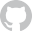
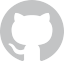

In [16]:
# @title
# ============================
# 08-2. 카드/섹션 HTML + 더보기 페이지 + 최종 뉴스레터 HTML
# ============================
# W_HEADER_BACKGROUND = "https://dekim-inspace.github.io/Newsletter/assets/USA_Sejong21.jpg"
W_HEADER_BACKGROUND = "https://dekim-inspace.github.io/Newsletter/assets/Newsletter_Image7.png"
HLOGO_URL = "https://dekim-inspace.github.io/Newsletter/assets/hlogo1.png"

# (NEW) 토픽별 더보기 페이지 헤더 이미지
TOPIC_MORE_HEADER_BACKGROUNDS = {
    1: "https://dekim-inspace.github.io/Newsletter/assets/header_geoint1.png",
    2: "https://dekim-inspace.github.io/Newsletter/assets/header_aviation.png",
    3: "https://dekim-inspace.github.io/Newsletter/assets/header_ai_platform1.png",
    4: "https://dekim-inspace.github.io/Newsletter/assets/header_satellite.jpg",
}

# (NEW) 연구동향 더보기 페이지 헤더 이미지
RESEARCH_MORE_HEADER_BACKGROUND = "https://dekim-inspace.github.io/Newsletter/assets/header_research2.png"

# (NEW) 인스페이스 기사 더보기 페이지 헤더 이미지
INSPACE_NEWS_HEADER_BG = "https://dekim-inspace.github.io/Newsletter/assets/header_geoint1.png"

if "weekly_focus_insight" not in globals() or not (weekly_focus_insight or "").strip():
    print("[INFO] weekly_focus_insight가 없어서 1회 생성합니다.")
    weekly_focus_insight = generate_weekly_focus_insight(
        topic_main_articles, topic_extra_articles,
        research_main_articles, research_extra_articles
    )
else:
    print("[INFO] 기존 weekly_focus_insight를 재사용합니다. (GPT 호출 없음)")


# 토픽별 추가 기사 전용 페이지 파일명
# (원하는 이름으로 바꿔도 되는데, 메인 버튼 링크와 같이 써야 함)
TOPIC_MORE_FILENAMES = {
    1: "more_geoint.html",        # GeoINT 전용 추가 기사
    2: "more_aviation.html",      # 항공/드론 전용 추가 기사
    3: "more_ai_platform.html",   # AI 데이터 플랫폼 전용 추가 기사
    4: "more_satellite.html",     # 위성 영상 전용 추가 기사
}

INSPACE_NEWS_MORE_FILENAME = "more-inspace.html"

# 토픽별 추가 기사 페이지 헤더 타이틀
TOPIC_MORE_TITLES = {
    1: "GeoINT - 추가 기사",
    2: "항공 / 드론·무인기(UAV/UAS) - 추가 기사",
    3: "AI 데이터 플랫폼 - 추가 기사",
    4: "위성 영상 - 추가 기사",
}

# 연구동향 more 페이지
RESEARCH_MORE_FILENAME = "more_research.html"


USE_KOREAN_FIRST = True  # True면 한글 제목 우선, False면 영문 우선

# ============================
# 공통 유틸: 저널/소스 라벨 정리
# ============================
def format_journal_source_label(journal_name: str) -> str:
    """
    'Remote Sensing (MDPI)' -> 'MDPI - Remote Sensing'
    'Journal of Applied Remote Sensing (SPIE)' -> 'SPIE - Journal of Applied Remote Sensing'
    """
    if not journal_name:
        return ""

    journal_name = journal_name.strip()
    m = re.match(r"(.+?)\s*\((.+)\)", journal_name)
    if not m:
        return journal_name

    main = m.group(1).strip()
    site = m.group(2).strip()
    return f"{site} - {main}"

def make_card(article, use_korean_first=USE_KOREAN_FIRST):
    ko = article.get("ko_title", "") or ""
    en = article.get("orig_title", "") or ""
    date = article.get("date", "") or ""
    summary = article.get("summary", "") or ""
    url = article.get("url", "") or ""
    thumb = article.get("thumbnail_url") or DEFAULT_THUMB

    # 한/영 제목 정리
    if ko and en:
        main_title, sub_title = (ko, en) if use_korean_first else (en, ko)
    else:
        main_title = ko or en
        sub_title = ""

    sub_block = ""
    if sub_title:
        sub_block = f"""
            <div style="font-size:14px; color:#555; margin-bottom:4px; line-height:1.35;">
              {h(sub_title)}
            </div>"""

    # ✅ 카드 전체를 링크로 감싸기 + '자세히 보기' 제거
    return f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0" style="margin-bottom:28px;">
  <tr>
    <td style="padding:0; margin:0;">

      <!-- ✅ 카드 전체 클릭 -->
      <a class="row-link"
        href="{h(url)}"
        target="_blank"
        style="text-decoration:none; color:inherit; display:block; padding:8px;">


        <table width="100%" cellpadding="0" cellspacing="0" border="0">
          <tr>
            <!-- 썸네일 (중첩 a 제거: 바깥 a만 사용) -->
            <td valign="top" width="135" style="padding:0;">
              <img src="{h(thumb)}" width="120" height="120"
                   style="display:block; border-radius:14px; object-fit:cover;"
                   onerror="this.onerror=null; this.src='{DEFAULT_THUMB}';">
            </td>

            <!-- 제목/부제목/날짜 -->
            <td valign="top" style="padding-left:6px;">
              <div style="font-size:18px; font-weight:700; color:#111;
                          margin-bottom:4px; line-height:1.35;">
                {h(main_title)}
              </div>

              {sub_block}

              <div style="font-size:12px; color:#888; margin-bottom:2px;">
                {h(date)}
              </div>
            </td>
          </tr>

          <!-- 요약 -->
          <tr>
            <td colspan="2" style="padding-top:12px;">
              <div style="font-size:14px; color:#333; line-height:1.8;">
                {h(summary)}
              </div>
            </td>
          </tr>
        </table>

      </a>
      <!-- 링크 끝 -->

    </td>
  </tr>
</table>
"""



def make_research_card_text_only(article):
    """
    💡 최신 연구동향 전용 텍스트 카드
    - 썸네일 없음
    - 카드 전체가 원문 링크로 클릭되도록 구성
    """
    title_en = article.get("title_en", "") or ""
    date = article.get("date", "") or ""
    summary = article.get("summary", "") or ""
    url = article.get("url", "") or ""

    journal_name = article.get("journal_name", "") or ""
    source_label = format_journal_source_label(journal_name)

    return f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:18px;">
  <tr>
    <!-- 여기 td에는 패딩/마진만 두고, 실제 카드 스타일은 안쪽 div에 줌 -->
    <td style="padding:0; margin:0;">

      <!-- ✅ 카드 전체를 감싸는 링크 -->
      <a href="{h(url)}" target="_blank"
         style="display:block; text-decoration:none; color:inherit;">

        <!-- 실제 카드 모양(배경, 테두리, 패딩)은 이 div에 적용 -->
        <div style="background:#ffffff; border-radius:12px;
                    border:1px solid #e5e7eb;
                    padding:16px 18px; box-sizing:border-box;
                    box-shadow:0 10px 24px rgba(0,0,0,0.14);">

          <!-- 영문 원제목 (굵게) -->
          <div style="font-size:17px; font-weight:700; color:#111827;
                      line-height:1.4; margin-bottom:4px;">
            {h(title_en)}
          </div>

          <!-- 소 -->
          <div style="font-size:12px; font-weight:500; color:#374151; margin-bottom:2px;">
            {h(source_label)}
          </div>

          <!-- 발행일 -->
          <div style="font-size:12px; color:#6b7280; margin-bottom:8px;">
            {h(date)}
          </div>

          <!-- 요약 (본문/요약 내용) -->
          <div style="font-size:14px; color:#374151; line-height:1.7;">
            {h(summary)}
          </div>

        </div>
      </a>
      <!-- 링크 끝 -->

    </td>
  </tr>
</table>
"""




def build_sections_html(topic_main_articles, topic_extra_articles):
    """
    메일 본문용 섹션:
    - 각 토픽의 메인 기사 카드들만 보여줌
    - 각 토픽 마지막에 '추가 기사' 관련 UI 표시
        → extra 있으면 : '이 주제 추가 기사 보기 →'
        → extra 없으면 : '이번 주는 추가 뉴스 기사가 없습니다'
    """
    html_parts = []

    for topic_num in [4, 3, 2, 1]:
        main_list = topic_main_articles.get(topic_num, [])
        extras = topic_extra_articles.get(topic_num, [])
        topic_title = f"{TOPIC_ICON[topic_num]} {TOPIC_DESC[topic_num]}"

        if not main_list:
            continue

        topic_inner = []

        # 토픽 제목
        topic_inner.append(f"""
<div style="font-size:26px; font-weight:800; color:#111827;
            margin-bottom:24px; line-height:1.3;">
  {h(topic_title)}
</div>
""")

        # 메인 기사 카드
        for art in main_list:
            topic_inner.append(make_card(art))

        # ⭐ 추가 기사 버튼 / 또는 추가 기사 없음 메시지
        if extras:
            # 정상 버튼 버전
            topic_inner.append(f"""
<div style="margin-top:12px; text-align:right;">
  <a href="{TOPIC_MORE_URLS[topic_num]}"
     style="display:inline-block; font-size:13px; font-weight:600;
            color:#111827; text-decoration:none;
            padding:6px 12px; border-radius:999px;
            border:1px solid #d1d5db; background:#ffffff;">
    이 주제 추가 기사 보기 →
  </a>
</div>
""")
        else:
            # ❗추가 기사 없음 메시지 버튼
            topic_inner.append(f"""
<div style="margin-top:12px; text-align:right;">
  <div style="display:inline-block; font-size:13px; font-weight:600;
              color:#9ca3af;
              padding:6px 12px; border-radius:999px;
              border:1px solid #e5e7eb; background:#f9fafb;">
    이번 주는 추가 뉴스 기사가 없습니다
  </div>
</div>
""")

        topic_html = "".join(topic_inner)

        html_parts.append(f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:36px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#f9fafb;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;
                    box-shadow:0 10px 24px rgba(0,0,0,0.14);">
        <tr>
          <td>
            {topic_html}
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
""")

    return "".join(html_parts)

def build_inspace_news_section_html(top_articles, more_articles, more_url):
    """
    🌐 인스페이스 관련 뉴스 섹션 HTML
    - 최신연구동향 섹션 다음에 배치
    """
    if not top_articles:
        return ""

    inner = []

    # 섹션 제목
    inner.append(f"""
<div style="font-size:26px; font-weight:800; color:#111827;
            margin-bottom:24px; line-height:1.3;">
  🌐 인스페이스 관련 뉴스
</div>
""")

    # 메인 기사 카드
    for art in top_articles:
        thumb = art.get("thumbnail_url") or DEFAULT_THUMB
        title = h(art.get("title", ""))
        summary = h(art.get("summary", ""))
        url = h(art.get("url", ""))
        published = art.get("published", "")
        source = art.get("source", "")

        inner.append(f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:28px;">
  <tr>
    <td style="padding:0; margin:0;">
      <a href="{url}" target="_blank"
         style="text-decoration:none; color:inherit; display:block;
                padding:12px; margin:-12px; border-radius:12px;
                transition:background-color 0.2s ease;"
         onmouseover="this.style.backgroundColor='#ffffff'"
         onmouseout="this.style.backgroundColor='transparent'">
        <table width="100%" cellpadding="0" cellspacing="0" border="0">
          <tr>
            <td valign="top" width="135" style="padding:0;">
              <img src="{h(thumb)}" width="120" height="120"
                   style="display:block; border-radius:14px; object-fit:cover;"
                   onerror="this.onerror=null; this.src='{DEFAULT_THUMB}';">
            </td>
            <td valign="top" style="padding-left:6px;">
              <div style="font-size:18px; font-weight:700; color:#111;
                          margin-bottom:4px; line-height:1.35;">
                {title}
              </div>
              {f'<div style="font-size:12px; font-weight:500; color:#374151; margin-bottom:2px;">{h(source)}</div>' if source else ''}
              <div style="font-size:12px; color:#6b7280; margin-bottom:2px;">
                {h(published)}
              </div>
            </td>
          </tr>
          <tr>
            <td colspan="2" style="padding-top:12px;">
              <div style="font-size:14px; color:#333; line-height:1.8;">
                {summary}
              </div>
            </td>
          </tr>
        </table>
      </a>
    </td>
  </tr>
</table>
""")

    # 추가 기사 버튼
    if more_articles:
        inner.append(f"""
<div style="margin-top:12px; text-align:right;">
  <a href="{h(more_url)}"
     style="display:inline-block; font-size:13px; font-weight:600;
            color:#111827; text-decoration:none;
            padding:6px 12px; border-radius:999px;
            border:1px solid #d1d5db; background:#ffffff;">
    더 많은 기사 보기 →
  </a>
</div>
""")
    else:
        inner.append("""
<div style="margin-top:12px; text-align:right;">
  <span style="display:inline-block; font-size:13px; font-weight:600;
               color:#9ca3af;
               padding:6px 12px; border-radius:999px;
               border:1px solid #e5e7eb; background:#f9fafb;">
    추가 기사가 없습니다
  </span>
</div>
""")

    body_html = "".join(inner)

    return f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:36px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#f9fafb;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;
                    box-shadow:0 10px 24px rgba(0,0,0,0.14);">
        <tr>
          <td>
            {body_html}
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
"""


def build_inspace_more_page_html(more_articles, date_range, newsletter_date):
    """
    🌐 인스페이스 추가 기사 페이지 HTML (기존 헤더 스타일 유지)
    """
    if not more_articles:
        return ""

    rows = []
    for idx, art in enumerate(more_articles):
        thumb = art.get("thumbnail_url") or DEFAULT_THUMB
        title = h(art.get("title", ""))
        subtitle = h(art.get("subtitle", ""))
        url = h(art.get("url", ""))
        published = art.get("published", "")

        sub_block = ""
        if subtitle:
            sub_block = f'''
        <div style="font-size:12px; color:#6b7280; margin-top:2px; line-height:1.4;">
          {subtitle}
        </div>'''

        rows.append(f"""
                  <tr class="inspace-article-row" data-index="{idx}">
                    <td style="padding:0; border-bottom:1px solid #e5e7eb;">
                      <a href="{url}" target="_blank"
                        style="text-decoration:none; color:inherit; display:block; padding:10px 0;
                              transition:background-color 0.2s ease;"
                        onmouseover="this.style.backgroundColor='#f3f4f6'"
                        onmouseout="this.style.backgroundColor='transparent'">
                        <table width="100%" cellpadding="0" cellspacing="0" border="0">
                          <tr>
                            <td valign="top" width="96" style="padding-right:8px;">
                              <img src="{h(thumb)}" width="80" height="80"
                                  style="display:block; border-radius:10px; object-fit:cover;"
                                  onerror="this.onerror=null; this.src='{DEFAULT_THUMB}';">
                            </td>

                            <td valign="top">
                              <div style="font-size:14px; line-height:1.5; margin-bottom:2px; color:#111827;">
                                {title}
                              </div>
                              {sub_block}
                              <div style="font-size:11px; color:#9ca3af; margin-top:2px;">
                                {h(published)}
                              </div>
                            </td>
                          </tr>
                        </table>
                      </a>
                    </td>
                  </tr>
                """)


    table_html = f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0">
  {''.join(rows)}
</table>
"""

    pager_html = f"""
<div id="inspace-pagination"
     style="display:flex;
            justify-content:flex-end;
            align-items:center;
            font-size:14px;
            color:#4b5563;
            margin-bottom:12px;">
  <span id="inspace-page-info" style="margin-right:14px;"></span>
  <a href="#" id="inspace-prev"
     style="width:32px; height:32px;
            border:1px solid #d1d5db;
            border-radius:8px;
            display:flex; align-items:center; justify-content:center;
            text-decoration:none; color:#374151;
            margin-right:4px;">‹</a>
  <a href="#" id="inspace-next"
     style="width:32px; height:32px;
            border:1px solid #d1d5db;
            border-radius:8px;
            display:flex; align-items:center; justify-content:center;
            text-decoration:none; color:#374151;">›</a>
</div>
"""

    body_inner = f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:28px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#ffffff;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;">
        <tr>
          <td>
            <div style="font-size:24px; font-weight:700; color:#111827;
                        margin-bottom:16px;">
              🌐 인스페이스 추가 기사
            </div>
            {pager_html}
            {table_html}
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
"""

    header_bg = INSPACE_NEWS_HEADER_BG

    more_html = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/orioncactus/pretendard/dist/web/static/pretendard.css">

<title>인스페이스 - 추가 기사</title>

<style>
  @media (max-width: 768px) {{
    .hero-bg {{
      background-position:center 0 !important;
    }}
    .hero-header-cell {{
      padding: 14px 0 0 0 !important;
    }}
  }}

  html, body {{
    height: 100%;
    margin: 0;
  }}

  body {{
    display: flex;
    flex-direction: column;
    min-height: 100vh;
    background:#f3f4f6;
    font-family:"Pretendard",-apple-system,BlinkMacSystemFont,"Apple SD Gothic Neo","맑은 고딕",system-ui,sans-serif;
  }}

  .content-wrapper {{
    flex: 1;
  }}

  /* ✅ (NEW) 행 전체 클릭 링크 + 행 전체 hover */
  a.row-link{{
    display:block;
    width:100%;
    text-decoration:none;
    color:inherit;
  }}
  a.row-link:hover{{
    background:#f3f4f6;
  }}

</style>

</head>

<body>

  <!-- 헤더 -->
  <table class="hero-bg" width="100%" cellpadding="0" cellspacing="0" border="0"
       style="background-image:url('{header_bg}');
              background-size:cover;
              background-position:center 52%;
              background-repeat:no-repeat;">
    <tr>
      <td align="center" class="hero-header-cell"
          bgcolor="#000000"
          style="padding:8px 24px 8px 24px;
                 background: linear-gradient(to bottom right,
                             rgba(255,255,255,0.70),
                             rgba(255,255,255,0.70));
                 color:#ffffff;">

        <table cellpadding="0" cellspacing="0" border="0"
               style="max-width:{CONTENT_WIDTH}px; width:100%;
                      color:#000000; margin:0 auto;">

          <tr>
            <td style="padding:16px 24px 8px 24px;">
              <table width="100%">
                <tr>
                  <td align="left">
                    <img src="{HLOGO_URL}" style="max-width:110px; display:block;">
                  </td>
                  <td align="right"
                      style="text-transform:uppercase; font-size:13px; font-weight:500;
                             color:#000000;">
                    WWW.INSPACE.CO.KR
                  </td>
                </tr>
              </table>
            </td>
          </tr>

          <tr>
            <td align="center"
                style="padding:12px 24px 12px 24px;
                      font-size:28px; font-weight:700;
                      font-family:'Pretendard',-apple-system,BlinkMacSystemFont,'Apple SD Gothic Neo','맑은 고딕',system-ui,sans-serif;
                      color:#000000;">
              인스페이스 - 추가 기사
            </td>
          </tr>

          <tr>
            <td align="center"
                style="padding:0 24px 48px 24px;
                       font-size:14px; font-weight:500; opacity:0.9; line-height:1.5;
                       color:#000000;">
              {date_range}<br>
              {WEEK_LABEL} 뉴스레터
            </td>
          </tr>

        </table>

      </td>
    </tr>
  </table>

  <div class="content-wrapper">
  <table width="100%" cellpadding="0" cellspacing="0" border="0" style="padding:24px 0 32px 0;">
    <tr>
      <td align="center">
        <table cellpadding="0" cellspacing="0" border="0"
              style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
          <tr>
            <td style="padding:0 16px 0 16px;">

              <div style="padding-bottom:20px; text-align:left;">
                <a href="{MAIN_PAGE_URL}"
                  style="display:inline-block;
                          font-size:13px;
                          padding:6px 12px;
                          border-radius:999px;
                          background:#111827;
                          color:#ffffff;
                          text-decoration:none;">
                  ← 메인 뉴스레터로 돌아가기
                </a>
              </div>

              {body_inner}

            </td>
          </tr>
        </table>
      </td>
    </tr>
  </table>
  </div>

  <!-- 푸터 -->
  <table width="100%" cellpadding="0" cellspacing="0" border="0"
        style="background:#1e293b; padding:24px 0 32px 0;">
    <tr>
      <td align="center">
        <table cellpadding="0" cellspacing="0" border="0"
              style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
          <tr>
            <td class="inner-padding"
                style="padding:12px 16px;
                      font-size:12px;
                      color:#e2e8f0;
                      text-align:center;
                      line-height:1.6;">

              InSpace Weekly는 인스페이스 구성원 여러분의 산업 동향 파악과 인사이트 함양을 위해 매주 발행되는 사내 주간 브리핑입니다.<br>
              본 메일의 내용과 관련하여 추가적인 정보가 필요하시거나 의견이 있으신 경우 대외협력실로 문의주시면 성실히 답변드리겠습니다.<br><br>
              &copy; {now_kst.year}  InSpace Co., Ltd. All Rights Reserved.

            </td>
          </tr>
        </table>
      </td>
    </tr>
  </table>

  <script>
  (function() {{
    var PAGE_SIZE = {INSPACE_NEWS_MORE_PAGE_SIZE};
    var rows = Array.prototype.slice.call(
      document.querySelectorAll('.inspace-article-row')
    );
    var total = rows.length;
    var totalPages = Math.max(1, Math.ceil(total / PAGE_SIZE));
    var currentPage = 1;

    var infoEl = document.getElementById('inspace-page-info');
    var prevEl = document.getElementById('inspace-prev');
    var nextEl = document.getElementById('inspace-next');

    function render(page) {{
      if (page < 1 || page > totalPages) return;
      currentPage = page;

      var start = (currentPage - 1) * PAGE_SIZE;
      var end = start + PAGE_SIZE;

      rows.forEach(function(row, idx) {{
        row.style.display = (idx >= start && idx < end) ? '' : 'none';
      }});

      if (infoEl) {{
        var from = total === 0 ? 0 : start + 1;
        var to = Math.min(end, total);
        infoEl.textContent = from + '–' + to + ' of ' + total;
      }}

      if (prevEl) {{
        prevEl.style.opacity = currentPage === 1 ? '0.3' : '1';
        prevEl.style.pointerEvents = currentPage === 1 ? 'none' : 'auto';
      }}

      if (nextEl) {{
        nextEl.style.opacity = currentPage === totalPages ? '0.3' : '1';
        nextEl.style.pointerEvents = currentPage === totalPages ? 'none' : 'auto';
      }}
    }}

    if (prevEl) prevEl.addEventListener('click', function(e) {{
      e.preventDefault();
      render(currentPage - 1);
    }});

    if (nextEl) nextEl.addEventListener('click', function(e) {{
      e.preventDefault();
      render(currentPage + 1);
    }});

    render(1);
  }})();
  </script>

</body>
</html>
"""
    return more_html



def build_research_section_html(main_articles, extra_articles, more_url):
    """
    메인 뉴스레터 본문에서 사용하는 '💡 최신 연구동향' 섹션 HTML
    - 카드 UI는 기존 뉴스 카드와 동일하게 make_card() 재사용
    - '최신 연구 더 보기 →' 버튼만 표시
    """
    if not main_articles:
        return ""

    inner = []

    # 섹션 제목
    inner.append(f"""
<div style="font-size:26px; font-weight:800; color:#111827;
            margin-bottom:24px; line-height:1.3;">
  {h(RESEARCH_SECTION_TITLE)}
</div>
""")

    # 1) 메인 연구동향 카드들 → '텍스트-only' 연구 카드 사용
    for art in main_articles:
        converted = {
            "title_en": art.get("original_title", ""),
            "date": art.get("published_at", ""),
            "summary": art.get("summary_en", ""),
            "url": art.get("url", ""),
            "journal_name": art.get("journal_name", ""),  # ✅ 추가
        }


        inner.append(make_research_card_text_only(converted))



    # 2) '최신 연구 더 보기 →' 버튼만 표시
    if extra_articles:
        inner.append(f"""
<div style="margin-top:12px; text-align:right;">
  <a href="{h(more_url)}"
     style="display:inline-block; font-size:13px; font-weight:600;
            color:#111827; text-decoration:none;
            padding:6px 12px; border-radius:999px;
            border:1px solid #d1d5db; background:#ffffff;">
    최신 연구 더 보기 →
  </a>
</div>
""")

    # 3) 전체 박스 레이아웃 감싸기
    body_html = "".join(inner)

    return f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:36px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#f9fafb;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;">
        <tr>
          <td>
            {body_html}
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
"""


def build_more_page_html(topic_extra_articles, date_range, newsletter_date, header_title, header_bg_url=None):
    """
    토픽별 '추가 기사' 페이지 HTML 생성
    - topic_extra_articles: {토픽번호: [기사 리스트]} 형태 (보통 1개 토픽만 들어오게 사용)
    - header_title: 상단 헤더에 들어갈 타이틀 (예: "GeoINT - 추가 기사")
    """
    # ✅ (핵심) 이 페이지에서 쓸 헤더 배경을 확정
    header_bg = header_bg_url or W_HEADER_BACKGROUND

    sections = []

    for topic_num in [1, 2, 3, 4]:
        extras = topic_extra_articles.get(topic_num, [])
        if not extras:
            continue

        topic_title = f"{TOPIC_ICON[topic_num]} {TOPIC_DESC[topic_num]}"

        rows = []
        for idx, art in enumerate(extras):
            ko = art.get("ko_title", "") or ""
            en = art.get("orig_title", "") or ""
            url = art.get("url", "") or ""
            date = art.get("date", "") or ""
            thumb = art.get("thumbnail_url") or DEFAULT_THUMB

            main_title = ko or en
            sub_title = en if ko else ""

            sub_block = ""
            if sub_title:
                sub_block = f"""
        <div style="font-size:12px; color:#6b7280; margin-top:2px; line-height:1.4;">
          {h(sub_title)}
        </div>"""

            # ✅ 테이블 구조를 올바르게: <tr> 안에 다시 <tr> 넣지 않기
            rows.append(f"""
              <tr class="topic-article-row" data-index="{idx}">
                <td style="padding:0; border-bottom:1px solid #e5e7eb;">
                  <a class="row-link" href="{h(url)}" target="_blank"
                    style="text-decoration:none; color:inherit; display:block; padding:10px 0;">
                    <table width="100%" cellpadding="0" cellspacing="0" border="0">
                      <tr>
                        <!-- 썸네일 -->
                        <td valign="top" width="96" style="padding-right:8px;">
                          <img src="{h(thumb)}" width="80" height="80"
                              style="display:block; border-radius:10px; object-fit:cover;"
                              onerror="this.onerror=null; this.src='{DEFAULT_THUMB}';">
                        </td>

                        <!-- 제목/부제목/날짜 -->
                        <td valign="top">
                          <div style="font-size:14px; line-height:1.5; margin-bottom:2px; color:#111827;">
                            {h(main_title)}
                          </div>
                          {sub_block}
                          <div style="font-size:11px; color:#9ca3af; margin-top:2px;">
                            {h(date)}
                          </div>
                        </td>
                      </tr>
                    </table>
                  </a>
                </td>
              </tr>
            """)



        table_html = f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0">
  {''.join(rows)}
</table>
"""

        # Gmail 스타일 페이지 정보 + 좌우 버튼 영역
        pager_html = f"""
<div id="topic-pagination"
     style="display:flex;
            justify-content:flex-end;
            align-items:center;
            font-size:14px;
            font-weight:500;
            color:#374151;
            margin-top:-10px;
            margin-bottom:10px;">

  <span id="topic-page-info"
        style="margin-right:14px;"></span>

  <!-- 이전 버튼 -->
  <a href="#" id="topic-prev"
     style="
       display:inline-flex;
       align-items:center;
       justify-content:center;
       width:32px;
       height:32px;
       margin-right:6px;
       border:1px solid #d1d5db;
       border-radius:8px;
       text-decoration:none;
       background-color:#ffffff;
       cursor:pointer;
     ">
    <span style="
       display:inline-block;
       font-size:18px;
       font-weight:600;
       color:#374151;
       transform: translateY(-3px);
    ">
      &#x2039;
    </span>
  </a>

  <!-- 다음 버튼 -->
  <a href="#" id="topic-next"
     style="
       display:inline-flex;
       align-items:center;
       justify-content:center;
       width:32px;
       height:32px;
       border:1px solid #d1d5db;
       border-radius:8px;
       text-decoration:none;
       background-color:#ffffff;
       cursor:pointer;
     ">
    <span style="
       display:inline-block;
       font-size:18px;
       font-weight:600;
       color:#374151;
       transform: translateY(-3px);
    ">
      &#x203A;
    </span>
  </a>
</div>
"""

        sections.append(f"""
<!-- 토픽별 추가 기사 박스 -->
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:28px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#ffffff;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;">
        <tr>
          <td>
            <div style="font-size:24px; font-weight:700; color:#111827;
                        margin-bottom:28px;">
              {h(topic_title)}
            </div>
            {pager_html}
            {table_html}
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
""")

    if not sections:
        body_inner = """
<p style="font-size:14px; color:#4b5563;">
  이번 주는 별도의 추가 기사가 없습니다.
</p>
"""
    else:
        body_inner = "".join(sections)

    header_bg = header_bg_url or HEADER_BACKGROUND
    more_html = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/orioncactus/pretendard/dist/web/static/pretendard.css">



<title>{header_title}</title>

<style>
  /* 모바일 최적화 */
  @media (max-width: 768px) {{
    .hero-bg {{
      background-position:center 0 !important;
    }}
    /* ✅ 모바일에서 헤더 상하 여백 축소 (추가 기사 페이지 전용) */
    .hero-header-cell {{
      padding: 14px 0 0 0 !important;
    }}
  }}

  /* 푸터를 항상 아래로 밀어주는 레이아웃 */
  html, body {{
    height: 100%;
    margin: 0;
  }}

  body {{
    display: flex;
    flex-direction: column;
    min-height: 100vh;
    background:#f3f4f6;
    font-family:"Pretendard",-apple-system,BlinkMacSystemFont,"Apple SD Gothic Neo","맑은 고딕",system-ui,sans-serif;
  }}

  .content-wrapper {{
    flex: 1;
  }}

  /* ✅ (NEW) 행 전체 클릭 링크 + 행 전체 hover */
  a.row-link{{
    display:block;
    width:100%;
    text-decoration:none;
    color:inherit;
  }}
  a.row-link:hover{{
    background:#f3f4f6;
  }}

</style>



</head>

<body>

  <!-- 헤더 (메일과 유사한 스타일) -->
  <table class="hero-bg" width="100%" cellpadding="0" cellspacing="0" border="0"
       style="background-image:url('{header_bg}');
              background-size:cover;
              background-position:center 52%;
              background-repeat:no-repeat;">
    <tr>
      <td align="center" class="hero-header-cell"
          bgcolor="#000000"
          style="padding:8px 24px 8px 24px;
                 background: linear-gradient(to bottom right,
                             rgba(255,255,255,0.70),
                             rgba(255,255,255,0.70));
                 color:#ffffff; ;">

        <table cellpadding="0" cellspacing="0" border="0"
               style="max-width:{CONTENT_WIDTH}px; width:100%;
                      color:#000000; margin:0 auto;">

          <tr>
            <td style="padding:16px 24px 8px 24px;">
              <table width="100%">
                <tr>
                  <td align="left">
                    <img src="{HLOGO_URL}" style="max-width:110px; display:block;">
                  </td>
                  <td align="right"
                      style="text-transform:uppercase; font-size:13px; font-weight:500;
                             color:#000000; ;">
                    WWW.INSPACE.CO.KR
                  </td>
                </tr>
              </table>
            </td>
          </tr>

          <tr>
            <td align="center"
                style="padding:12px 24px 12px 24px;
                      font-size:28px; font-weight:700;
                      font-family:'Pretendard',-apple-system,BlinkMacSystemFont,'Apple SD Gothic Neo','맑은 고딕',system-ui,sans-serif;
                      color:#000000; ;">
              {h(header_title)}
            </td>
          </tr>

          <tr>
            <td align="center"
                style="padding:0 24px 48px 24px;
                       font-size:14px; font-weight:500; opacity:0.9; line-height:1.5;
                       color:#000000; ;">
              {date_range}<br>
              {WEEK_LABEL} 뉴스레터
            </td>
          </tr>

        </table>

      </td>
    </tr>
  </table>


  <div class="content-wrapper">
  <!-- 본문 -->
  <table width="100%" cellpadding="0" cellspacing="0" border="0" style="padding:24px 0 32px 0;">
    <tr>
      <td align="center">
        <table cellpadding="0" cellspacing="0" border="0"
              style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
          <tr>
            <td style="padding:0 16px 0 16px;">

              <!-- 메인 뉴스레터로 돌아가기 버튼 (카드 위 왼쪽 정렬) -->
              <div style="padding-bottom:20px; text-align:left;">
                <a href="{MAIN_PAGE_URL}"
                  style="display:inline-block;
                          font-size:13px;
                          padding:6px 12px;
                          border-radius:999px;
                          background:#111827;
                          color:#ffffff;
                          text-decoration:none;">
                  ← 메인 뉴스레터로 돌아가기
                </a>
              </div>

              {body_inner}

            </td>
          </tr>
        </table>
      </td>
    </tr>
  </table>
  </div> <!-- content-wrapper 끝 -->

  <!-- 푸터 -->
  <table width="100%" cellpadding="0" cellspacing="0" border="0"
        style="background:#1e293b; padding:24px 0 32px 0;">
    <tr>
      <td align="center">
        <table cellpadding="0" cellspacing="0" border="0"
              style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
          <tr>
            <td class="inner-padding"
                style="padding:12px 16px;
                      font-size:12px;
                      color:#e2e8f0;
                      text-align:center;
                      line-height:1.6;">

              InSpace Weekly는 인스페이스 구성원 여러분의 산업 동향 파악과 인사이트 함양을 위해 매주 발행되는 사내 주간 브리핑입니다.<br>
              본 메일의 내용과 관련하여 추가적인 정보가 필요하시거나 의견이 있으신 경우 대외협력실로 문의주시면 성실히 답변드리겠습니다.<br><br>
              &copy; {now_kst.year}  InSpace Co., Ltd. All Rights Reserved.

            </td>
          </tr>
        </table>
      </td>
    </tr>
  </table>

  <script>
  (function() {{
    // ✅ 토픽 추가 기사 페이지네이션 (GeoINT/드론/AI/위성 공통)
    var PAGE_SIZE = 5;  // 한 페이지에 5개씩 보여줌 (10개로 바꾸고 싶으면 여기 숫자만 10으로 변경)

    var rows = Array.prototype.slice.call(
      document.querySelectorAll('.topic-article-row')
    );
    var total = rows.length;
    var totalPages = Math.max(1, Math.ceil(total / PAGE_SIZE));
    var currentPage = 1;

    var infoEl = document.getElementById('topic-page-info');
    var prevEl = document.getElementById('topic-prev');
    var nextEl = document.getElementById('topic-next');

    function render(page) {{
      if (page < 1 || page > totalPages) return;
      currentPage = page;

      var start = (currentPage - 1) * PAGE_SIZE;
      var end = start + PAGE_SIZE;

      rows.forEach(function(row, idx) {{
        row.style.display = (idx >= start && idx < end) ? '' : 'none';
      }});

      if (infoEl) {{
        var from = total === 0 ? 0 : start + 1;
        var to = Math.min(end, total);
        infoEl.textContent = from + '–' + to + ' of ' + total;
      }}

      if (prevEl) {{
        if (currentPage === 1) {{
          prevEl.style.opacity = '0.3';
          prevEl.style.pointerEvents = 'none';
        }} else {{
          prevEl.style.opacity = '1';
          prevEl.style.pointerEvents = 'auto';
        }}
      }}

      if (nextEl) {{
        if (currentPage === totalPages) {{
          nextEl.style.opacity = '0.3';
          nextEl.style.pointerEvents = 'none';
        }} else {{
          nextEl.style.opacity = '1';
          nextEl.style.pointerEvents = 'auto';
        }}
      }}
    }}

    if (prevEl) prevEl.addEventListener('click', function(e) {{
      e.preventDefault();
      render(currentPage - 1);
    }});

    if (nextEl) nextEl.addEventListener('click', function(e) {{
      e.preventDefault();
      render(currentPage + 1);
    }});

    render(1);
  }})();
  </script>


</body>
</html>
"""
    return more_html


def build_research_more_page_html(extra_articles, date_range, newsletter_date, header_bg_url=None):

    """
    💡 최신 연구동향 - 추가 학술지 페이지 HTML
    - 레이아웃: build_more_page_html(GeoINT 등)과 동일
      * 같은 헤더(히어로 영역)
      * 같은 '메인 뉴스레터로 돌아가기' 버튼
      * 같은 푸터
      * 본문은 흰색 카드 박스 안에 '💡 최신 연구동향' 제목 + 논문 리스트
    """
    # 1) 본문(논문 리스트) HTML 만들기
    if not extra_articles:
        # 추가 학술지가 없을 때: 카드 안에 안내 문구만
        topic_title = "💡 최신 연구동향 - 추가 학술지"
        body_inner = f"""
<!-- 최신 연구동향 추가 학술지 박스 (데이터 없음) -->
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:28px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#ffffff;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;">
        <tr>
          <td>
            <div style="font-size:24px; font-weight:700; color:#111827;
                        margin-bottom:16px;">
              {h(topic_title)}
            </div>
            <p style="font-size:14px; color:#4b5563; margin:0;">
              이번 주에는 추가 학술지가 없습니다.
            </p>
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
"""


    else:
        # 논문들 리스트를 rows로 쌓기
        rows = []
        for idx, art in enumerate(extra_articles):
            title_en = art.get("original_title", "") or ""
            date = art.get("published_at", "") or ""
            url = art.get("url", "") or ""
            journal_name = art.get("journal_name", "") or ""

            # 'Remote Sensing (MDPI)' -> 'MDPI - Remote Sensing' 변환
            source_label = format_journal_source_label(journal_name)

            rows.append(f"""
              <tr class="research-article-row" data-index="{idx}">
                <td style="padding:0; border-bottom:1px solid #e5e7eb;">
                  <a class="row-link" href="{h(url)}" target="_blank"
                    style="text-decoration:none; color:inherit; display:block; padding:10px 0;">
                    <!-- 영문 원제목 -->
                    <div style="font-size:14px; font-weight:600; line-height:1.5; margin-bottom:4px; color:#111827;">
                      {h(title_en)}
                    </div>

                    <!-- 저널(출처) -->
                    <div style="font-size:12px; color:#6b7280; margin-bottom:4px;">
                      {h(source_label)}
                    </div>

                    <!-- 날짜 -->
                    <div style="font-size:11px; color:#9ca3af; margin-bottom:6px;">
                      {h(date)}
                    </div>

                  </a>
                </td>
              </tr>
            """)




        table_html = f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0">
  {''.join(rows)}
</table>
"""

        # Gmail 스타일 페이지 정보 + 좌우 버튼 영역
        pager_html = f"""
<div id="research-pagination"
     style="display:flex;
            justify-content:flex-end;
            align-items:center;
            font-size:14px;
            font-weight:500;
            color:#374151;
            margin-top:-10px;
            margin-bottom:10px;">

  <span id="research-page-info"
        style="margin-right:14px;"></span>

  <!-- 이전 버튼 -->
  <a href="#" id="research-prev"
     style="
       display:inline-flex;
       align-items:center;
       justify-content:center;
       width:32px;
       height:32px;
       margin-right:6px;
       border:1px solid #d1d5db;
       border-radius:8px;
       text-decoration:none;
       background-color:#ffffff;
       cursor:pointer;
     ">
    <span style="
       display:inline-block;
       font-size:18px;
       font-weight:600;
       color:#374151;
       transform: translateY(-3px);
    ">
      &#x2039;
    </span>
  </a>

  <!-- 다음 버튼 -->
  <a href="#" id="research-next"
     style="
       display:inline-flex;
       align-items:center;
       justify-content:center;
       width:32px;
       height:32px;
       border:1px solid #d1d5db;
       border-radius:8px;
       text-decoration:none;
       background-color:#ffffff;
       cursor:pointer;
     ">
    <span style="
       display:inline-block;
       font-size:18px;
       font-weight:600;
       color:#374151;
       transform: translateY(-3px);
    ">
      &#x203A;
    </span>
  </a>
</div>
"""



        topic_title = "💡 최신 연구동향"

        # GeoINT용 more 페이지와 동일한 카드 박스 구조로 감싸기
        body_inner = f"""
<!-- 최신 연구동향 추가 학술지 박스 -->
<table width="100%" cellpadding="0" cellspacing="0" border="0"
       style="margin-bottom:28px;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="width:100%;
                    max-width:{CONTENT_WIDTH}px;
                    background:#ffffff;
                    border:1px solid #e5e7eb;
                    border-radius:12px;
                    padding:20px;
                    box-sizing:border-box;">
        <tr>
          <td>
            <div style="font-size:24px; font-weight:700; color:#111827;
                        margin-bottom:28px;">
              {h(topic_title)}
            </div>
              {pager_html}
              {table_html}
          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>
"""

    # 상단 히어로 헤더에 들어갈 타이틀 (탭 제목도 같이 사용)
    header_title = "최신 연구동향 - 추가 학술지"
    header_bg = header_bg_url or HEADER_BACKGROUND
    more_html = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/orioncactus/pretendard/dist/web/static/pretendard.css">




<title>{header_title}</title>

<style>
  /* 모바일 최적화 */
  @media (max-width: 768px) {{
    .hero-bg {{
      background-position:center 0 !important;
    }}
    /* ✅ 모바일에서 헤더 상하 여백 축소 (추가 기사 페이지 전용) */
    .hero-header-cell {{
      padding: 14px 0 0 0 !important;
    }}
  }}

  /* 푸터를 항상 아래로 밀어주는 레이아웃 */
  html, body {{
    height: 100%;
    margin: 0;
  }}

  body {{
    display: flex;
    flex-direction: column;
    min-height: 100vh;
    background:#f3f4f6;
    font-family:"Pretendard",-apple-system,BlinkMacSystemFont,"Apple SD Gothic Neo","맑은 고딕",system-ui,sans-serif;
  }}

  .content-wrapper {{
    flex: 1;
  }}

  /* ✅ (NEW) 행 전체 클릭 링크 + 행 전체 hover */
  a.row-link{{
    display:block;
    width:100%;
    text-decoration:none;
    color:inherit;
  }}
  a.row-link:hover{{
    background:#f3f4f6;
  }}

</style>


</head>

<body>

  <!-- 헤더 (more_geoint와 동일 구조) -->
  <table class="hero-bg" width="100%" cellpadding="0" cellspacing="0" border="0"
       style="background-image:url('{header_bg}');
              background-size:cover;
              background-position:center 70%;
              background-repeat:no-repeat;">
    <tr>
      <td align="center" class="hero-header-cell"
          bgcolor="#000000"
          style="padding:8 24px 8px 24px;
                 background: linear-gradient(to bottom right,
                             rgba(255,255,255,0.10),
                             rgba(255,255,255,0.10));
                 color:#ffffff; ;">

        <table cellpadding="0" cellspacing="0" border="0"
               style="max-width:{CONTENT_WIDTH}px; width:100%;
                      color:#000000; margin:0 auto;">

          <tr>
            <td style="padding:16px 24px 8px 24px;">
              <table width="100%">
                <tr>
                  <td align="left">
                    <img src="{HLOGO_URL}" style="max-width:110px; display:block;">
                  </td>
                  <td align="right"
                      style="text-transform:uppercase; font-size:13px; font-weight:500;
                             color:#000000; ;">
                    WWW.INSPACE.CO.KR
                  </td>
                </tr>
              </table>
            </td>
          </tr>

          <tr>
            <td align="center"
                style="padding:12px 24px 12px 24px;
                      font-size:28px; font-weight:700;
                      font-family:'Pretendard',-apple-system,BlinkMacSystemFont,'Apple SD Gothic Neo','맑은 고딕',system-ui,sans-serif;
                      color:#000000; ;">
              {h(header_title)}
            </td>

          </tr>

          <tr>
            <td align="center"
                style="padding:0 24px 48px 24px;
                       font-size:14px; font-weight:500; opacity:0.9; line-height:1.5;
                       color:#000000; ;">
              {date_range}<br>
              {WEEK_LABEL} 뉴스레터
            </td>
          </tr>

        </table>

      </td>
    </tr>
  </table>


  <div class="content-wrapper">
  <!-- 본문 -->
  <table width="100%" cellpadding="0" cellspacing="0" border="0" style="padding:24px 0 32px 0;">
    <tr>
      <td align="center">
        <table cellpadding="0" cellspacing="0" border="0"
              style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
          <tr>
            <td style="padding:0 16px 0 16px;">

              <!-- 메인 뉴스레터로 돌아가기 버튼 -->
              <div style="padding-bottom:20px; text-align:left;">
                <a href="{MAIN_PAGE_URL}"
                  style="display:inline-block;
                          font-size:13px;
                          padding:6px 12px;
                          border-radius:999px;
                          background:#111827;
                          color:#ffffff;
                          text-decoration:none;">
                  ← 메인 뉴스레터로 돌아가기
                </a>
              </div>

              {body_inner}

            </td>
          </tr>
        </table>
      </td>
    </tr>
  </table>
  </div> <!-- content-wrapper 끝 -->


  <!-- 푸터 (more_geoint와 동일) -->
  <table width="100%" cellpadding="0" cellspacing="0" border="0"
        style="background:#1e293b; padding:24px 0 32px 0;">
    <tr>
      <td align="center">
        <table cellpadding="0" cellspacing="0" border="0"
              style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
          <tr>
            <td class="inner-padding"
                style="padding:12px 16px;
                      font-size:12px;
                      color:#e2e8f0;
                      text-align:center;
                      line-height:1.6;">

              InSpace Weekly는 인스페이스 구성원 여러분의 산업 동향 파악과 인사이트 함양을 위해 매주 발행되는 사내 주간 브리핑입니다.<br>
              본 메일의 내용과 관련하여 추가적인 정보가 필요하시거나 의견이 있으신 경우, 대외협력실로 문의주시면 성실히 답변드리겠습니다.<br><br>
              &copy; {now_kst.year}  InSpace Co., Ltd. All Rights Reserved.

            </td>
          </tr>
        </table>
      </td>
    </tr>
  </table>


  <script>
  (function() {{
    var PAGE_SIZE = 5; // ✅ 5개씩 보여주기

    var rows = Array.prototype.slice.call(
      document.querySelectorAll('.research-article-row')
    );
    var total = rows.length;
    var totalPages = Math.max(1, Math.ceil(total / PAGE_SIZE));
    var currentPage = 1;

    var infoEl = document.getElementById('research-page-info');
    var prevEl = document.getElementById('research-prev');
    var nextEl = document.getElementById('research-next');

    function render(page) {{
      if (page < 1 || page > totalPages) return;
      currentPage = page;

      var start = (currentPage - 1) * PAGE_SIZE;
      var end = start + PAGE_SIZE;

      rows.forEach(function(row, idx) {{
        row.style.display = (idx >= start && idx < end) ? '' : 'none';
      }});

      if (infoEl) {{
        var from = total === 0 ? 0 : start + 1;
        var to = Math.min(end, total);
        infoEl.textContent = from + '–' + to + ' of ' + total;
      }}

      if (prevEl) {{
        if (currentPage === 1) {{
          prevEl.style.opacity = '0.3';
          prevEl.style.pointerEvents = 'none';
        }} else {{
          prevEl.style.opacity = '1';
          prevEl.style.pointerEvents = 'auto';
        }}
      }}

      if (nextEl) {{
        if (currentPage === totalPages) {{
          nextEl.style.opacity = '0.3';
          nextEl.style.pointerEvents = 'none';
        }} else {{
          nextEl.style.opacity = '1';
          nextEl.style.pointerEvents = 'auto';
        }}
      }}

    }}

    if (prevEl) prevEl.addEventListener('click', function(e) {{
      e.preventDefault();
      render(currentPage - 1);
    }});

    if (nextEl) nextEl.addEventListener('click', function(e) {{
      e.preventDefault();
      render(currentPage + 1);
    }});

    render(1);
  }})();
  </script>


</body>
</html>
"""
    return more_html




def build_archive_page_html(archive_items):
    rows = []

    for item in archive_items:
        date_str = item.get("date_str", "")
        insight = (item.get("insight") or item.get("insight_full") or "").strip()

        year_attr = ""
        month_attr = ""

        # "YYYY.MM.DD" 형식 가정
        if len(date_str) >= 7:
            year = date_str[:4]
            month_part = date_str[5:7]
            if year.isdigit() and month_part.isdigit():
                year_attr = year
                month_attr = str(int(month_part))  # "03" → "3"

        # ✅ edition 필드(weekly/daily) 결정
        # - item["edition"]이 있으면 우선 사용
        # - 없으면 url/label로 추론(과거 데이터 호환)
        edition = (item.get("edition") or "").strip().lower()
        if edition not in ("weekly", "daily"):
            url = (item.get("url") or "")
            label = (item.get("label") or "")
            if "daily" in url or "데일리" in label or "daily" in label.lower():
                edition = "daily"
            else:
                edition = "weekly"

        insight_html = f"""
          <div class="archive-card-insight">
            {h(insight)}
          </div>
        """ if insight else ""

        rows.append(f"""
        <tr class="archive-row" data-year="{year_attr}" data-month="{month_attr}">
          <td style="padding-bottom:16px;">
            <a href="{item['url']}" class="archive-card">
              <div class="archive-card-label">
                {item['label']}
              </div>

              {insight_html}

              <div class="archive-card-date">
                업로드: {item.get('date_str','')}
              </div>
            </a>
          </td>
        </tr>
        """)

    card_list_html = "\n".join(rows)

    return f"""
<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>아카이브</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<style>
  html, body {{
    margin: 0;
    padding: 0;
  }}

  body {{
    font-family:-apple-system,BlinkMacSystemFont,"Apple SD Gothic Neo","맑은 고딕",system-ui,sans-serif;
    background:#0b1120;
    color:#e5e7eb;
  }}

  .bg-video {{
    display: block;
    filter: blur(2px) brightness(0.78) saturate(0.95);
    transform: scale(1.03);
    position: fixed;
    top: 0;
    left: 0;
    width: 100%;
    height: 100%;
    object-fit: cover;
    z-index: -3;
    opacity: 1;
  }}

  .bg-image {{
    position: fixed;
    top: 0;
    left: 0;
    width: 100%;
    height: 100%;
    z-index: -4;              /* video(-3)보다 뒤로 */
    background-image: url('https://dekim-inspace.github.io/Newsletter/assets/archive_bg_fallback1.png');
    background-size: cover;
    background-position: center top;
    background-repeat: no-repeat;
    display: none;   /* 데스크톱 기본값 */
  }}

  .bg-dim{{
    position: fixed;
    inset: 0;
    z-index: -2;                  /* ✅ 비디오/이미지(-3) 위 */
    background:
      radial-gradient(
        circle at top,
        rgba(0,0,0,0.25) 0%,
        rgba(0,0,0,0.45) 45%,
        rgba(0,0,0,0.65) 100%
      );
    pointer-events: none;
  }}

  /* 모바일 */
  @media (max-width: 768px){{
    .bg-video{{ display: none; }}
    .bg-image{{
      display: block;
      filter: blur(2px) brightness(0.78) saturate(0.95);
      transform: scale(1.03); /* blur 가장자리 깨짐 방지 */
    }}

    /* ✅ 모바일에서 흰 글씨 가독성 강화: 딤 조금 더 */
    .bg-dim{{
      background: rgba(0,0,0,0.48);
    }}
  }}

  .archive-wrap {{
    min-height: 100vh;
    padding: 40px 16px 64px 16px;
    background:
      radial-gradient(circle at top,
        rgba(148,163,184,0.25) 0,
        transparent 55%);
  }}

  .archive-card-label,
  .archive-card-date{{
    text-shadow: 0 1px 6px rgba(0,0,0,0.35);
  }}

  .filter-wrap {{
    margin: 0 16px 12px 16px;
  }}

  .filter-group-label {{
    font-size:13px;
    color:#cbd5f5;
    margin-bottom:6px;
    opacity:0.8;
  }}

  .chips-row {{
    display:flex;
    flex-wrap:wrap;
    gap:8px;
    margin-bottom:6px;
  }}

  .chip-base {{
    border-radius:9999px;
    border:1px solid rgba(148,163,184,0.6);
    background:rgba(15,23,42,0.6);
    color:#e5e7eb;
    font-size:13px;
    padding:6px 12px;
    cursor:pointer;
    outline:none;
    white-space:nowrap;
    transition:background 0.18s ease, border-color 0.18s ease, transform 0.12s ease, box-shadow 0.12s ease;
  }}

  /* ✅ Weekly Focus Insight(아카이브 카드용) */
  .archive-card-insight{{
    font-size:13px;
    line-height:1.45;
    color:#cbd5e1;
    margin:6px 0 8px 0;
    opacity:0.92;

    display:-webkit-box;
    -webkit-line-clamp:2;
    -webkit-box-orient:vertical;
    overflow:hidden;

    /* ✅ 단어 중간 줄바꿈 방지 */
    word-break: keep-all;
    overflow-wrap: break-word;
  }}

  .chip-base:hover {{
    background:rgba(30,64,175,0.7);
    border-color:#60a5fa;
    box-shadow:0 0 0 1px rgba(15,23,42,0.4);
    transform:translateY(-1px);
  }}

  .chip-base.active {{
    background:#2563eb;
    border-color:#2563eb;
    color:#ffffff;
    box-shadow:0 0 0 1px rgba(15,23,42,0.4);
  }}

  .archive-card {{
      display:block;
      text-decoration:none;
      border-radius:14px;
      border:1px solid rgba(255,255,255,0.55);
      padding:18px 20px;
      background: rgba(255,255,255,0.14);
      backdrop-filter: blur(14px);
      -webkit-backdrop-filter: blur(14px);
      box-shadow:0 10px 28px rgba(15,23,42,0.6);
      transition:transform 0.22s ease, box-shadow 0.22s ease, border-color 0.22s ease, background 0.22s ease;
  }}

  .archive-card:hover {{
      transform:translateY(-4px);
      background:rgba(255,255,255,0.32);
      box-shadow:0 18px 40px rgba(15,23,42,0.85);
      border-color:rgba(255,255,255,0.95);
  }}

  .archive-card-label {{
    font-size:17px;
    font-weight:600;
    color:#ffffff;
    margin-bottom:4px;
  }}

  .archive-card-date {{
    font-size:13px;
    color:#e5e7eb;
  }}

  @media (max-width: 768px) {{
    .archive-card {{
      padding:14px;
    }}
  }}

  @media (max-width: 768px) {{
    .bg-video {{
      display: none;
    }}

    /* 모바일에선 고정 이미지 레이어를 사용 */
    .bg-image {{
      display: block;
    }}

    /* 모바일에서 body 배경은 쓰지 않음(중복/스크롤 이슈 방지) */
    body {{
      background: none;
    }}
  }}

</style>
</head>

<body>
  <div class="bg-image"></div>

  <video id="bgVideo" class="bg-video" preload="auto" muted playsinline>
    <source src="{ARCHIVE_VIDEO_URL}" type="video/mp4" />
  </video>
  <div class="bg-dim"></div>
  <div class="archive-wrap">
    <center>
      <table width="100%" cellpadding="0" cellspacing="0" border="0" style="max-width:700px; margin:0 auto;">
        <tr>
          <td style="padding:60px 16px 30px 16px; font-size:28px; font-weight:700; color:#f9fafb;">
            📚 이전 뉴스레터 다시보기
          </td>
        </tr>

        <tr>
          <td>
            <div class="filter-wrap">
              <div id="year-chips" class="chips-row"></div>
              <div id="month-chips" class="chips-row"></div>
            </div>
          </td>
        </tr>

        <tr>
          <td style="padding:4px 16px 8px 16px;">
            <table width="100%" cellpadding="0" cellspacing="0" border="0">
              <tbody>
                {card_list_html}
              </tbody>
            </table>
          </td>
        </tr>
      </table>
    </center>
  </div>

<script>
  document.addEventListener('DOMContentLoaded', function() {{

    // =========================================================
    // 0) 비디오 스크롤 스크럽(스무딩) — 항상 동작
    // =========================================================
    var video = document.getElementById('bgVideo');

    if (video) {{
      try {{ video.pause(); }} catch (e) {{}}

      var duration = 0;
      var ready = false;

      // ✅ 옵션 A 파라미터
      var SCRUB_PORTION = 0.25;
      var EASE_GAMMA = 1.6;

      // ✅ 스무딩 파라미터
      var SMOOTHING = 0.12; // 0.08~0.2 추천

      var targetTime = 0;
      var smoothTime = 0;
      var animating = false;

      function calcTargetTimeFromScroll() {{
        if (!ready || !duration) return;

        var doc = document.documentElement;
        var scrollTop = window.pageYOffset || doc.scrollTop || 0;
        var maxScroll = (doc.scrollHeight - window.innerHeight);

        var VIRTUAL_SCROLL_PX = 2600;
        var denom = Math.max(1, Math.max(maxScroll, VIRTUAL_SCROLL_PX));

        var p = scrollTop / denom;
        if (p < 0) p = 0;
        if (p > 1) p = 1;

        // ✅ 끝까지 도달 보정
        var scale = (maxScroll > 0) ? (denom / maxScroll) : 1;
        var desired = p * duration * scale;

        if (desired < 0) desired = 0;
        if (desired > duration) desired = duration;
        if (scale > 2.5) scale = 2.5;

        targetTime = desired;

        // 스크롤 속도 기반 스무딩 조절
        if (!window.__bgScrubState) {{
          window.__bgScrubState = {{ lastScrollTop: scrollTop, lastTs: performance.now() }};
        }}

        var st = window.__bgScrubState;
        var now = performance.now();
        var dt = Math.max(1, now - st.lastTs);
        var ds = Math.abs(scrollTop - st.lastScrollTop);

        var v = ds / dt; // px/ms

        var minS = 0.06;
        var maxS = 0.28;
        var dynamic = minS + (v * 0.10);
        if (dynamic > maxS) dynamic = maxS;

        SMOOTHING = dynamic;

        st.lastScrollTop = scrollTop;
        st.lastTs = now;
      }}

      function applyTime(t) {{
        // ✅ 30fps 기준으로 프레임 단위 양자화 → 불필요한 미세 시킹 감소
        var FRAME_STEP = 1 / 30;
        t = Math.round(t / FRAME_STEP) * FRAME_STEP;

        var EPS = FRAME_STEP;
        if (Math.abs((video.currentTime || 0) - t) < EPS) return;

        try {{
          if (typeof video.fastSeek === 'function') {{
            video.fastSeek(t);
          }} else {{
            video.currentTime = t;
          }}
        }} catch (e) {{}}
      }}

      function animate() {{
        if (!animating) return;

        smoothTime = smoothTime + (targetTime - smoothTime) * SMOOTHING;
        applyTime(smoothTime);

        window.requestAnimationFrame(animate);
      }}

      function startAnimLoop() {{
        if (animating) return;
        animating = true;
        smoothTime = video.currentTime || 0;
        window.requestAnimationFrame(animate);
      }}

      function onMetaReady() {{
        duration = video.duration || 0;
        ready = duration > 0;

        calcTargetTimeFromScroll();
        startAnimLoop();
      }}

      video.addEventListener('loadedmetadata', onMetaReady);

      if (video.readyState >= 1) {{
        onMetaReady();
      }} else {{
        try {{ video.load(); }} catch (e) {{}}
      }}

      var pendingScroll = false;

      function onScrollRAF() {{
        if (!pendingScroll) return;
        pendingScroll = false;

        calcTargetTimeFromScroll();
        startAnimLoop();
      }}

      window.addEventListener('scroll', function () {{
        pendingScroll = true;
        window.requestAnimationFrame(onScrollRAF);
      }}, {{ passive: true }});

      window.addEventListener('resize', function() {{
        calcTargetTimeFromScroll();
      }});
    }}

    // =========================================================
    // 1) 연/월/edition 필터 — 없으면 필터만 스킵
    // =========================================================
    var rows = Array.prototype.slice.call(document.querySelectorAll('.archive-row'));
    var yearContainer = document.getElementById('year-chips');
    var monthContainer = document.getElementById('month-chips');

    if (!rows.length || !yearContainer || !monthContainer) {{
      return;
    }}

    // edition 상태 추가
    var yearSet = new Set();
    var yearMonthMap = {{}};

    rows.forEach(function(row) {{
      var y = row.getAttribute('data-year');
      var m = parseInt(row.getAttribute('data-month') || '0', 10);
      if (!y) return;

      yearSet.add(y);

      if (!yearMonthMap[y]) {{
        yearMonthMap[y] = new Set();
      }}
      if (m > 0) {{
        yearMonthMap[y].add(m);
      }}
    }});

    var years = Array.from(yearSet).sort();

    var today = new Date();
    var currentYear = String(today.getFullYear());

    var state = {{
      edition: 'all',
      year: yearSet.has(currentYear) ? currentYear : 'all',
      month: null
    }};

    monthContainer.style.display = 'none';


    // -------------------------
    // year/month chips (기존 로직 유지)
    // -------------------------
    function createYearChip(value, label) {{
      var btn = document.createElement('button');
      btn.type = 'button';
      btn.className = 'chip-base year-chip';
      btn.setAttribute('data-year', value);
      btn.textContent = label;

      btn.addEventListener('click', function() {{
        state.year = value;
        state.month = null;

        if (value === 'all') {{
          clearMonthChips();
        }} else {{
          renderMonthChipsForYear(value);
        }}

        updateView();
      }});

      return btn;
    }}

    function createMonthChip(monthNumber) {{
      var btn = document.createElement('button');
      btn.type = 'button';
      btn.className = 'chip-base month-chip';
      btn.setAttribute('data-month', String(monthNumber));
      btn.textContent = monthNumber + '월';

      btn.addEventListener('click', function() {{
        state.month = monthNumber;
        updateView();
      }});

      return btn;
    }}

    function clearMonthChips() {{
      monthContainer.innerHTML = '';
      monthContainer.style.display = 'none';
    }}

    function renderMonthChipsForYear(year) {{
      monthContainer.innerHTML = '';

      var monthSet = yearMonthMap[year];
      if (!monthSet || monthSet.size === 0) {{
        monthContainer.style.display = 'none';
        return;
      }}

      var months = Array.from(monthSet);
      months.sort(function(a, b) {{ return a - b; }});

      months.forEach(function(m) {{
        monthContainer.appendChild(createMonthChip(m));
      }});

      monthContainer.style.display = 'flex';
    }}

    function updateView() {{
      rows.forEach(function(row) {{
        var rowYear = row.getAttribute('data-year');
        var rowMonth = parseInt(row.getAttribute('data-month') || '0', 10);

        var editionMatch = (state.edition === 'all') || (rowEdition === state.edition);
        var yearMatch = (state.year === 'all') || (rowYear === state.year);

        var monthMatch;
        if (state.year === 'all') {{
          monthMatch = true;
        }} else if (!state.month) {{
          monthMatch = true;
        }} else {{
          monthMatch = (rowMonth === state.month);
        }}

        row.style.display = (editionMatch && yearMatch && monthMatch) ? '' : 'none';
      }});

      document.querySelectorAll('.edition-chip').forEach(function(chip) {{
        chip.classList.toggle('active', v === state.edition);
      }});

      document.querySelectorAll('.year-chip').forEach(function(chip) {{
        var y = chip.getAttribute('data-year');
        chip.classList.toggle('active', y === state.year);
      }});

      document.querySelectorAll('.month-chip').forEach(function(chip) {{
        var m = parseInt(chip.getAttribute('data-month') || '0', 10);
        var isActive = (state.year !== 'all') && (state.month === m);
        chip.classList.toggle('active', isActive);
      }});
    }}

    var allYearChip = createYearChip('all', '전체');
    yearContainer.appendChild(allYearChip);

    years.forEach(function(y) {{
      yearContainer.appendChild(createYearChip(y, y + '년'));
    }});

    if (state.year !== 'all') {{
      renderMonthChipsForYear(state.year);
    }} else {{
      clearMonthChips();
    }}

    updateView();
  }});
</script>

</body>
</html>
"""






# ============================================================
# ▼ GitHub Pages용 날짜 폴더 및 URL 설정
# ============================================================

# 한국 시간 기준 오늘 날짜로 폴더 생성 (예: 2025/11/26)
KST = timezone(timedelta(hours=9))
now_kst = datetime.now(KST)

FOLDER_PATH = f"{now_kst.year}/{now_kst.month:02d}/{now_kst.day:02d}"
# 예: "2025/11/26"

# 메인 페이지 및 토픽별 추가 기사 페이지 URL
MAIN_PAGE_URL = f"{BASE_URL}/{FOLDER_PATH}/index.html"

TOPIC_MORE_URLS = {
    t: f"{BASE_URL}/{FOLDER_PATH}/{TOPIC_MORE_FILENAMES[t]}"
    for t in TOPIC_MORE_FILENAMES
}

RESEARCH_MORE_URL = f"{BASE_URL}/{FOLDER_PATH}/{RESEARCH_MORE_FILENAME}"
INSPACE_NEWS_MORE_URL = f"{BASE_URL}/{FOLDER_PATH}/{INSPACE_NEWS_MORE_FILENAME}"

# ▼ 이전 뉴스레터 아카이브 페이지 설정
ARCHIVE_PAGE_PATH = "docs/archive.html"
ARCHIVE_PAGE_URL = f"{BASE_URL}/archive.html"

# ▼ 아카이브 상단 스크롤 비디오(mp4) 경로 (여기에 네 영상 URL 넣기)
ARCHIVE_VIDEO_URL = "https://dekim-inspace.github.io/Newsletter/assets/archivebg_1.mp4"

# ============================================================
# ▼ (NEW) 메인 뉴스레터 배경 스크롤 비디오/대체 이미지 설정
# ============================================================
MAIN_BG_VIDEO_URL = "https://dekim-inspace.github.io/Newsletter/assets/mainbg1.mp4"  # ← 메인에 깔 영상
MAIN_BG_FALLBACK_IMAGE_URL = "https://dekim-inspace.github.io/Newsletter/assets/main_bg_fallback.png"  # ← 모바일 대체 이미지

# fade/인터랙션 시작 스크롤 위치(px) (2~3번 스크롤 느낌으로 조정)
MAIN_BG_FADE_START_PX = 200
MAIN_BG_FADE_END_PX   = 800


# ▼ 아카이브 데이터를 JSON 파일로도 관리 (매번 깃허브 폴더를 읽어서 갱신)
ARCHIVE_JSON_PATH = "docs/archive.json"


def list_github_directory(path_in_repo: str):
    """
    GitHub REST API를 사용해서 주어진 경로의 디렉터리/파일 목록을 가져온다.
    path_in_repo 예: 'docs', 'docs/2025', 'docs/2025/11' 등
    """
    if not GITHUB_TOKEN:
        print("[경고] GITHUB_TOKEN 이 설정되어 있지 않습니다. 디렉터리 목록 조회를 건너뜁니다.")
        return []

    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents/{path_in_repo}"

    headers = {
        "Authorization": f"Bearer {GITHUB_TOKEN}",
        "Accept": "application/vnd.github+json",
    }

    resp = requests.get(api_url, headers=headers)
    if resp.status_code == 200:
        return resp.json()
    else:
        print(f"[GitHub 디렉터리 조회 실패] {path_in_repo} status={resp.status_code}")
        try:
            print(resp.text)
        except Exception:
            pass
        return []


import base64

def get_github_file_text(path_in_repo: str):
    """
    GitHub repo 안의 파일을 읽어서 텍스트로 반환
    (예: docs/archive.json)
    """
    if not GITHUB_TOKEN:
        return None

    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents/{path_in_repo}"
    headers = {
        "Authorization": f"Bearer {GITHUB_TOKEN}",
        "Accept": "application/vnd.github+json",
    }

    resp = requests.get(api_url, headers=headers)
    if resp.status_code != 200:
        return None

    data = resp.json()
    if data.get("encoding") != "base64":
        return None

    try:
        return base64.b64decode(data["content"]).decode("utf-8")
    except Exception:
        return None


def load_existing_archive():
    """
    ✅ 1순위: docs/archive.json 이 있으면 그걸 그대로 사용 (insight 유지)
    ✅ 2순위: 없으면 기존 방식대로 폴더 스캔
    """

    # --------------------------------------------------
    # 1) archive.json 먼저 시도
    # --------------------------------------------------
    json_text = get_github_file_text("docs/archive.json")
    if json_text:
        try:
            items = json.loads(json_text)
            if isinstance(items, list):
                # ✅ 과거 데이터(edition 없음) 호환
                for it in items:
                    if isinstance(it, dict) and not it.get("edition"):
                        it["edition"] = infer_edition(it)
                return items
        except Exception:
            pass  # 실패하면 fallback


    # --------------------------------------------------
    # 2) fallback: 기존 폴더 스캔 방식
    # --------------------------------------------------
    archive_items = []

    docs_children = list_github_directory("docs")
    year_dirs = [
        item["name"]
        for item in docs_children
        if item.get("type") == "dir" and item.get("name", "").isdigit()
    ]

    for year_name in year_dirs:
        year_path = f"docs/{year_name}"
        month_children = list_github_directory(year_path)
        month_dirs = [
            m["name"]
            for m in month_children
            if m.get("type") == "dir" and m.get("name", "").isdigit()
        ]

        for month_name in month_dirs:
            month_path = f"docs/{year_name}/{month_name}"
            day_children = list_github_directory(month_path)
            day_dirs = [
                d["name"]
                for d in day_children
                if d.get("type") == "dir" and d.get("name", "").isdigit()
            ]

            for day_name in day_dirs:
                day_path = f"docs/{year_name}/{month_name}/{day_name}"
                files = list_github_directory(day_path)

                has_index = any(
                    f.get("type") == "file" and f.get("name") == "index.html"
                    for f in files
                )
                if not has_index:
                    continue

                try:
                    date_obj = datetime(int(year_name), int(month_name), int(day_name)).date()
                except ValueError:
                    continue

                date_str = date_obj.strftime("%Y.%m.%d")
                week_no = ((date_obj.day - 1) // 7) + 1
                label = f"{date_obj.month}월 {week_no}주차 주간 뉴스레터"
                url = f"{BASE_URL}/{year_name}/{month_name}/{day_name}/index.html"

                archive_items.append({
                    "label": label,
                    "date_str": date_str,
                    "url": url,
                    "insight": "",   # fallback에는 insight 없음
                    "edition": "weekly",
                })


    return archive_items

# ============================================================
# (PATCH) Archive refresh + URL migration utilities
# - 매 실행 시 docs 폴더 스캔으로 archive refresh
# - 구 repo(Weekly-Newsletter 등) 링크를 현재 BASE_URL로 자동 치환
# - weekly insight는 기존 archive.json 값을 보존
# ============================================================

from urllib.parse import urlparse

# 구 repo 슬러그들을 환경변수로도 확장 가능 (콤마로 구분)
# 예: ARCHIVE_OLD_REPOS="Weekly-Newsletter,weekly-newsletter"
_ARCHIVE_OLD_REPOS = [
    s.strip() for s in (os.environ.get("ARCHIVE_OLD_REPOS", "Weekly-Newsletter,weekly-newsletter").split(","))
    if s.strip()
]

def _get_repo_slug_from_base_url(base_url: str) -> str:
    """
    BASE_URL이 예: https://dekim-inspace.github.io/Newsletter
    또는      https://dekim-inspace.github.io/newsletter
    일 때 repo slug('Newsletter')를 추출
    """
    try:
        p = urlparse(base_url)
        parts = [x for x in p.path.split("/") if x]
        return parts[0] if parts else ""
    except Exception:
        return ""

def _canonicalize_archive_url(url: str) -> str:
    """
    archive.json에 남아있는 구 repo 링크(Weekly-Newsletter 등)를
    현재 BASE_URL의 repo slug로 치환.
    """
    if not url:
        return url

    try:
        base_repo = _get_repo_slug_from_base_url(BASE_URL)
        if not base_repo:
            return url

        # github.io 기반만 치환 대상으로 취급
        if "github.io" not in url:
            return url

        # /<old_repo>/... 형태를 /<base_repo>/... 로 교체
        for old in _ARCHIVE_OLD_REPOS:
            needle = f"/{old}/"
            if needle in url:
                return url.replace(needle, f"/{base_repo}/")

        return url
    except Exception:
        return url

def _normalize_archive_item(it: dict) -> dict:
    """
    dict 형태 보장 + edition 보정 + url canonicalize
    """
    if not isinstance(it, dict):
        return {}
    out = dict(it)

    if out.get("url"):
        out["url"] = _canonicalize_archive_url(out["url"])

    # 필드 기본값 보강
    out.setdefault("label", "")
    out.setdefault("date_str", "")
    out.setdefault("insight", "")
    out.setdefault("edition", "weekly")
    return out

def _parse_date_str(s: str):
    """
    'YYYY.MM.DD' 우선, 실패 시 'YYYY-MM-DD'도 시도.
    """
    if not s:
        return None
    for fmt in ("%Y.%m.%d", "%Y-%m-%d"):
        try:
            return datetime.strptime(s.strip(), fmt).date()
        except Exception:
            pass
    return None

def _scan_weekly_docs_for_archive() -> list:
    """
    weekly 구조: docs/YYYY/MM/DD/index.html
    """
    items = []
    docs_children = list_github_directory("docs")

    year_dirs = [
        d["name"] for d in docs_children
        if d.get("type") == "dir" and (d.get("name", "").isdigit())
    ]

    for year_name in year_dirs:
        year_path = f"docs/{year_name}"
        month_children = list_github_directory(year_path)

        month_dirs = [
            m["name"] for m in month_children
            if m.get("type") == "dir" and (m.get("name", "").isdigit())
        ]

        for month_name in month_dirs:
            month_path = f"docs/{year_name}/{month_name}"
            day_children = list_github_directory(month_path)

            day_dirs = [
                d["name"] for d in day_children
                if d.get("type") == "dir" and (d.get("name", "").isdigit())
            ]

            for day_name in day_dirs:
                day_path = f"docs/{year_name}/{month_name}/{day_name}"
                files = list_github_directory(day_path)

                has_index = any(
                    f.get("type") == "file" and f.get("name") == "index.html"
                    for f in files
                )
                if not has_index:
                    continue

                try:
                    y = int(year_name)
                    mo = int(month_name)
                    da = int(day_name)
                    date_obj = datetime(y, mo, da).date()
                except Exception:
                    continue

                date_str = date_obj.strftime("%Y.%m.%d")
                label = f"{date_obj.month}월 {date_obj.day}일 {date_obj.isocalendar().week}주차 뉴스레터"
                url = f"{BASE_URL}/{year_name}/{month_name}/{day_name}/index.html"

                items.append({
                    "label": label,
                    "date_str": date_str,
                    "url": url,
                    "insight": "",      # weekly insight는 기존 archive.json에서 보존
                    "edition": "weekly"
                })

    return items


def refresh_archive_items(existing_items: list) -> list:
    """
    1) 기존 archive.json 로딩 데이터(=existing_items)에서 insight/텍스트를 최대한 보존
    2) docs 폴더 스캔 결과를 canonical source로 사용(= 링크 최신화, 누락 방지)
    3) 최종적으로 최신 날짜가 위로 오도록 정렬
    """
    existing_norm = []
    for it in (existing_items or []):
        norm = _normalize_archive_item(it)
        if norm:
            existing_norm.append(norm)

    # 기존 데이터 인덱싱: (edition, date_str) 기준 + url도 보조키로
    idx_by_key = {}
    idx_by_url = {}
    for it in existing_norm:
        key = (it.get("edition", ""), it.get("date_str", ""))
        if key != ("", ""):
            idx_by_key[key] = it
        if it.get("url"):
            idx_by_url[it["url"]] = it

    scanned = _scan_weekly_docs_for_archive()

    merged = []
    for s in scanned:
        s = _normalize_archive_item(s)
        key = (s.get("edition", ""), s.get("date_str", ""))

        old = idx_by_key.get(key) or idx_by_url.get(s.get("url", ""))
        if old:
            # 기존 값 보존(특히 weekly insight)
            keep_insight = (old.get("insight") or "").strip()
            if keep_insight and s.get("edition") == "weekly":
                s["insight"] = keep_insight

            # label도 기존이 더 나으면 유지(원하는 경우)
            if (old.get("label") or "").strip():
                s["label"] = old["label"]

        merged.append(s)

    # 스캔에 잡히지 않는 “레거시 항목”도 혹시 있을 수 있으니, url이 유효하면 뒤에 보조로 추가
    scanned_urls = {x.get("url") for x in merged if x.get("url")}
    for it in existing_norm:
        u = it.get("url")
        if u and u not in scanned_urls:
            # 단, 구 repo 링크는 canonicalize 해두었으므로 그대로 유지 가능
            merged.append(it)

    # 최신 날짜 순 정렬 (date_str 파싱 불가한 것은 맨 아래)
    def _sort_key(it: dict):
        d = _parse_date_str(it.get("date_str", ""))
        # 날짜가 없으면 아주 오래된 것으로 취급
        return (d is None, d or date(1900, 1, 1))

    merged.sort(key=_sort_key, reverse=True)

    return merged


# 실행 시점에 이전 아카이브 목록 로딩
NEWSLETTER_ARCHIVE_BASE = load_existing_archive()


# --- 월 기준 주차 계산 (해당 달에서 몇 번째 주인지) ---
today_date = now_kst.date()
day_in_month = today_date.day

# 1~7일: 1주차, 8~14일: 2주차, 15~21일: 3주차, 22~28일: 4주차, 29~31일: 5주차
week_no = ((day_in_month - 1) // 7) + 1

WEEK_LABEL = f"{today_date.month}월 {week_no}주차"


# 뉴스레터 업데이트 날짜도 한국 시간 기준으로
NEWSLETTER_DATE = now_kst.strftime("%Y.%m.%d")


# ============================================================
# ▼ Section HTML 생성
# ============================================================

sections_html = build_sections_html(topic_main_articles, topic_extra_articles)

# 💡 최신 연구동향 섹션 추가 (위성영상 섹션 아래에 붙는 효과)
research_section_html = build_research_section_html(
    research_main_articles,
    research_extra_articles,
    RESEARCH_MORE_URL,
)

sections_html = sections_html + research_section_html

# 🔥 인스페이스 뉴스 섹션 추가 (최신연구동향 다음)
inspace_section_html = build_inspace_news_section_html(
    inspace_top_articles,
    inspace_more_articles,
    INSPACE_NEWS_MORE_URL,
)
sections_html = sections_html + inspace_section_html


weekly_focus_insight = generate_weekly_focus_insight(
    topic_main_articles, topic_extra_articles,
    research_main_articles, research_extra_articles
)

weekly_focus_body_html = to_paragraph_html_auto(weekly_focus_insight, target_paragraphs=4)

weekly_focus_html = f"""
<table width="100%" cellpadding="0" cellspacing="0" border="0" style="margin-bottom:24px;">
  <tr><td align="center">
    <table cellpadding="0" cellspacing="0" border="0"
           style="width:100%; max-width: {CONTENT_WIDTH}px;
                  border:1px solid #e5e7eb;
                  border-radius:12px;
                  overflow:hidden;
                  box-sizing:border-box;
                  box-shadow:0 10px 24px rgba(0,0,0,0.14);">
      <tr>
        <td style="
            background-image:url('https://dekim-inspace.github.io/Newsletter/assets/insightcard2.png');
            background-size: cover;
            background-position: center;
            background-repeat:no-repeat;
            padding:0;">

          <!-- 가독성 오버레이 -->
          <div style="background:rgba(255,255,255,0.65);
                      padding:15px;">

            <div style="font-size:20px; font-weight:800; color:#000000;">
              {WEEKLY_FOCUS_TITLE}
            </div>

            <div style="font-size:14px; color:#000000; line-height:1.7; font-weight:500;
                        padding-top:10px; word-break: keep-all; overflow-wrap: break-word;">
              {weekly_focus_body_html if weekly_focus_insight else "이번 주 포커스 인사이트를 생성하지 못했습니다."}
            </div>

          </div>

        </td>
      </tr>
    </table>
  </td></tr>
</table>
"""



# 날짜 범위 계산 (기존 로직 유지)
dates = []
for topic_dict in (topic_main_articles, topic_extra_articles):
    for t in [1, 2, 3, 4]:
        for art in topic_dict.get(t, []):
            raw = (art.get("date") or "").strip()
            try:
                d = datetime.strptime(raw, "%Y-%m-%d")
                dates.append(d)
            except Exception:
                pass

if dates:
    start_date = min(dates)
    end_date = max(dates)
    date_range = f"{start_date.year}년 {start_date.month}월 {start_date.day}일 ~ {end_date.year}년 {end_date.month}월 {end_date.day}일"
else:
    date_range = ""

# 토픽별 추가 기사 페이지 HTML 생성
more_pages_html = {}
for topic_num in [1, 2, 3, 4]:
    extras = topic_extra_articles.get(topic_num, [])
    if not extras:
        continue

    header_title = TOPIC_MORE_TITLES.get(topic_num, f"Topic {topic_num} - 추가 기사")

    # ✅ (핵심) 토픽별 헤더 배경 이미지 URL 전달
    header_bg = TOPIC_MORE_HEADER_BACKGROUNDS.get(topic_num, W_HEADER_BACKGROUND)

    more_pages_html[topic_num] = build_more_page_html(
        {topic_num: extras},
        date_range,
        NEWSLETTER_DATE,
        header_title,
        header_bg_url=header_bg,   # ✅ 추가
    )


# 💡 최신 연구동향 - 추가 학술지 페이지 HTML 생성
# - 이 페이지에는 '정한 기간 내 모든 학술지'를 보여주기 위해 research_more_articles 사용
research_more_html = build_research_more_page_html(
    research_more_articles,
    date_range,
    NEWSLETTER_DATE,
    header_bg_url=RESEARCH_MORE_HEADER_BACKGROUND,
)




# ============================================================
# ▼ 최종 뉴스레터 HTML
# ============================================================

import base64  # 파일 상단에 이미 없으면, 맨 위 import 부분에 추가되어 있어야 함.

def upload_file_to_github(path_in_repo: str, content_str: str, commit_message: str):
    """
    GitHub REST API를 사용해서 파일 1개를 docs/ 이하에 업로드/업데이트.
    path_in_repo 예: 'docs/2025/11/26/index.html'
    """
    if not GITHUB_TOKEN:
        print("[경고] GITHUB_TOKEN 이 설정되어 있지 않습니다. 업로드를 건너뜁니다.")
        return None

    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents/{path_in_repo}"

    headers = {
        "Authorization": f"Bearer {GITHUB_TOKEN}",
        "Accept": "application/vnd.github+json",
    }

    # 1) 기존 파일이 있는지 확인 (있으면 sha 필요)
    sha = None
    get_resp = requests.get(api_url, headers=headers)
    if get_resp.status_code == 200:
        sha = get_resp.json().get("sha")

    # 2) 내용 base64 인코딩
    encoded = base64.b64encode(content_str.encode("utf-8")).decode("utf-8")

    payload = {
        "message": commit_message,
        "content": encoded,
        "branch": "main",
    }
    if sha:
        payload["sha"] = sha  # 업데이트

    put_resp = requests.put(api_url, headers=headers, json=payload)

    if put_resp.status_code in (200, 201):
        print(f"[GitHub 업로드 성공] {path_in_repo}")
        return put_resp.json()
    else:
        print(f"[GitHub 업로드 실패] {path_in_repo} status={put_resp.status_code}")
        print(put_resp.text)
        return None


newsletter_html = f"""

<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">


<title>인스페이스 {WEEK_LABEL} 뉴스레터</title>

<!-- Pretendard -->
<link rel="preconnect" href="https://cdn.jsdelivr.net" crossorigin>
<link rel="stylesheet"
      href="https://cdn.jsdelivr.net/gh/orioncactus/pretendard@latest/dist/web/static/pretendard.css">

<!-- Asta Sans -->
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="preconnect" href="https://fonts.gstatic.com" crossorigin>
<link href="https://fonts.googleapis.com/css2?family=Asta+Sans:wght@400;500;600;700&display=swap" rel="stylesheet">



<style>
  @media (max-width: 768px) {{
    .hero-bg {{
      background-position: center 0 !important;
    }}
    .hero-header-cell {{
      padding: 12px 0 2px 0 !important;
    }}
    .inner-padding {{
      padding-left: 16px !important;
      padding-right: 16px !important;
    }}
    .main-title {{
      font-size: 32px !important;
    }}
    .sub-title {{
      font-size: 14px !important;
    }}
  }}

    /* 데스크톱 기본 */
    .header {{
      background-size: cover;
      background-position: center top;
    }}

    /* 모바일 전용 */
    @media screen and (max-width: 600px) {{
      .header {{
        background-size: 200% auto;
        background-position: center -120px;
        min-height: 200px;
      }}
    }}

  /* ===============================
     메인 배경 스크롤 비디오
     =============================== */
  .main-bg-layer {{
    position: fixed;
    inset: 0;
    z-index: -1;
    pointer-events: none;
  }}

  .main-bg-video,
  .main-bg-image,
  .main-bg-whitewash {{
    position: absolute;
    inset: 0;
    width: 100%;
    height: 100%;
  }}

  .main-bg-video {{
    object-fit: cover;
    opacity: 0;
  }}

  .main-bg-image {{
    background-image: url('{MAIN_BG_FALLBACK_IMAGE_URL}');
    background-size: cover;
    background-position: center top;
    background-repeat: no-repeat;
    display: none;
    opacity: 0;
  }}

  .main-bg-whitewash {{
    background: #f3f4f6;
    opacity: 1;
  }}

  @media (max-width: 768px) {{
    .main-bg-video {{ display: none !important; }}
    .main-bg-image {{ display: block !important; }}
  }}

    /* 푸터를 항상 아래로 밀어주는 레이아웃 (iOS 100vh 이슈 대응) */
  html, body {{
    margin: 0;
    padding: 0;
  }}

  body {{
    margin: 0;
    padding: 0;
    background: #f3f4f6;

    font-family: "Asta Sans",
                -apple-system, BlinkMacSystemFont,
                "Apple SD Gothic Neo", "맑은 고딕",
                system-ui, sans-serif;
  }}

  .main-title {{
  font-family: "Pretendard",
               -apple-system, BlinkMacSystemFont,
               "Apple SD Gothic Neo", "맑은 고딕",
               system-ui, sans-serif;

  font-weight: 850; /* 850은 웹폰트에 없으니 800 권장 */
  }}


  .content-wrapper {{
    flex: 1 0 auto;
  }}

  .footer-wrap {{
    flex-shrink: 0;
  }}

  /* ✅ (NEW) 행 전체 클릭 링크 + 행 전체 hover */
  a.row-link{{
    display:block;
    width:100%;
    box-sizing:border-box; /* ✅ 이 줄 추가 */
    text-decoration:none;
    color:inherit;
  }}
  a.row-link:hover{{
    background-color:#e5e7eb; /* ✅ 요청하신 색으로 */
  }}
</style>



</head>

<body style="margin:0; padding:0; background:#f3f4f6;">


<!-- (NEW) 메인 배경 레이어: 이메일에서는 JS가 안 돌아 display:none 그대로라 영상/이미지가 “안 보임(흰색 유지)” -->
<div class="main-bg-layer" id="main-bg-layer" style="display:none;">
  <video
    class="main-bg-video"
    id="main-bg-video"
    playsinline
    muted
    preload="auto"
  >
    <source src="{MAIN_BG_VIDEO_URL}" type="video/mp4">
  </video>

  <div class="main-bg-image" id="main-bg-image"></div>
  <div class="main-bg-whitewash" id="main-bg-whitewash"></div>
</div>



<!-- 헤더 -->


<table class="hero-bg" width="100%" cellpadding="0" cellspacing="0" border="0"
       style="background-image:url('{W_HEADER_BACKGROUND}');
              background-size:cover;
              background-position:center 80%;
              background-repeat:no-repeat;">
  <tr>
    <td align="center"
        class="hero-header-cell"
        style="padding:16px 24px 14px 24px;
               background: transparent;
               background: rgba(255,255,255,0.2);
               color:#000000;">


      <table cellpadding="0" cellspacing="0" border="0"
             style="max-width:{CONTENT_WIDTH}px; width:100%;
                    color:#000000; margin:0 auto;">

        <tr>
          <td class="inner-padding" style="padding:16px 24px 8px 24px;">
            <table width="100%">
              <tr>
                <td align="left">
                  <img src="{HLOGO_URL}" style="max-width:150px; display:block;">
                </td>
                <td align="right"
                    style="text-transform:uppercase; font-size:15px; font-weight:500;
                           color:#000000; ;">
                  WWW.INSPACE.CO.KR
                </td>
              </tr>
            </table>
          </td>
        </tr>

        <tr>
          <td align="center" class="inner-padding"
              style="padding:32px 24px 6px 24px;
                     font-size:40px; font-weight:850;
                     color:#000000; ;">
            <div class="main-title"
                 style="color:#000000; ;">
              InSpace Weekly
            </div>
          </td>
        </tr>

        <tr>
          <td align="center" class="inner-padding sub-title"
              style="padding:0 24px 8px 24px;
                     font-size:15px; font-weight:700;
                     color:#000000; ;">
            {date_range}
          </td>
        </tr>

        <tr>
          <td class="inner-padding" style="padding:8px 24px 12px 24px;">
            <table width="100%">
              <tr>
                <td></td>
                <td align="right" style="font-family: 'Noto Sans KR', 'Malgun Gothic', sans-serif;
                           font-size:15px; line-height:1.6; font-weight:800;
                           color:#000000; text-shadow: -2px -2px 0 #ffffff, 2px -2px 0 #ffffff, -2px 2px 0 #ffffff, 2px 2px 0 #ffffff;">
                  인스페이스<br>{WEEK_LABEL} 뉴스레터
                  <div style="margin-top:4px; letter-spacing:0.14em;
                              color:#000000; font-weight:800; ;">
                    업데이트: {NEWSLETTER_DATE}
                  </div>
                </td>
              </tr>
            </table>
          </td>
        </tr>

      </table>

    </td>
  </tr>
</table>


<!-- 본문 -->

<table width="100%" cellpadding="0" cellspacing="0" border="0" style="padding:24px 0 16px 0;">
  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
        <tr>
          <td class="inner-padding" style="padding:0 16px 0 16px;">

            <!-- 이전 뉴스레터 보기 버튼 -->
            <table width="100%" cellpadding="0" cellspacing="0" border="0" style="margin-bottom:24px;">
              <tr>
                <td
                  style="border-radius:12px;
                        overflow:hidden;
                        border:1px solid #e5e7eb;
                        background-image:url('https://dekim-inspace.github.io/Newsletter/assets/archivebutton.png');
                        background-size:cover;
                        background-position:center;
                        background-repeat:no-repeat;"
                        box-shadow:0 10px 24px rgba(0,0,0,0.14);">

                  <a href="{ARCHIVE_PAGE_URL}"
                    style="display:block; text-decoration:none; color:inherit;">

                    <div style="background:rgba(255,255,255,0.70); padding:20px 18px;">
                      <div style="font-size:14px; font-weight:700; color:#000000; margin-bottom:4px;">
                        아카이브
                      </div>
                      <div style="font-size:18px; font-weight:700; color:#000000;">
                        이전 뉴스레터 다시 보기 →
                      </div>
                    </div>

                  </a>
                </td>
              </tr>
            </table>

            {weekly_focus_html}
            {sections_html}

          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>

<!-- 푸터 -->
<table class="footer-wrap" width="100%" cellpadding="0" cellspacing="0" border="0"
       style="background:#1e293b; padding:24px 0 32px 0;">

  <tr>
    <td align="center">
      <table cellpadding="0" cellspacing="0" border="0"
             style="max-width:{CONTENT_WIDTH}px; width:100%; margin:0 auto;">
        <tr>
          <td class="inner-padding"
              style="padding:12px 16px;
                     font-size:12px;
                     color:#e2e8f0;
                     text-align:center;
                     line-height:1.6;">

            InSpace Weekly는 인스페이스 구성원 여러분의 산업 동향 파악과 인사이트 함양을 위해 매주 발행되는 사내 주간 브리핑입니다.<br>
            본 메일의 내용과 관련하여 추가적인 정보가 필요하시거나 의견이 있으신 경우, 대외협력실로 문의주시면 성실히 답변드리겠습니다.<br><br>
            &copy; {now_kst.year}  InSpace Co., Ltd. All Rights Reserved.

          </td>
        </tr>
      </table>
    </td>
  </tr>
</table>


<script>
(function () {{
  var layer = document.getElementById('main-bg-layer');
  var video = document.getElementById('main-bg-video');
  var img   = document.getElementById('main-bg-image');
  var wash  = document.getElementById('main-bg-whitewash');

  if (!layer || !wash) return;

  layer.style.display = 'block';

  var FADE_START = {MAIN_BG_FADE_START_PX};
  var FADE_END   = {MAIN_BG_FADE_END_PX};

  var duration = 0;
  var ready = false;

  if (video) {{
    video.addEventListener('loadedmetadata', function () {{
      duration = video.duration || 0;
      ready = true;
    }});
  }}

  function clamp01(x) {{
    return Math.max(0, Math.min(1, x));
  }}

  function getDocScrollMax() {{
    var doc = document.documentElement;
    return Math.max(0, (doc.scrollHeight || 0) - window.innerHeight);
  }}

  function updateFade(scrollY) {{
    var t = clamp01((scrollY - FADE_START) / Math.max(1, (FADE_END - FADE_START)));

    wash.style.opacity = String(1 - t);

    if (video) video.style.opacity = String(t);
    if (img)   img.style.opacity   = String(t);

    return t;
  }}

  var targetTime = 0;
  var currentTime = 0;
  var easing = 0.08;

  function computeTargetTime(scrollY) {{
    if (!video || !ready || !duration) return 0;

    var scrollMax = getDocScrollMax();
    var usable = Math.max(1, scrollMax);   // 전체 스크롤 구간 사용
    var p = clamp01(scrollY / usable);     // 0부터 바로 매핑

    return p * duration;
  }}


  function tick() {{
    if (video && ready && duration) {{
      currentTime += (targetTime - currentTime) * easing;
      if (isFinite(currentTime)) {{
        try {{ video.currentTime = currentTime; }} catch(e) {{}}
      }}
    }}
    requestAnimationFrame(tick);
  }}

  function onScroll() {{
    var y = window.scrollY || window.pageYOffset || 0;

    // fade는 독립적으로 계속 계산
    updateFade(y);

    // (NEW) fade 진행 중에도 항상 타임라인 목표값 갱신
    targetTime = computeTargetTime(y);
  }}


  window.addEventListener('scroll', onScroll, {{ passive: true }});
  window.addEventListener('resize', onScroll);

  onScroll();
  requestAnimationFrame(tick);
}})();
</script>



</body>
</html>
"""


# 파일 저장
with open("newsletter.html", "w", encoding="utf-8") as f:
    f.write(newsletter_html)

for topic_num, filename in TOPIC_MORE_FILENAMES.items():
    html = more_pages_html.get(topic_num)
    if not html:
        continue
    with open(filename, "w", encoding="utf-8") as f:
        f.write(html)

# 최신 연구동향 추가 학술지 페이지 저장
with open("more_research.html", "w", encoding="utf-8") as f:
    f.write(research_more_html)

print("more_research.html 저장 완료")

# 🔥 인스페이스 추가 기사 페이지 HTML 생성
inspace_more_html = build_inspace_more_page_html(
    inspace_more_articles,
    date_range,
    NEWSLETTER_DATE,
)

# 🔥 인스페이스 추가 기사 페이지 저장
if inspace_more_html:
    with open(INSPACE_NEWS_MORE_FILENAME, "w", encoding="utf-8") as f:
        f.write(inspace_more_html)
    print(f"{INSPACE_NEWS_MORE_FILENAME} 저장 완료")


print("newsletter.html 저장 완료")
for topic_num, filename in TOPIC_MORE_FILENAMES.items():
    if topic_num in more_pages_html:
        print(f"{filename} 저장 완료")

if IN_COLAB:
    display(HTML(newsletter_html))

# ============================================================
# ▼ GitHub Pages 업로드
# ============================================================

main_repo_path = f"docs/{FOLDER_PATH}/index.html"

commit_msg_main = f"Add newsletter main: {FOLDER_PATH}"
upload_file_to_github(main_repo_path, newsletter_html, commit_msg_main)

# ▼ 이전 뉴스레터 아카이브 페이지 생성 (refresh 기반)
# 1) 기존 archive.json/폴더스캔 기반 데이터 로딩값(NEWSLETTER_ARCHIVE_BASE)을 입력으로 넣고,
# 2) docs 폴더를 다시 스캔해서 전체 archive를 refresh(= 링크/목록 최신화)
archive_items = refresh_archive_items(NEWSLETTER_ARCHIVE_BASE)

# ✅ weekly: 아카이브 카드용 insight는 "짧은 버전"을 넣는 것을 권장
# (newsletter(7).py에 summarize_insight_for_archive가 있다면 그대로 사용)
weekly_focus_insight_card = summarize_insight_for_archive(weekly_focus_insight)

today_item = {
    "label": f"{WEEK_LABEL} 주간 뉴스레터",
    "date_str": NEWSLETTER_DATE,
    "url": MAIN_PAGE_URL,
    "insight": weekly_focus_insight_card,   # ✅ weekly는 insight 포함
    "edition": "weekly",                    # ✅ weekly
}
today_item = _normalize_archive_item(today_item)

# (중요) repo rename으로 url이 바뀌어도 동일 날짜(weekly)는 같은 항목으로 취급하도록
# (edition, date_str) 기준으로 업데이트
found = None
for item in archive_items:
    if (item.get("edition"), item.get("date_str")) == (today_item["edition"], today_item["date_str"]):
        found = item
        break

if found:
    found.update(today_item)
    archive_items = [found] + [x for x in archive_items if x is not found]
else:
    archive_items.insert(0, today_item)

# archive.html 생성
archive_html = build_archive_page_html(archive_items)

# 로컬 저장 (HTML)
with open("archive.html", "w", encoding="utf-8") as f:
    f.write(archive_html)

# GitHub 업로드 (HTML)
upload_file_to_github(
    ARCHIVE_PAGE_PATH,
    archive_html,
    f"Update archive page: {NEWSLETTER_DATE}"
)

# JSON 문자열로 직렬화
archive_json_str = json.dumps(archive_items, ensure_ascii=False, indent=2)

# 로컬 저장 (JSON)
with open("archive.json", "w", encoding="utf-8") as f:
    f.write(archive_json_str)

# GitHub 업로드 (JSON) - refresh 결과를 매번 archive.json에 반영
upload_file_to_github(
    ARCHIVE_JSON_PATH,
    archive_json_str,
    f"Refresh archive data: {NEWSLETTER_DATE}"
)



# 토픽별 추가 기사 페이지 업로드
for topic_num, filename in TOPIC_MORE_FILENAMES.items():
    html = more_pages_html.get(topic_num)
    if not html:
        continue

    more_repo_path = f"docs/{FOLDER_PATH}/{filename}"
    commit_msg_more = f"Add newsletter more (topic{topic_num}): {FOLDER_PATH}"
    upload_file_to_github(more_repo_path, html, commit_msg_more)

# 💡 연구동향 more 페이지 업로드
if research_more_html:
    research_repo_path = f"docs/{FOLDER_PATH}/{RESEARCH_MORE_FILENAME}"
    commit_msg_research = f"Add newsletter research more: {FOLDER_PATH}"
    upload_file_to_github(research_repo_path, research_more_html, commit_msg_research)

# 🔥 인스페이스 추가 기사 페이지 업로드
if inspace_more_html:
    inspace_repo_path = f"docs/{FOLDER_PATH}/{INSPACE_NEWS_MORE_FILENAME}"
    commit_msg_inspace = f"Add newsletter inspace more: {FOLDER_PATH}"
    upload_file_to_github(inspace_repo_path, inspace_more_html, commit_msg_inspace)

print("GitHub Pages 업로드 요청 완료")
print("메인 페이지 URL:", MAIN_PAGE_URL)
for topic_num, url in TOPIC_MORE_URLS.items():
    if topic_num in more_pages_html:
        print(f"추가 기사 페이지 URL (topic{topic_num}):", url)


# **09 이메일 자동 발송**
### **(Colab에서 실행하면 테스트 이메일로, Github 실행 시, 실제 수신자에게)**

In [17]:
SEND_EMAIL = os.environ.get("SEND_EMAIL", "true").lower() == "true"

GMAIL_USER = os.environ.get("GMAIL_USER")
#GMAIL_APP_PASSWORD = os.environ.get("GMAIL_APP_PASSWORD")
GMAIL_APP_PASSWORD = "ykkxmihtlpqkdavy"

TO_EMAIL_RAW = None
TO_EMAILS = []  # 최종 수신자 리스트


def parse_recipients(raw: str):
    """콤마로 구분된 이메일 문자열 → 리스트"""
    return [e.strip() for e in (raw or "").split(",") if e.strip()]


if SEND_EMAIL:
    # 🔹 Colab에서는 테스트 메일로만 전송
    if IN_COLAB:
        TO_EMAIL_RAW = os.environ.get("TO_EMAIL_TEST")
        if not TO_EMAIL_RAW:
            print("[메일 전송 X] Colab 테스트용 이메일(TO_EMAIL_TEST)이 설정되지 않았습니다. 메일은 전송하지 않습니다.")
            SEND_EMAIL = False
        else:
            TO_EMAILS = parse_recipients(TO_EMAIL_RAW)
            print(f"[메일 전송] Colab 테스트 모드 → {TO_EMAILS}")

    # 🔹 GitHub Actions / 로컬에서는 실제 수신자
    else:
        TO_EMAIL_RAW = os.environ.get("TO_EMAIL")
        if not TO_EMAIL_RAW:
            print("[메일 전송 X] 프로덕션 이메일(TO_EMAIL)이 설정되지 않았습니다. 메일은 전송하지 않습니다.")
            SEND_EMAIL = False
        else:
            TO_EMAILS = parse_recipients(TO_EMAIL_RAW)
            print(f"[메일 전송] 프로덕션 모드 → {TO_EMAILS}")

print("=" * 60)
print(f"[DEBUG] TO_EMAIL_RAW = {TO_EMAIL_RAW!r}")
print(f"[DEBUG] TO_EMAILS    = {TO_EMAILS!r}")
print(f"[DEBUG] GMAIL_USER   = {GMAIL_USER!r}")
print("=" * 60)

# 🔹 실제 메일 전송
if SEND_EMAIL and TO_EMAILS:
    SUBJECT = f"인스페이스 {WEEK_LABEL} 주간 뉴스레터 | {NEWSLETTER_DATE}"

    with open("newsletter.html", "r", encoding="utf-8") as f:
        html_content = f.read()

    msg = MIMEMultipart("alternative")
    msg["From"] = GMAIL_USER
    msg["To"] = ", ".join(TO_EMAILS)   # 🔹 표시용
    msg["Subject"] = SUBJECT
    msg.attach(MIMEText(html_content, "html", _charset="utf-8"))

    with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
        # [디버그] SMTP 통신 전체 로그 출력 (RCPT TO 응답 확인용)
        server.set_debuglevel(1)

        server.login(GMAIL_USER, GMAIL_APP_PASSWORD)
        # 🔹 핵심: 실제 수신자 리스트를 명시
        refused = server.send_message(msg, to_addrs=TO_EMAILS)

        # [디버그 3] 거부된 수신자 출력
        print("=" * 60)
        print(f"[DEBUG] Refused recipients: {refused!r}")
        print("=" * 60)

    print("메일 보냈습니다! 수신자:", TO_EMAILS)

elif not SEND_EMAIL:
    print("SEND_EMAIL=False 상태이거나, 위 조건에 의해 메일 전송이 비활성화되었습니다.")
else:
    print("수신자 이메일이 비어 있어 메일을 보내지 않았습니다.")


[메일 전송] Colab 테스트 모드 → ['dekim@inspace.re.kr']
[DEBUG] TO_EMAIL_RAW = 'dekim@inspace.re.kr'
[DEBUG] TO_EMAILS    = ['dekim@inspace.re.kr']
[DEBUG] GMAIL_USER   = 'newsletter@inspace.re.kr'


send: 'ehlo [172.28.0.12]\r\n'
reply: b'250-smtp.gmail.com at your service, [35.224.64.150]\r\n'
reply: b'250-SIZE 35882577\r\n'
reply: b'250-8BITMIME\r\n'
reply: b'250-AUTH LOGIN PLAIN XOAUTH2 PLAIN-CLIENTTOKEN OAUTHBEARER XOAUTH\r\n'
reply: b'250-ENHANCEDSTATUSCODES\r\n'
reply: b'250-PIPELINING\r\n'
reply: b'250-CHUNKING\r\n'
reply: b'250 SMTPUTF8\r\n'
reply: retcode (250); Msg: b'smtp.gmail.com at your service, [35.224.64.150]\nSIZE 35882577\n8BITMIME\nAUTH LOGIN PLAIN XOAUTH2 PLAIN-CLIENTTOKEN OAUTHBEARER XOAUTH\nENHANCEDSTATUSCODES\nPIPELINING\nCHUNKING\nSMTPUTF8'
send: 'AUTH PLAIN AG5ld3NsZXR0ZXJAaW5zcGFjZS5yZS5rcgB5a2t4bWlodGxwcWtkYXZ5\r\n'
reply: b'235 2.7.0 Accepted\r\n'
reply: retcode (235); Msg: b'2.7.0 Accepted'
send: 'mail FROM:<newsletter@inspace.re.kr> size=88914\r\n'
reply: b'250 2.1.0 OK 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp\r\n'
reply: retcode (250); Msg: b'2.1.0 OK 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp'
send: 'rcpt TO:<dekim@inspace.re.kr>\r\n'
repl

[DEBUG] Refused recipients: {}
메일 보냈습니다! 수신자: ['dekim@inspace.re.kr']


reply: b'250 2.0.0 OK  1783902570 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp\r\n'
reply: retcode (250); Msg: b'2.0.0 OK  1783902570 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp'
data: (250, b'2.0.0 OK  1783902570 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp')
send: 'QUIT\r\n'
reply: b'221 2.0.0 closing connection 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp\r\n'
reply: retcode (221); Msg: b'2.0.0 closing connection 46e09a7af769-7ec2229b4bdsm2546735a34.1 - gsmtp'


# **10. 최종 통계 출력**

In [18]:
# ============================
# 10. 최종 통계 출력
# ============================
print("\n" + "="*70)
print("📊 뉴스레터 생성 최종 통계")
print("="*70)

import os
import requests
from datetime import datetime, timedelta

# 간단한 메모리 캐시 (같은 실행 내 반복 호출 방지)
_fx_cache = {"rate": None, "ts": None}

def get_usd_to_krw_rate(default_rate: float = 1300.0, cache_minutes: int = 60) -> float:
    """
    당일(최신) USD->KRW 환율을 조회합니다.
    - 기본: open.er-api.com (키 불필요)
    - 실패 시: 환경변수 USD_TO_KRW -> default_rate 순으로 폴백
    """
    # 1) 캐시 확인
    now = datetime.utcnow()
    if _fx_cache["rate"] is not None and _fx_cache["ts"] is not None:
        if now - _fx_cache["ts"] < timedelta(minutes=cache_minutes):
            return float(_fx_cache["rate"])

    # 2) 환경변수 우선 적용(운영에서 강제 고정하고 싶을 때)
    env_rate = os.environ.get("USD_TO_KRW")
    if env_rate:
        try:
            r = float(env_rate)
            _fx_cache["rate"], _fx_cache["ts"] = r, now
            return r
        except ValueError:
            pass

    # 3) 외부 환율 API 호출 (키 불필요)
    try:
        # 문서: https://open.er-api.com/v6/latest/USD :contentReference[oaicite:1]{index=1}
        url = "https://open.er-api.com/v6/latest/USD"
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        data = resp.json()

        # 응답에 따라 키가 rates일 수 있음
        rates = data.get("rates") or {}
        krw = rates.get("KRW")
        if krw is None:
            raise ValueError("KRW rate not found")

        krw = float(krw)
        _fx_cache["rate"], _fx_cache["ts"] = krw, now
        return krw

    except Exception:
        # 4) 최종 폴백
        return float(default_rate)

# ============================
# 1. OpenAI 토큰 사용량 (실측 우선) + 비용 계산 (cached input 반영)
# ============================
print("\n💰 OpenAI API 사용량:")
print("-" * 50)

# 모델별 가격(USD / 1M tokens)
# ※ 사용자가 올린 표 기준: gpt-4.1-mini (input 0.40 / cached 0.10 / output 1.60)
MODEL_PRICING_PER_1M = {
    "gpt-4.1-mini": {"input": 0.40, "cached_input": 0.10, "output": 1.60},
    # 필요 시 다른 모델도 추가
    # "gpt-4o-mini": {"input": 0.15, "cached_input": 0.075, "output": 0.60},
}

USD_TO_KRW = get_usd_to_krw_rate(default_rate=1400.0)

def _estimate_cost_usd(model: str, input_tokens: int, cached_input_tokens: int, output_tokens: int) -> dict:
    p = MODEL_PRICING_PER_1M.get(model)
    if not p:
        return {
            "model": model,
            "input_tokens": input_tokens,
            "cached_input_tokens": cached_input_tokens,
            "output_tokens": output_tokens,
            "input_cost": None,
            "cached_input_cost": None,
            "output_cost": None,
            "total_cost": None,
            "warning": f"MODEL_PRICING_PER_1M에 '{model}' 가격이 없어 비용 계산을 생략했습니다.",
        }

    # cached_input_tokens는 input_tokens의 부분집합으로 잡히는 게 일반적이지만,
    # 혹시 누적 로직/SDK 차이로 cached가 더 크게 잡히면 안전하게 클램프합니다.
    cached = max(0, min(int(cached_input_tokens), int(input_tokens)))
    non_cached_input = max(0, int(input_tokens) - cached)

    input_cost = (non_cached_input / 1_000_000) * float(p["input"])
    cached_input_cost = (cached / 1_000_000) * float(p["cached_input"])
    output_cost = (int(output_tokens) / 1_000_000) * float(p["output"])

    return {
        "model": model,
        "input_tokens": int(input_tokens),
        "cached_input_tokens": int(cached),
        "output_tokens": int(output_tokens),
        "non_cached_input_tokens": int(non_cached_input),
        "input_cost": input_cost,
        "cached_input_cost": cached_input_cost,
        "output_cost": output_cost,
        "total_cost": input_cost + cached_input_cost + output_cost,
        "warning": None,
    }

try:
    model_name = globals().get("MODEL_NAME", "gpt-4.1-mini")

    # (A) 실측 토큰이 있으면 그걸 사용
    if "total_tokens_used" in globals() and isinstance(total_tokens_used, dict):
        measured_in = int(total_tokens_used.get("input", 0) or 0)
        measured_cached_in = int(total_tokens_used.get("cached_input", 0) or 0)
        measured_out = int(total_tokens_used.get("output", 0) or 0)
    else:
        measured_in, measured_cached_in, measured_out = 0, 0, 0

    measured_total = measured_in + measured_out

    # (B) 실측이 0이면(=usage 누적이 안 된 실행) 기존 방식 “대략치”로 fallback
    if measured_total <= 0:
        total_articles = len(df_final) if "df_final" in globals() else 0
        research_articles = len(research_processed_articles) if "research_processed_articles" in globals() else 0

        estimated_article_tokens = total_articles * 800
        estimated_research_tokens = research_articles * 1200
        estimated_total_tokens = estimated_article_tokens + estimated_research_tokens

        measured_in = int(estimated_total_tokens * 0.65)
        measured_out = int(estimated_total_tokens * 0.35)
        measured_cached_in = 0  # fallback에서는 cached를 알 수 없음
        measured_total = measured_in + measured_out

        print("  ⚠️ 실측 usage 누적값이 없어 추정치로 대체합니다.")
        print(f"  • 일반 기사 처리(추정): {total_articles}건 × 800 = {estimated_article_tokens:,} tokens")
        print(f"  • 연구논문 처리(추정): {research_articles}건 × 1,200 = {estimated_research_tokens:,} tokens")
    else:
        print("  ✅ OpenAI usage(실측) 기반으로 계산합니다.")

    print(f"  • Input tokens         : {measured_in:,}")
    print(f"  • Cached input tokens  : {measured_cached_in:,}")
    print(f"  • Output tokens        : {measured_out:,}")
    print(f"  • Total tokens (I+O)   : {measured_total:,}")

    cost = _estimate_cost_usd(model_name, measured_in, measured_cached_in, measured_out)

    if cost["warning"]:
        print(f"\n  ⚠️ {cost['warning']}")
        total_cost = 0.0
    else:
        total_cost = float(cost["total_cost"])
        p = MODEL_PRICING_PER_1M[model_name]

        print("\n  💵 예상 비용(USD):")
        print(f"     - Input (non-cached): {cost['non_cached_input_tokens']:,} × ${p['input']}/1M = ${cost['input_cost']:.6f}")
        print(f"     - Input (cached)    : {cost['cached_input_tokens']:,} × ${p['cached_input']}/1M = ${cost['cached_input_cost']:.6f}")
        print(f"     - Output            : {cost['output_tokens']:,} × ${p['output']}/1M = ${cost['output_cost']:.6f}")
        print(f"     - Total             : ${total_cost:.6f}")
        print(f"  💵 예상 비용(KRW, 환율 {USD_TO_KRW:.0f}): 약 ₩{int(total_cost * USD_TO_KRW):,}원")

except Exception as e:
    print(f"  ⚠️ 토큰/비용 계산 실패: {e}")
    total_cost = 0.0



# ============================
# 2. 메인 vs 추가 기사 분포
# ============================
print("\n📑 메인 vs 추가 기사:")
print("-" * 50)

if 'topic_main_articles' in globals() and 'topic_extra_articles' in globals():
    for topic_num in [4, 3, 2, 1]:  # 역순으로 출력
        main_count = len(topic_main_articles.get(topic_num, []))
        extra_count = len(topic_extra_articles.get(topic_num, []))

        topic_icon = TOPIC_ICON.get(topic_num, "")
        print(f"{topic_icon} 토픽 {topic_num}: 메인 {main_count}개 | 추가 {extra_count}개")

# ============================
# 3. 토픽별 한글/영문 기사 수  (✅ 최종 선택 결과 기준으로 수정)
# ============================
print("\n📰 토픽별 기사 분포:")
print("-" * 50)

total_korean_count = 0
total_english_count = 0
total_news = 0

if 'topic_main_articles' in globals() and 'topic_extra_articles' in globals():
    for topic_num in [4, 3, 2, 1]:  # 역순으로 출력
        final_articles = (topic_main_articles.get(topic_num, []) or []) + (topic_extra_articles.get(topic_num, []) or [])

        if not final_articles:
            continue

        ko_count, en_count, ko_pct, en_pct = calculate_language_ratio(final_articles)
        total_korean_count += ko_count
        total_english_count += en_count
        total_news += (ko_count + en_count)

        topic_icon = TOPIC_ICON.get(topic_num, "")
        topic_desc = TOPIC_DESC.get(topic_num, "")

        print(f"\n{topic_icon} 토픽 {topic_num}: {topic_desc}")
        print(f"  ├─ 🇰🇷 한글 기사: {ko_count}개 ({ko_pct:.1f}%)")
        print(f"  ├─ 🇺🇸 영문 기사: {en_count}개 ({en_pct:.1f}%)")
        print(f"  └─ 📊 총 기사: {ko_count + en_count}개")

else:
    # fallback: topic_main/extra가 없으면 df_final 기준(기존 동작)으로 유지
    if 'df_final' in globals() and not df_final.empty:
        for topic_num in [4, 3, 2, 1]:
            topic_articles = df_final[df_final["topic_final"] == topic_num].to_dict("records")
            if not topic_articles:
                continue

            ko_count, en_count, ko_pct, en_pct = calculate_language_ratio(topic_articles)
            total_korean_count += ko_count
            total_english_count += en_count
            total_news += (ko_count + en_count)

            topic_icon = TOPIC_ICON.get(topic_num, "")
            topic_desc = TOPIC_DESC.get(topic_num, "")

            print(f"\n{topic_icon} 토픽 {topic_num}: {topic_desc}")
            print(f"  ├─ 🇰🇷 한글 기사: {ko_count}개 ({ko_pct:.1f}%)")
            print(f"  ├─ 🇺🇸 영문 기사: {en_count}개 ({en_pct:.1f}%)")
            print(f"  └─ 📊 총 기사: {ko_count + en_count}개")


# ============================
# 4. 연구동향 통계
# ============================
print("\n🔬 연구동향 논문:")
print("-" * 50)

if 'research_processed_articles' in globals():
    print(f"  • 수집된 논문 수: {len(research_processed_articles)}개")

    # 저널별 분포
    if research_processed_articles:
        from collections import Counter
        journal_counts = Counter(
            article.get('journal_name', 'Unknown')
            for article in research_processed_articles
        )

        print(f"  • 저널별 분포:")
        for journal, count in journal_counts.most_common():
            print(f"     - {journal}: {count}개")

# ============================
# 5. 최종 요약 (수정됨)
# ============================
print()  # 🔥 빈 줄 추가
print()  # 🔥 빈 줄 추가
print()  # 🔥 빈 줄 추가

print("="*70)

total_news = total_news if 'total_news' in globals() else (len(df_final) if 'df_final' in globals() else 0)
total_research = len(research_processed_articles) if 'research_processed_articles' in globals() else 0

# ✅ USD_TO_KRW가 위에서 이미 정의되어 있다고 가정 (없으면 fallback으로 조회)
try:
    _usd_to_krw_final = float(USD_TO_KRW)
except Exception:
    _usd_to_krw_final = get_usd_to_krw_rate(default_rate=1400.0)

# 🔥 수정: 일반 뉴스에 한글/영문 개수 표시
print(f"📰 일반 뉴스: {total_news}개 (영문: {total_english_count}개, 한글: {total_korean_count}개)")
print(f"🔬 연구동향: {total_research}개")

if total_cost and total_cost > 0:
    krw_cost = int(total_cost * _usd_to_krw_final)
    print(f"💰 예상 비용: ${total_cost:.4f} (약 ₩{krw_cost:,}원, 환율 {_usd_to_krw_final:.0f}원/USD)")
else:
    print("💰 예상 비용: 계산 불가")

print("="*70)
print("✅ 뉴스레터 생성 완료!")
print("="*70 + "\n")


📊 뉴스레터 생성 최종 통계

💰 OpenAI API 사용량:
--------------------------------------------------
  ✅ OpenAI usage(실측) 기반으로 계산합니다.
  • Input tokens         : 289,133
  • Cached input tokens  : 0
  • Output tokens        : 71,647
  • Total tokens (I+O)   : 360,780

  💵 예상 비용(USD):
     - Input (non-cached): 289,133 × $0.4/1M = $0.115653
     - Input (cached)    : 0 × $0.1/1M = $0.000000
     - Output            : 71,647 × $1.6/1M = $0.114635
     - Total             : $0.230288
  💵 예상 비용(KRW, 환율 1502): 약 ₩345원

📑 메인 vs 추가 기사:
--------------------------------------------------
🛰️ 토픽 4: 메인 3개 | 추가 28개
🤖 토픽 3: 메인 3개 | 추가 37개
✈️ 토픽 2: 메인 3개 | 추가 37개
🌐 토픽 1: 메인 3개 | 추가 25개

📰 토픽별 기사 분포:
--------------------------------------------------

🛰️ 토픽 4: 위성 영상 / SAR·광학·하이퍼스펙트럴 이미지 분석
  ├─ 🇰🇷 한글 기사: 18개 (58.1%)
  ├─ 🇺🇸 영문 기사: 13개 (41.9%)
  └─ 📊 총 기사: 31개

🤖 토픽 3: AI 데이터·분석 플랫폼 / MLOps·자동화
  ├─ 🇰🇷 한글 기사: 9개 (22.5%)
  ├─ 🇺🇸 영문 기사: 31개 (77.5%)
  └─ 📊 총 기사: 40개

✈️ 토픽 2: 항공 / 드론·무인기(UAV/UAS) 동향
  ├─ 🇰🇷 한글 기사: 21개 (

/tmp/ipykernel_690/1310022085.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow()


# **11. Colab에서만 실행: 현재 스크립트를 GitHub에 자동 업로드**

In [19]:
# ============================================================
# Colab 전용 (WEEKLY):
# notebook -> newsletter.py 업데이트
# + newsletter_weekly_history/에 스냅샷 저장 (daily와 완전 분리)
# ============================================================

def _in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

if _in_colab():
    import os, json, base64, requests
    from datetime import datetime, timezone, timedelta

    GITHUB_OWNER = os.environ.get("GITHUB_OWNER", "dekim-inspace")
    GITHUB_REPO  = os.environ.get("GITHUB_REPO", "Newsletter")
    BRANCH       = os.environ.get("GITHUB_BRANCH", "main")

    TARGET_PATH  = "newsletter.py"  # weekly 메인 파일명에 맞게 유지/수정

    GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN")
    if not GITHUB_TOKEN:
        try:
            from google.colab import userdata
            GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")
        except Exception:
            GITHUB_TOKEN = None
    if not GITHUB_TOKEN:
        raise RuntimeError("GITHUB_TOKEN이 없습니다. Colab Secrets 또는 환경변수로 설정하세요.")

    from google.colab import _message
    nb = _message.blocking_request("get_ipynb", timeout_sec=30)
    nb_json = nb["ipynb"]

    import nbformat
    from nbconvert.exporters import PythonExporter
    nb_node = nbformat.reads(json.dumps(nb_json), as_version=4)
    py_text, _ = PythonExporter().from_notebook_node(nb_node)

    headers = {"Authorization": f"Bearer {GITHUB_TOKEN}", "Accept": "application/vnd.github+json"}
    api_url = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents/{TARGET_PATH}"

    r = requests.get(api_url, headers=headers, params={"ref": BRANCH})
    if r.status_code == 200:
        sha = r.json()["sha"]
    elif r.status_code == 404:
        sha = None
    else:
        raise RuntimeError(f"GitHub GET 실패: {r.status_code} / {r.text}")

    content_b64 = base64.b64encode(py_text.encode("utf-8")).decode("utf-8")

    payload = {
        "message": "Update newsletter.py from Colab notebook",
        "content": content_b64,
        "branch": BRANCH,
    }
    if sha:
        payload["sha"] = sha

    u = requests.put(api_url, headers=headers, json=payload)
    if u.status_code not in (200, 201):
        raise RuntimeError(f"GitHub PUT 실패: {u.status_code} / {u.text}")
    print(f"✅ GitHub에 {TARGET_PATH} 업데이트 완료: {GITHUB_OWNER}/{GITHUB_REPO}@{BRANCH}")

    # ---- WEEKLY HISTORY (완전 분리) ----
    HISTORY_DIR = "newsletter_weekly_history"

    KST = timezone(timedelta(hours=9))
    ts = datetime.now(KST).strftime("%Y_%m_%d_%H_%M")
    history_path = f"{HISTORY_DIR}/newsletter_weekly_{ts}.py"
    api_url_hist = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents/{history_path}"

    payload_hist = {
        "message": f"Archive snapshot (weekly): {history_path}",
        "content": content_b64,
        "branch": BRANCH,
    }

    resp = requests.put(api_url_hist, headers=headers, json=payload_hist)
    if resp.status_code in (200, 201):
        print(f"✅ WEEKLY 히스토리 저장 완료: {history_path}")
    else:
        ts2 = datetime.now(KST).strftime("%Y_%m_%d_%H_%M_%S")
        history_path2 = f"{HISTORY_DIR}/newsletter_weekly_{ts2}.py"
        api_url_hist2 = f"https://api.github.com/repos/{GITHUB_OWNER}/{GITHUB_REPO}/contents/{history_path2}"
        payload_hist["message"] = f"Archive snapshot (weekly): {history_path2}"
        resp2 = requests.put(api_url_hist2, headers=headers, json=payload_hist)
        if resp2.status_code in (200, 201):
            print(f"✅ WEEKLY 히스토리 저장 완료(초 포함): {history_path2}")
        else:
            raise RuntimeError(f"WEEKLY 히스토리 저장 실패: {resp2.status_code} / {resp2.text}")


✅ GitHub에 newsletter.py 업데이트 완료: dekim-inspace/Newsletter@main
✅ WEEKLY 히스토리 저장 완료: newsletter_weekly_history/newsletter_weekly_2026_07_13_09_29.py
